# DNAI

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import importlib

# Get the project root (parent directory of the notebook folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
project_code = os.path.abspath(f'{project_root}/src')

# Add it to the Python path
sys.path.append(project_root)
sys.path.append(project_code)

#Change root_dir to path where data is located
root_dir = os.path.join(project_root, 'data/Dados de Trabalho Anonimizados-20251117T095154Z-1-001/Dados de Trabalho Anonimizados')
results_dir = ('../results/filtered')

import utils


c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Correr a célula abaixo a primeira vez que executar o notebook para instalar bibliotecas necessárias

In [ ]:
#pip install requirements.txt
#!python -m spacy download pt_core_news_lg

In [ ]:
krippendorff_alpha = {}

In [ ]:
cats_all = set()

## Dados Analistas

In [ ]:
df_analysts = pd.read_excel(f'{root_dir}/Dados Analistas/Analistas - Empilhada - Tratada e Limpa V02.xlsx', sheet_name='Dados Empilhados')

In [ ]:
df_analysts_sv = df_analysts[df_analysts['A.01b - Analista'] == 'SV'].copy()
df_analysts_vs = df_analysts[df_analysts['A.01b - Analista'] == 'VS'].copy()

1. Limpeza dos dados

* Nota: Não foram detetados valores em falta ou duplicados no "ID e Nome do Filme" para os dois especialistas

In [ ]:
for df in [df_analysts_sv, df_analysts_vs]:
    print(df['ID e Nome do Filme'].duplicated().sum())
    print(df['ID e Nome do Filme'].isna().sum())

0
0
0
0


2. Extração do ID do filme

In [ ]:
column = 'ID Filme Novo'

df_analysts_sv['film_id'] = df_analysts_sv[column]
df_analysts_vs['film_id'] = df_analysts_vs[column]

In [ ]:
df_analysts_sv = df_analysts_sv[df_analysts_sv['film_id'] > 1069000]
df_analysts_vs = df_analysts_vs[df_analysts_vs['film_id'] > 1069000]

* Nota: O filme "Transcriar" tem dois filmes com o mesmo ID. O mesmo foi observado para os dados de IA

In [ ]:
print(df_analysts_vs[df_analysts_vs['film_id'].duplicated(keep=False)][["ID e Nome do Filme", 'film_id']])
print(df_analysts_sv[df_analysts_sv['film_id'].duplicated(keep=False)][["ID e Nome do Filme", 'film_id']])

Empty DataFrame
Columns: [ID e Nome do Filme, film_id]
Index: []
Empty DataFrame
Columns: [ID e Nome do Filme, film_id]
Index: []


3. Extração de primeira categoria

In [ ]:
column = 'C.01c - Primeiro Tema'

df_analysts_sv['category'] = df_analysts_sv[column].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()
df_analysts_vs['category'] = df_analysts_vs[column].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

C:\Users\User01\AppData\Local\Temp\ipykernel_23444\2799726217.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysts_vs['category'] = df_analysts_vs[column].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()


### IRR

In [ ]:
df_merge_analysts = pd.merge(df_analysts_sv[['film_id', 'category']], df_analysts_vs[['film_id', 'category']], on='film_id', suffixes = ('_SV', '_VS'))
df_merge_analysts.set_index('film_id', inplace = True)

In [ ]:
cats = pd.unique(df_merge_analysts.values.ravel())
cats = [c for c in cats if pd.notna(c)]

In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(df_merge_analysts["category_SV"], df_merge_analysts["category_VS"])
print("Cohen's kappa:", kappa)

Cohen's kappa: 0.29570784918188286


In [ ]:
# from statsmodels.stats.inter_rater import fleiss_kappa

# M = np.zeros((len(df_merge_analysts), len(cats)), dtype=int)

# for i, (_, row) in enumerate(df_merge_analysts.iterrows()):
#     for r in [row["category_SV"], row["category_VS"]]:
#         M[i, np.where(cats == r)] += 1

# kappa = fleiss_kappa(M)
# print("Fleiss' kappa:", kappa)

In [ ]:
import krippendorff
import numpy as np

df_num = utils.cat_to_numeric(df_merge_analysts)

alpha = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')
print("Krippendorff alpha:", alpha)

krippendorff_alpha['analysts'] = alpha

Krippendorff alpha: 0.2895816833465331


* Nota: O alfa de Krippendorff é baixo, há pouca concordância entre os especialistas. Procedeu-se a uma análise mais detalhada para perceber porquê.

### EDA

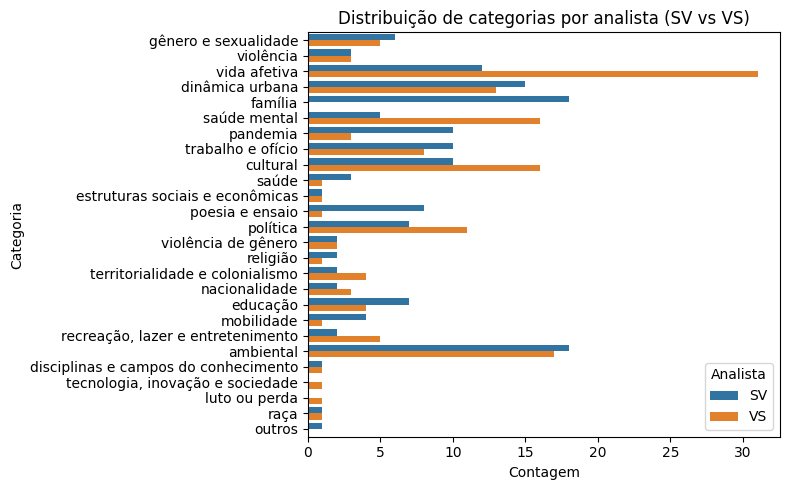

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt dataframe to long format for easier plotting
df_long = pd.melt(
    df_merge_analysts,
    value_vars=['category_SV', 'category_VS'],
    var_name='Rater',
    value_name='Category'
)

# Optional: make the order consistent
rater_labels = {'category_SV': 'SV', 'category_VS': 'VS'}
df_long['Rater'] = df_long['Rater'].map(rater_labels)

# Plot side-by-side counts
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_long,
    y='Category',
    hue='Rater',
    order=cats,      # ensures consistent category order
)

plt.title("Distribuição de categorias por analista (SV vs VS)")
plt.xlabel("Contagem")
plt.ylabel("Categoria")
plt.legend(title='Analista')
plt.tight_layout()

plt.savefig(f'{results_dir}/categories_analysts.png', dpi = 300)
plt.show()


* Nota: Há categorias com elevada disparidade entre analistas, por exemplo cultural, família, saúde mental e vida afetiva

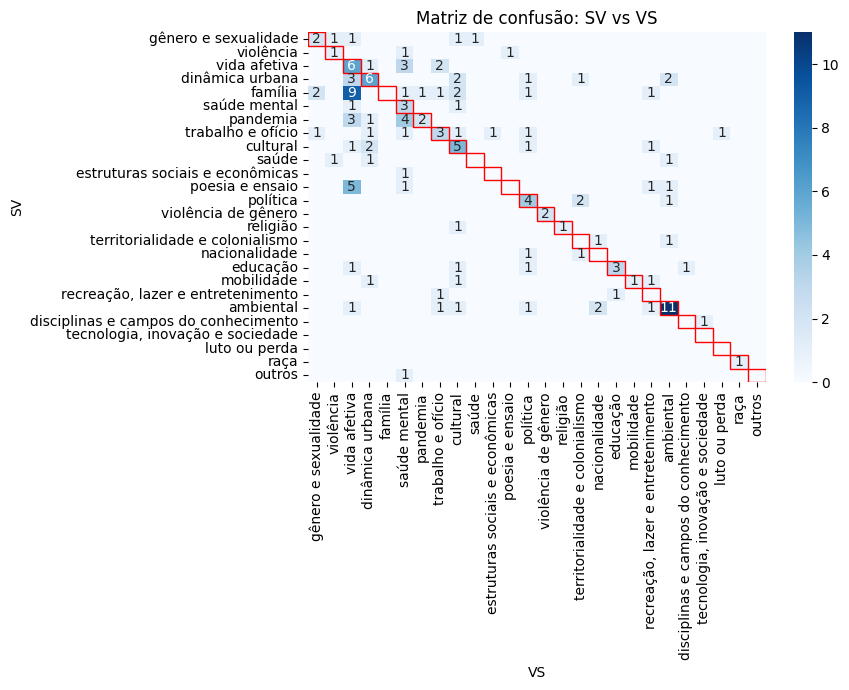

In [ ]:
df = df_merge_analysts.copy()

df['category_SV'] = pd.Categorical(df['category_SV'], categories=cats)
df['category_VS'] = pd.Categorical(df['category_VS'], categories=cats)

ct = pd.crosstab(df['category_SV'], df['category_VS'], dropna=False)

# Create a mask of zeros
mask_zeros = ct == 0

# Convert zeros to empty strings for annotation
annot_data = ct.astype(str)
annot_data[mask_zeros] = ""

fig, ax = plt.subplots(1,1, figsize=(9,7))
sns.heatmap(ct, annot=annot_data, cmap="Blues", fmt="", ax = ax)

# --- Draw boxes around diagonal elements ---
for i in range(len(ct)):
    # x, y coordinates are (col, row)
    rect = plt.Rectangle(
        (i, i),              # (x, y)
        1, 1,                # width, height (one cell)
        fill=False,          # no fill
        edgecolor='red',     # box color
        linewidth=1
    )
    ax.add_patch(rect)
ax.set_title("Matriz de confusão: SV vs VS")
ax.set_ylabel('SV')
ax.set_xlabel('VS')
# Force matplotlib to show all tick labels
ax.set_yticks(np.arange(len(ct.index)) + 0.5)   # +0.5 centers labels in cells
ax.set_yticklabels(ct.index, rotation=0)        # or rotation=0 for horizontal

ax.set_xticks(np.arange(len(ct.columns)) + 0.5)
ax.set_xticklabels(ct.columns, )
plt.tight_layout()
plt.savefig(f'{results_dir}/confusion_matrix_analysts.png', dpi= 300)
plt.show()

* Nota: Há maior concordância para as categorias ambiente, cultural, dinâmica urbana, gênero e sexualidade, saúde mental e vida afetiva.
* Nota: Há maior discordância entre: família (SV) e vida afetiva (VS); poesia e ensaio (SV) e vida afetiva (VS)  

In [ ]:
df['agree'] = df['category_VS'] == df['category_SV']

print(f"Taxa de concordância: {round(df['agree'].mean()*100,2)} %")

Taxa de concordância: 34.0 %


## Dados Autores e Pares

In [ ]:
df_authors_peers = pd.read_excel(f'{root_dir}/Dados Autores e Pares/Dados Empilhados Categorizados Limpos Autores e Pares Padronizados V03.xlsx')

1. Extração do ID dos filmes

In [ ]:
df_authors_peers[['IDFIlmes1','IDFIlme','ID_Clear']].isna().sum()

IDFIlmes1      0
IDFIlme      396
ID_Clear     396
dtype: int64

In [ ]:
df_authors_peers['film_id'] = df_authors_peers['IDFIlmes1']

In [ ]:
df_authors_peers = df_authors_peers[df_authors_peers['film_id'] > 1069000]

2. Extração da primeira categoria

In [ ]:
df_authors_peers['category'] = df_authors_peers['Tema 1'].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

3. Pivot de autores e pares

In [ ]:
column_status = '2014b_Status_Participante_Filme'

df_authors = df_authors_peers[df_authors_peers[column_status] == 'Participou'].copy()
df_peers = df_authors_peers[df_authors_peers[column_status] == 'Não Participou'].copy()

df_authors = df_authors[['film_id', 'category']]
df_peers = df_peers[['film_id', 'category']]

df_authors['rater_index'] = df_authors.groupby('film_id').cumcount() + 1
df_peers['rater_index'] = df_peers.groupby('film_id').cumcount() + 1

In [ ]:
df_authors_wide = (df_authors.pivot(index='film_id', columns='rater_index', values='category').sort_index(axis=1))
df_authors_wide.columns = [f'category_{idx}' for idx in df_authors_wide.columns]

df_peers_wide = (df_peers.pivot(index='film_id', columns='rater_index', values='category').sort_index(axis=1))
df_peers_wide.columns = [f'category_{idx}' for idx in df_peers_wide.columns]

### IRR

1. Autores

In [ ]:
df_num = utils.cat_to_numeric(df_authors_wide)

alpha = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')

print("Krippendorff’s alpha:", alpha)

krippendorff_alpha['authors'] = alpha

Krippendorff’s alpha: 0.2862814782343226


2. Pares

In [ ]:
df_num = utils.cat_to_numeric(df_peers_wide)

alpha = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')

print("Krippendorff’s alpha:", alpha)

krippendorff_alpha['peers'] = alpha

Krippendorff’s alpha: 0.249802561065808


## Dados IA

### ChatGPT

In [ ]:
df_ai_chatgpt = pd.read_excel(f'{root_dir}/Dados IA/AN-IA - SV_ChatGPT_ Formulário de simulação de análise e categorização de filmes por IA (respostas).xlsx')

1. Limpeza dos dados

In [ ]:
column = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_ai_chatgpt.drop_duplicates(subset=column, keep='first', inplace=True)
df_ai_chatgpt.dropna(subset=column, inplace=True)

2. Extração de ID do filme

In [ ]:
df_ai_chatgpt['film_id'] = df_ai_chatgpt[column].str.extract(r"\)\s*(.*?)\s*-").astype(int)

In [ ]:
df_ai_chatgpt = df_ai_chatgpt[df_ai_chatgpt['film_id'] > 1069000]

In [ ]:
df_titles = df_ai_chatgpt[[column, 'film_id']].copy()
df_titles['title'] =df_titles[column].str.extract(r"-\s*(.+?)\s*-")

* Nota: Os seguintes filmes têm o mesmo ID

In [ ]:
df_ai_chatgpt[df_ai_chatgpt['film_id'].duplicated(keep=False)][[column, 'film_id']]

,D.01 - Qual o filme referente a esta análise simulada de IA?,film_id


3. Extração da primeira categoria

In [ ]:
pattern = r'''(?isx)
^
(?:\s*(?:Categoria\s*[A-Z]\s*[-–—]\s*|[A-Z][\.\)]\s*|[A-Z]\s*[–—]\s*))?   # optional prefix
\s*
(.+?)                                                                      # capture main category
(?=                                                                        # stop before optional suffix or end
    \s*
    (?:[-–—]?\s*(?:sub(?:categoria)?\b.*|\(principal\))\s*)?
    $
)
'''

column = 'E.2a) 1 - Categorias/Temas centrais - principal (primeira)'

df_ai_chatgpt['category'] = (df_ai_chatgpt[column].str 
    .extract(pattern, expand=False)
    .str.strip()
    .replace("", pd.NA)
)

df_ai_chatgpt['category']

18           Diversidade, Gênero e Sociedade
19                    Drama Urbano em Lisboa
20                      Poética do Cotidiano
21                Memória & Laços Familiares
22     Género, Trabalho Doméstico e Pandemia
                       ...                  
164     Ficção & Fantasia Contemporânea (BR)
165           Media Literacy & Desinformação
166      Memória, Resistência e Universidade
167           Processos de Dança & Making-of
168                Eco-ficções & Antropoceno
Name: category, Length: 149, dtype: object

* remover "(principal)" em casos onde persiste

In [ ]:
df_ai_chatgpt["category"] = df_ai_chatgpt["category"].str.replace(r"\s*\(principal\)\s*$", "", regex=True).str.strip()



### Gemini

In [ ]:
df_ai_gemini = pd.read_excel(f'{root_dir}/Dados IA/AN-IA - VS_Gemini_ Formulário de simulação de análise e categorização de filmes por IA (respostas) (1).xlsx')

1. Limpeza dos dados

In [ ]:
column = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_ai_gemini.drop_duplicates(subset=column, keep='first', inplace=True)
df_ai_gemini.dropna(subset=column, inplace=True)

2. Extração do ID do filme

In [ ]:
df_ai_gemini['film_id'] = df_ai_gemini['D.01 - Qual o filme referente a esta análise simulada de IA?'].str.extract(r"\)\s*(.*?)\s*-").astype(int)

In [ ]:
df_ai_gemini = df_ai_gemini[df_ai_gemini['film_id'] > 1069000]

* Nota: De forma idêntica ao ChatGPT, os seguintes filmes têm o mesmo ID

In [ ]:
df_ai_gemini[df_ai_gemini['film_id'].duplicated(keep=False)][[column, 'film_id']]

,D.01 - Qual o filme referente a esta análise simulada de IA?,film_id


3. Extração da primeira categoria

In [ ]:
prefix_re = r'^(?:.*?(Tema\s+Principal:?|1\.|Principal(?:\s*\(Strong\s*Match\))?|\*\*|\|\s*\*\*|Recomendação)\s*|\|\s*)'
suffix_re = r'(?:\t|:|\*\*\s*\|?|\*\*\s*\|\s*|\(Prioritário).*'

column = 'E.2a) 1 - Categorias/Temas centrais - principal (primeira)'

df_ai_gemini['category'] = (df_ai_gemini[column].str 
    .replace(prefix_re, "", regex=True)
    .str.replace(suffix_re, "", regex=True)
    .str.strip()
    .replace("", pd.NA)
)

df_ai_gemini['category']

3                      Arte e Poesia Visual.
4                          Emoções e Memória
5                          Gênero e Pandemia
6            Desigualdade Social e Pandemia.
8      Trabalho, Imigração e Cultura Urbana.
                       ...                  
167                                 Educação
168                                   Música
169                      Notícias e Política
170                        Filmes e Animação
173                      Notícias e Política
Name: category, Length: 149, dtype: object

In [ ]:
# Substituir células vazias (nan) por células sem texto
df_ai_gemini['category'] = df_ai_gemini['category'].astype(str).replace("nan", "")

* Nota: Alguns tópicos contêm descriçoes longas, possivelmente múltiplas atribuições de categorias ou atribuição de sub categorias. Não é possível extrair simplesmente pela separação por vírgulas, porque em alguns casos de categorias, estas contêm também vírgulas.

In [ ]:
df_ai_gemini[df_ai_gemini['category'].str.contains(',')][[column, 'category']]

,E.2a) 1 - Categorias/Temas centrais - principal (primeira),category
8,"Trabalho, Imigração e Cultura Urbana.","Trabalho, Imigração e Cultura Urbana."
12,"Abandono, Solidão e Existencialismo.","Abandono, Solidão e Existencialismo."
14,"Dança Urbana, Isolamento e Paisagem Urbana.","Dança Urbana, Isolamento e Paisagem Urbana."
15,"Arte, Natureza e Etnografia","Arte, Natureza e Etnografia"
17,"Verdade, Mentira e Percepção da Realidade.","Verdade, Mentira e Percepção da Realidade."
20,"Urbanismo, Segregação e Desigualdade Social.","Urbanismo, Segregação e Desigualdade Social."
21,"Candomblé, Espiritualidade e Resistência Negra.","Candomblé, Espiritualidade e Resistência Negra."
24,"Memória, História de Vida e Resistência Política.","Memória, História de Vida e Resistência Política."
25,"Arte, Vulnerabilidade e Confinamento.","Arte, Vulnerabilidade e Confinamento."
26,"Solidão, Isolamento Social e Consequências da ...","Solidão, Isolamento Social e Consequências da ..."


### IRR

In [ ]:
column_title = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_merge_ai = pd.merge(df_ai_chatgpt[['film_id', 'category']], df_ai_gemini[['film_id', 'category']], on='film_id', suffixes = ('_ChatGPT', '_Gemini'))
df_merge_ai.set_index('film_id', inplace = True)

In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(df_merge_ai["category_ChatGPT"], df_merge_ai["category_Gemini"])
print("Cohen's kappa:", kappa)

Cohen's kappa: 0.0


c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\ut

In [ ]:
cats = pd.unique(df_merge_ai.values.ravel())
cats = [c for c in cats if pd.notna(c)]

In [ ]:
import krippendorff

df_num = utils.cat_to_numeric(df_merge_ai)

alpha = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')
print("Krippendorff alpha:", alpha)

krippendorff_alpha['IA'] = alpha

Krippendorff alpha: -0.002479794268920088


### Mapeamento AI

In [ ]:
cats_ai = set(df_merge_ai['category_ChatGPT']) | set(df_merge_ai['category_Gemini'])
cats_all = set(pd.unique(df_merge_analysts.values.ravel())) | set(pd.unique(df_authors_wide.values.ravel())) | set(pd.unique(df_peers_wide.values.ravel()))
cats_all.discard(np.nan)

In [ ]:
from sentence_transformers import SentenceTransformer, util

cats_list = list(cats_all)
other_list = list(cats_ai)

# give labels some context to help the embedding model
def add_context(label: str) -> str:
    return f"Tópico de filme: {label}"

cats_with_ctx = [add_context(x) for x in cats_list]
other_with_ctx = [add_context(x) for x in other_list]

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

# Encode labels (normalized for cosine via dot product)
emb_cats = model.encode(cats_with_ctx, normalize_embeddings=True)
emb_other = model.encode(other_with_ctx, normalize_embeddings=True)

# Cosine similarity matrix: shape (len(other) x len(all))
sim_matrix = emb_other @ emb_cats.T   # because embeddings are normalized

# For each "other" label, find best match
best_cat_idx = sim_matrix.argmax(axis=1)
best_sim = sim_matrix.max(axis=1)

# Build mapping dict (optionally apply a similarity threshold)
threshold = 0.50  # tune this
mapping = {}
for i, other_label in enumerate(other_list):
    sim = best_sim[i]
    gold_label = cats_list[best_cat_idx[i]]
    if sim >= threshold:
        mapping[other_label] = (gold_label, float(sim))
    else:
        mapping[other_label] = (None, float(sim))  # no good match

df_map = pd.DataFrame(
    {
        "ai": other_list,
        "cats_all": [mapping[o][0] for o in other_list],
        "similarity": [mapping[o][1] for o in other_list],
    }
).sort_values("similarity", ascending=False)

final_mapping = {k: v for k, (v, s) in mapping.items() if v is not None}



In [ ]:
df_map

,ai,cats_all,similarity
86,Educação,educação,0.994254
213,Poético/ensaístico,poesia e ensaio,0.973258
5,Poética do Cotidiano,poesia e ensaio,0.959673
62,Natureza Poética & Aves,poesia e ensaio,0.957393
52,"Arte, Poesia e Literatura",poesia e ensaio,0.948350
...,...,...,...
188,"Cultura, Educação e Resiliência Social no Brasil.",educação,0.589254
175,Cultura alimentar brasileira,cultural,0.576020
25,"Artes Performáticas e Dança Flamenco, Sapatead...",cultural,0.573301
2,"Memória Familiar e Afetiva, Luto e Legado, Ens...",cultural,0.572509


In [ ]:
print('Categorias com maior similaridade')
df_map.head(10)

Categorias com maior similaridade


,ai,cats_all,similarity
86,Educação,educação,0.994254
213,Poético/ensaístico,poesia e ensaio,0.973258
5,Poética do Cotidiano,poesia e ensaio,0.959673
62,Natureza Poética & Aves,poesia e ensaio,0.957393
52,"Arte, Poesia e Literatura",poesia e ensaio,0.948350
266,Direitos Humanos e Ativismo,direitos humanos,0.947512
138,Memória & Objetos biográficos,memória e patrimônio,0.947344
99,Religião e Espiritualidade,religião,0.945949
16,Educação e Acesso,educação,0.943663
55,Poética do Cotidiano em Isolamento,poesia e ensaio,0.941604


In [ ]:
print('Categorias com menor similaridade')
df_map.tail(10)

Categorias com menor similaridade


,ai,cats_all,similarity
53,Gastronomia e Culinária Regional,questão agrária e territorial,0.628977
215,Ensaio Urbano & City Symphony (BR),dinâmica urbana,0.627133
46,"Ética da IA, Luto Patológico, Realidade Virtua...","tecnologia, inovação e sociedade",0.623901
121,Memória e Diáspora Palestina,memória e patrimônio,0.619494
214,Música Regional Brasileira,sonoridade e paisagem sonora,0.605076
188,"Cultura, Educação e Resiliência Social no Brasil.",educação,0.589254
175,Cultura alimentar brasileira,cultural,0.576020
25,"Artes Performáticas e Dança Flamenco, Sapatead...",cultural,0.573301
2,"Memória Familiar e Afetiva, Luto e Legado, Ens...",cultural,0.572509
208,Feiras & Street Food Brasil,None,0.488274


In [ ]:
df_category_maps =  df_map.groupby('cats_all')['ai'].agg(list).to_frame()
df_category_maps


,ai
cats_all,
alimentação e tratamentos tradicionais,[Culinária e Cultura Alimentar]
ambiental,"[Sustentabilidade e Meio Ambiente, Meio Ambien..."
"corpo, performance e expressão","[Corpo & Sensorialidades (Ensaio Poético), Pro..."
cultural,"[Cultura e Tradição, Arte e Cultura, Artes e C..."
desastres naturais e clima extremo,"[Desastres & Justiça Climática (BR), Meio Ambi..."
"desinformação, populismo e polarização","[Desinformação & Retórica, Crítica ao Negacion..."
dinâmica urbana,"[Questões Sociais e Urbanismo, Cidade & mobili..."
direitos humanos,"[Direitos Humanos e Ativismo, Ativismo e Direi..."
disciplinas e campos do conhecimento,"[Cinema de Arte e Teoria do Cinema, Filosofia ..."


In [ ]:
df_merge_ai['category_ChatGPT_mapped'] = df_merge_ai['category_ChatGPT'].map(final_mapping)
df_merge_ai['category_Gemini_mapped'] = df_merge_ai['category_Gemini'].map(final_mapping)

In [ ]:
df_num = utils.cat_to_numeric(df_merge_ai[["category_ChatGPT_mapped", "category_Gemini_mapped"]])

alpha = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')
print("Krippendorff alpha:", alpha)

krippendorff_alpha['IA_mapped'] = alpha

Krippendorff alpha: 0.20121936107462413


### Riqueza lexical e semantica

In [ ]:
import transcript_analysis

col_title = 'D.01 - Qual o filme referente a esta análise simulada de IA?'
col_transcript = 'E.0b) Insira aqui a Transcrição do filme a ser processado'

file_path =f'{results_dir}/df_transcripts_richness.csv'

def get_text_richness(row):

    transcript = row[f'{col_transcript}_ChatGPT']

    if isinstance(transcript, float):
        return np.nan, np.nan

    clean_transcript = transcript_analysis.clean_transcript(transcript)

    try:
        lexical = transcript_analysis.lexical_richness(clean_transcript)
    except:
        lexical = np.nan
    try:
        semantic = transcript_analysis.semantic_richness(clean_transcript)
    except ValueError:
        semantic = np.nan

    return lexical, semantic

if not os.path.exists(file_path):
    df_transcripts = pd.merge(df_ai_chatgpt[[col_title, col_transcript]], df_ai_gemini[[col_title, col_transcript]], on = col_title, how='outer', suffixes=('_ChatGPT', '_Gemini'))

    df_transcripts[['lexical_richness', 'semantic_richness']] = df_transcripts.apply(get_text_richness, axis = 1, result_type='expand')

    df_transcripts.to_csv(file_path)
else:
    df_transcripts = pd.read_csv(file_path, index_col = 0)

In [ ]:
df_transcripts['film_id'] = df_transcripts[col_title].str.extract(r"\)\s*(.*?)\s*-").astype(int)
df_transcripts.set_index('film_id', inplace=True)


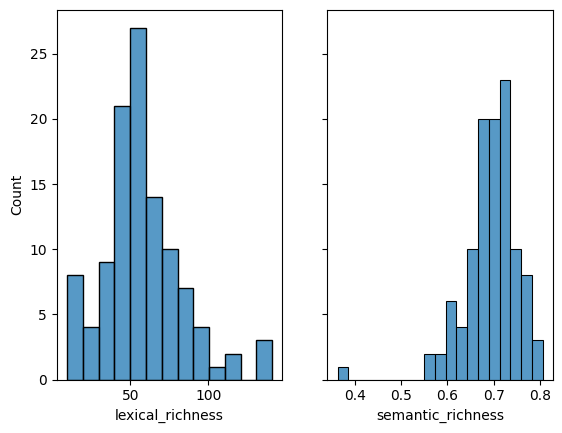

In [ ]:
fig, axes = plt.subplots(1,2, sharey=True)
richness = ['lexical_richness', 'semantic_richness']

for ax, r in zip(axes, richness):
    sns.histplot(df_transcripts, x=r, ax=ax)

plt.show()

## Intra RR para diferentes dimensões

Text(0.5, 1.0, 'Inter Rater Reliability')

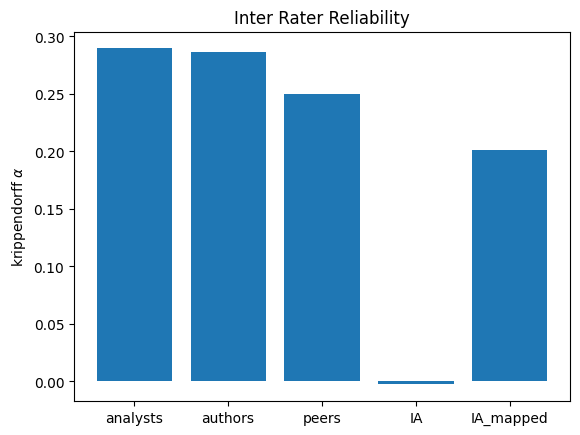

In [ ]:
import matplotlib.pyplot as plt

plt.bar(krippendorff_alpha.keys(), krippendorff_alpha.values())
plt.ylabel(r'krippendorff $\alpha$')
plt.title('Inter Rater Reliability')

## IRR

In [ ]:
dfs = [df_merge_analysts, df_merge_ai, df_authors_wide, df_peers_wide]

In [ ]:
cols = {'analyst' : ['category_VS', 'category_SV'],
        'ai': ['category_ChatGPT_mapped', 'category_Gemini_mapped']}


df_merge_all = df_merge_analysts[cols['analyst']].merge(df_merge_ai[cols['ai']], on='film_id', how='outer')
df_merge_all = df_merge_all.merge(df_peers_wide, on='film_id', how = 'outer')
df_merge_all = df_merge_all.merge(df_authors_wide, on='film_id', suffixes=('_peers', '_authors'), how = 'outer')

df_merge_all

,category_VS,category_SV,category_ChatGPT_mapped,category_Gemini_mapped,category_1_peers,category_2_peers,category_3_peers,category_4_peers,category_5_peers,category_6_peers,...,category_35,category_36,category_1_authors,category_2_authors,category_3_authors,category_4_authors,category_5_authors,category_6_authors,category_7_authors,category_8_authors
film_id,,,,,,,,,,,,,,,,,,,,,
1070101,violência,gênero e sexualidade,gênero e sexualidade,educação,homofobia e preconceito de gênero,homofobia e preconceito de gênero,poesia e ensaio,homofobia e preconceito de gênero,homofobia e preconceito de gênero,linguagem e representação,...,NaN,NaN,homofobia e preconceito de gênero,gênero e sexualidade,educação,poesia e ensaio,NaN,NaN,NaN,NaN
1070102,dinâmica urbana,vida afetiva,dinâmica urbana,outros,vida afetiva,dinâmica urbana,vida afetiva,dinâmica urbana,dinâmica urbana,dinâmica urbana,...,NaN,NaN,vida afetiva,vida afetiva,vida afetiva,dinâmica urbana,dinâmica urbana,dinâmica urbana,NaN,NaN
1070103,vida afetiva,vida afetiva,poesia e ensaio,poesia e ensaio,mobilidade,pandemia,vida afetiva,ambiental,poesia e ensaio,NaN,...,NaN,NaN,poesia e ensaio,poesia e ensaio,poesia e ensaio,poesia e ensaio,sonoridade e paisagem sonora,NaN,NaN,NaN
1070105,saúde mental,família,memória e patrimônio,memória e patrimônio,pandemia,pandemia,vida afetiva,saúde mental,dinâmica urbana,vida afetiva,...,NaN,NaN,poesia e ensaio,vida afetiva,vida afetiva,"distopia, ficção científica e futuros imaginados",saúde mental,vida afetiva,NaN,NaN
1070106,gênero e sexualidade,família,trabalho e ofício,gênero e sexualidade,outros,pandemia,gênero e sexualidade,família,família,gênero e sexualidade,...,NaN,NaN,pandemia,educação,pandemia,pandemia,pandemia,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1110322,cultural,cultural,cultural,educação,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1110323,cultural,cultural,cultural,sonoridade e paisagem sonora,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1110324,"recreação, lazer e entretenimento",família,dinâmica urbana,política,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_num = utils.cat_to_numeric(df_merge_all)

alpha = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')
print(alpha)
krippendorff_alpha['all'] = alpha

0.2363011627952153


Text(0, 0.5, 'krippendorff $\\alpha$')

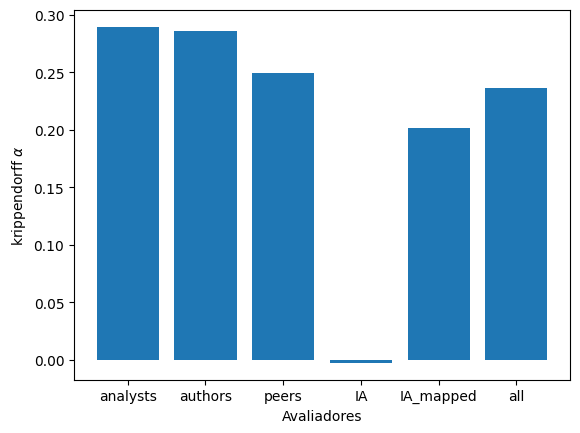

In [ ]:
plt.bar(krippendorff_alpha.keys(), krippendorff_alpha.values())
plt.xlabel('Avaliadores')
plt.ylabel(r'krippendorff $\alpha$')

## Análise nível micro

### Analistas

In [ ]:
columns = ['B.02 - Em uma frase (poucas palavras, suas) sobre o que é o filme analisado? [procure não se ater somente ao título ou sinopse]',
           'B.03 - Qual o tema ou temas que este filme mobilizam?\n[resposta espontânea e aberta de quem analisa]']

df_sv = df_analysts_sv[['film_id'] + columns].copy()
df_vs = df_analysts_vs[['film_id'] + columns].copy()

df_sv['micro'] = df_sv[columns[0]] + '\n' + df_sv[columns[1]]
df_vs['micro'] = df_vs[columns[0]] + '\n' + df_vs[columns[1]]

df_sv['film_id'] = df_sv['film_id']
df_vs['film_id'] = df_vs['film_id']

df_micro_analysts = pd.merge(df_sv[['film_id', 'micro']], df_vs[['film_id', 'micro']], on='film_id', suffixes=('_SV','_VS'))
df_micro_analysts.set_index('film_id', inplace = True)


In [ ]:
label_a, label_b = ('micro_SV','micro_VS')
df_micro_analysts['similarity'] = df_micro_analysts.apply(lambda row : utils.semantic_similarity(row, label_a, label_b), axis = 1)

In [ ]:
df_micro_analysts['similarity_lemma'] = df_micro_analysts.apply(lambda row : utils.semantic_similarity(row, label_a, label_b, lemma=True), axis = 1)

### IA

In [ ]:
column = 'E.2) Insira aqui a resposta da IA com os dados da análise simulada [por favor, revise antes de enviar]:'

df_chatgpt = df_ai_chatgpt.copy()
df_gemini = df_ai_gemini.copy()

df_chatgpt['micro'] = df_chatgpt[column].str.replace(r"[^A-Za-zÀ-ÖØ-öø-ÿ]+", " ", regex=True).str.strip()
df_gemini['micro'] = df_gemini[column].str.replace(r"[^A-Za-zÀ-ÖØ-öø-ÿ]+", " ", regex=True).str.strip()

df_micro_ai = pd.merge(df_chatgpt[['film_id', 'micro']], df_gemini[['film_id', 'micro']], on = 'film_id', suffixes=('_ChatGPT', '_Gemini'))
df_micro_ai.set_index('film_id', inplace=True)

In [ ]:
label_a, label_b = ('micro_ChatGPT', 'micro_Gemini')

df_micro_ai['similarity'] = df_micro_ai.apply(lambda row : utils.semantic_similarity(row, label_a, label_b), axis = 1)

In [ ]:
df_micro_ai['similarity_lemma'] = df_micro_ai.apply(lambda row : utils.semantic_similarity(row, label_a, label_b, lemma=True), axis = 1)

### Autores e pares

In [ ]:
df_authors_peers_micro = pd.read_excel(f'{root_dir}/Dados Autores e Pares/Empilhado_SVVS Partes 1 e 2 Empilhado - regular.xlsx')

* Nota: Para a analise micro, basta usar os dados de um dos analistas

In [ ]:
df_authors_peers_micro = df_authors_peers_micro[df_authors_peers_micro['Analista'] == 'VS']

df_authors_micro = df_authors_peers_micro[df_authors_peers_micro['Tipo de Participação autores ou pares'] == 'Participou'].copy()
df_peers_micro = df_authors_peers_micro[df_authors_peers_micro['Tipo de Participação autores ou pares'] == 'Não Participou'].copy()

df_authors_micro['film_id'] = df_authors_micro['ID Filme'].astype(int)
df_peers_micro['film_id'] = df_peers_micro['ID Filme'].astype(int)

In [ ]:
df_authors_micro = df_authors_micro[df_authors_micro['film_id'] > 1069000]
df_peers_micro = df_peers_micro[df_peers_micro['film_id'] > 1069000]

In [ ]:
columns = ['2013a_Em uma ou duas palavras é um filme sobre...:','2009_Como você resumiria este filme? (em poucas palavras)']

df_authors_micro['micro'] = df_authors_micro[columns[0]] + '\n' + df_authors_micro[columns[1]]
df_peers_micro['micro'] = df_peers_micro[columns[0]] + '\n' + df_peers_micro[columns[1]]

In [ ]:
df_authors_micro['rater_index'] = df_authors_micro.groupby('film_id').cumcount().add(1).astype(str).radd('author_')
df_peers_micro['rater_index'] = df_peers_micro.groupby('film_id').cumcount().add(1).astype(str).radd('peer_')

df_authors_micro_wide = df_authors_micro.pivot(index='film_id', columns='rater_index', values='micro')
df_peers_micro_wide = df_peers_micro.pivot(index='film_id', columns='rater_index', values='micro')

In [ ]:
labels = df_authors_micro_wide.columns

df_micro_authors = pd.DataFrame()
df_micro_authors['similarity'] = df_authors_micro_wide.apply(lambda row : utils.semantic_similarity_intra(row, labels), axis = 1)

In [ ]:
df_micro_authors['similarity_lemma'] = df_authors_micro_wide.apply(lambda row : utils.semantic_similarity_intra(row, labels, lemma=True), axis = 1)

In [ ]:
labels = df_peers_micro_wide.columns

df_micro_peers = pd.DataFrame()
df_micro_peers['similarity'] = df_peers_micro_wide.apply(lambda row : utils.semantic_similarity_intra(row, labels), axis = 1)

In [ ]:
df_micro_peers['similarity_lemma'] = df_peers_micro_wide.apply(lambda row : utils.semantic_similarity_intra(row, labels, lemma=True), axis = 1)

### Comparações intra dimensões

In [ ]:
colors_single = ['#D32F2F', '#FBC02D', '#26C6DA', '#135CAD']

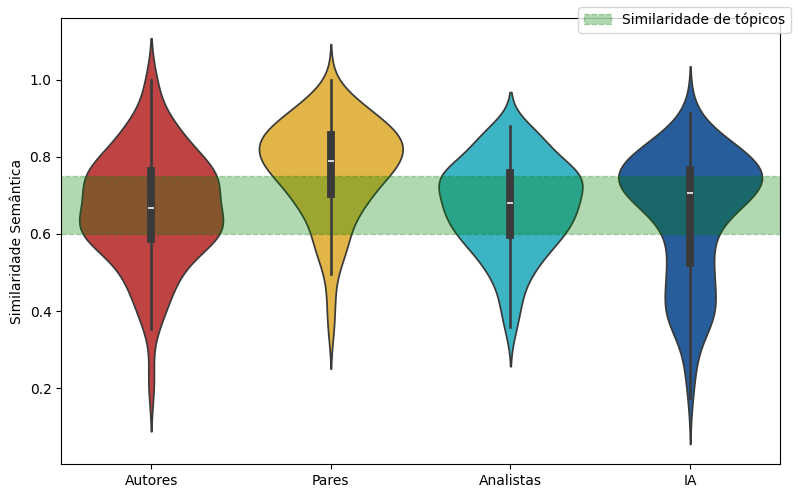

In [ ]:
topic_low = 0.60
topic_high = 0.75

dfs_micro = {'Autores' : df_micro_authors, 'Pares' : df_micro_peers, 'Analistas' : df_micro_analysts, 'IA' : df_micro_ai, }

df_micro_all = pd.concat([df['similarity'] for df in dfs_micro.values()], axis = 1)
df_micro_all.columns=dfs_micro.keys()
fig, ax = plt.subplots(1,1, figsize=(8,5))
sns.violinplot(df_micro_all, ax = ax, palette=colors_single)
ax.set_ylabel('Similaridade Semântica')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Similaridade de tópicos', alpha = 0.3)

fig.legend()
fig.tight_layout()
fig.savefig(f'{results_dir}/micro_single_max.png', dpi = 300)
plt.show()

df_micro_all.to_excel(f'{results_dir}/micro_single_max.xlsx')

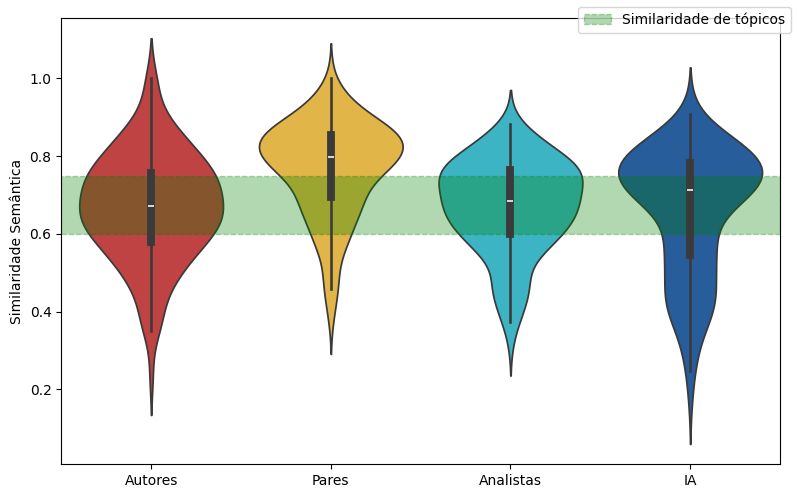

In [ ]:
df_micro_all = pd.concat([df['similarity_lemma'] for df in dfs_micro.values()], axis = 1)
df_micro_all.columns=dfs_micro.keys()
fig, ax = plt.subplots(1,1, figsize=(8,5))
sns.violinplot(df_micro_all, ax = ax, palette=colors_single)
ax.set_ylabel('Similaridade Semântica')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Similaridade de tópicos', alpha = 0.3)

fig.legend()
fig.tight_layout()
fig.savefig(f'{results_dir}/micro_single_lemma_max.png', dpi = 300)
plt.show()

df_micro_all.to_excel(f'{results_dir}/micro_single_lemma_max.xlsx')

### Comparações entre dimensões

In [ ]:
labels = {'Analistas' : ['micro_VS', 'micro_SV'],
          'IA' : ['micro_ChatGPT', 'micro_Gemini'],
          'Autores' : df_authors_micro_wide.columns,
          'Pares' : df_peers_micro_wide.columns}

dfs = {'Analistas' : df_micro_analysts,
       'IA' : df_micro_ai,
       'Autores' : df_authors_micro_wide,
       'Pares' : df_peers_micro_wide}

In [ ]:
from itertools import combinations 
import warnings
importlib.reload(utils)


file_path = f'{results_dir}/df_micro_comparisons.csv'

if not os.path.exists(file_path):

    dimension_comparisons = list(combinations(labels.keys(), 2))

    list_dfs = []

    for combination in dimension_comparisons:

        dimension_a, dimension_b = combination

        labels_a = labels[dimension_a]
        labels_b = labels[dimension_b]

        df_merge = pd.merge(dfs[dimension_a], dfs[dimension_b], on = 'film_id', how ='outer')
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            df_merge[f'{dimension_a} e {dimension_b}'] = df_merge.apply(lambda row: utils.semantic_similarity_inter(row, labels_a, labels_b), axis = 1)
        
        list_dfs.append(df_merge[f'{dimension_a} e {dimension_b}'])

    df_micro_comparisons = pd.concat(list_dfs, axis = 1, join='outer')
    df_micro_comparisons.to_csv(file_path)

else:
    df_micro_comparisons = pd.read_csv(file_path, index_col=0)

In [ ]:
colors_combinations = ['#1290D0', '#C15278', '#7EE0A3', '#8E45E5', '#3B855B', '#F57F17']

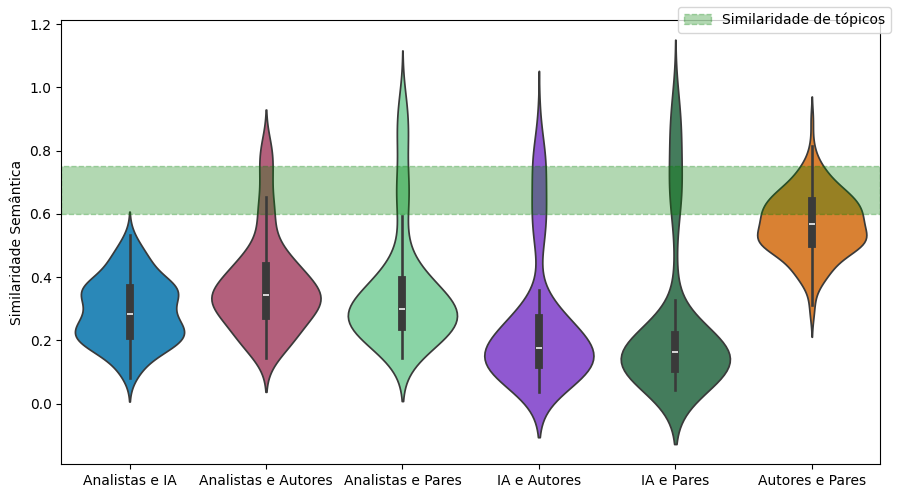

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(9,5))

sns.violinplot(data=df_micro_comparisons, ax = ax, palette=colors_combinations)
ax.set_ylabel('Similaridade Semântica')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Similaridade de tópicos', alpha = 0.3)

fig.legend()
fig.tight_layout()
fig.savefig(f'{results_dir}/micro_multi_all.png', dpi = 300)
plt.show()

df_micro_comparisons.to_excel(f'{results_dir}/micro_multi_all.xlsx')

In [ ]:
file_path = f'{results_dir}/df_micro_comparisons_lemma.csv'

if not os.path.exists(file_path):

    dimension_comparisons = list(combinations(labels.keys(), 2))

    list_dfs = []

    for combination in dimension_comparisons:

        dimension_a, dimension_b = combination

        labels_a = labels[dimension_a]
        labels_b = labels[dimension_b]

        df_merge = pd.merge(dfs[dimension_a], dfs[dimension_b], on = 'film_id', how ='outer')
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            df_merge[f'{dimension_a} e {dimension_b}'] = df_merge.apply(lambda row: utils.semantic_similarity_inter(row, labels_a, labels_b, lemma=True), axis = 1)
        
        list_dfs.append(df_merge[f'{dimension_a} e {dimension_b}'])

    df_micro_comparisons_lemma = pd.concat(list_dfs, axis = 1, join='outer')
    df_micro_comparisons_lemma.to_csv(file_path)

else:
    df_micro_comparisons_lemma = pd.read_csv(file_path, index_col=0)

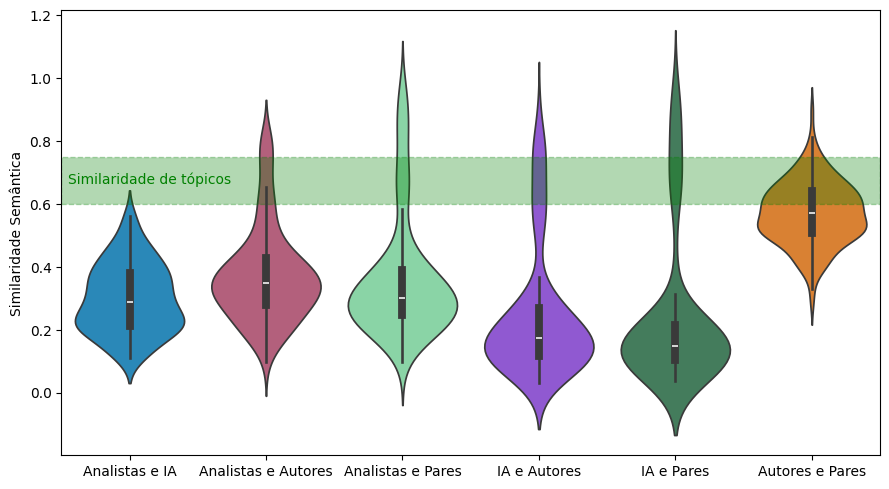

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(9,5))

sns.violinplot(data=df_micro_comparisons_lemma, ax = ax, palette=colors_combinations)
ax.set_ylabel('Similaridade Semântica')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Similaridade de tópicos', alpha = 0.3)
ax.text(0.15,
    0.7,
    "Similaridade de tópicos",
    ha="center",
    va="top",
    color="green",
    fontsize=10,
)

fig.tight_layout()
fig.savefig(f'{results_dir}/micro_multi_all_lemma.png', dpi = 300)
plt.show()

df_micro_comparisons_lemma.to_excel(f'{results_dir}/micro_multi_all_lemma.xlsx')

### Comparação entre riqueza de texto e micro 

In [ ]:
_dfs_micro = {'Analistas' : df_micro_analysts, 'IA' : df_micro_ai, 'Autores' : df_authors_micro_wide, 'Pares' : df_peers_micro_wide}

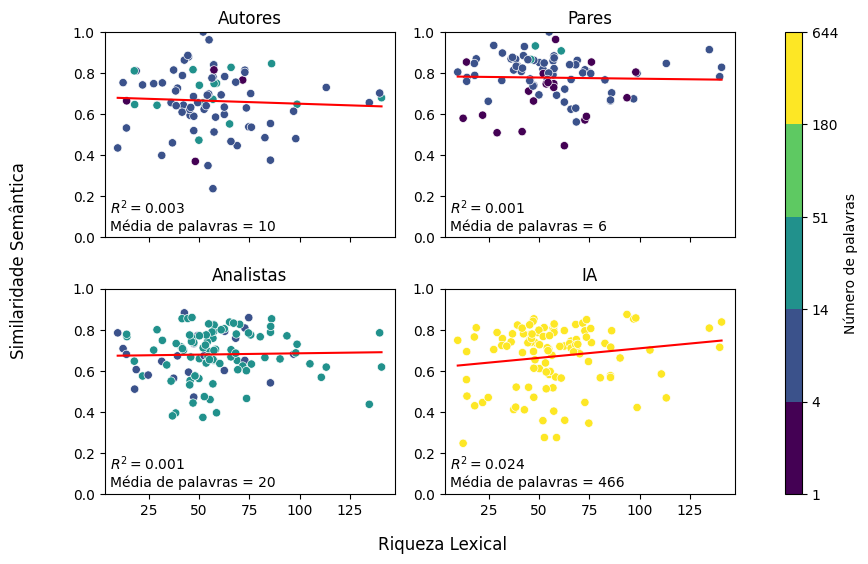

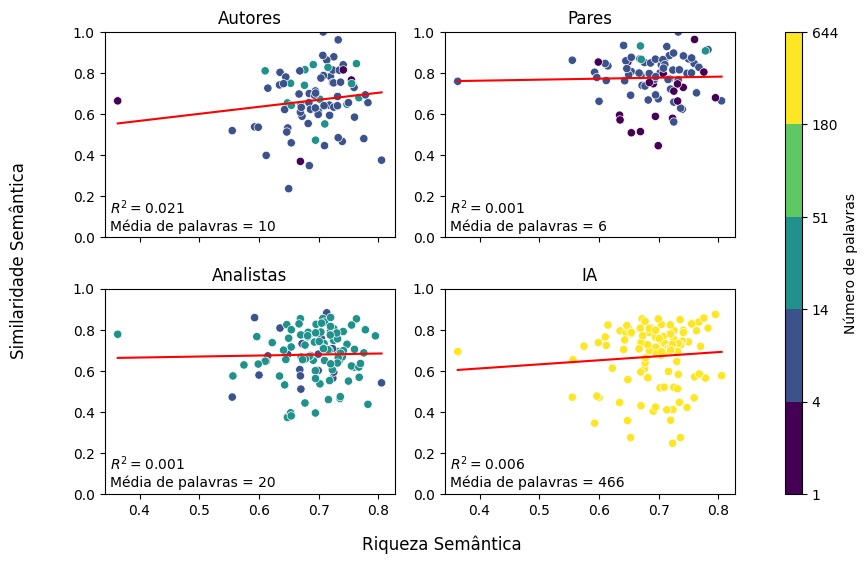

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable

labels = [1,2,3,4,5]

word_counts = []

for dimension, df in _dfs_micro.items():
    df_word_count = df.map(lambda x: len(str(x).split()))
    mean = df_word_count.mean(axis=1)
    mean.name = dimension + '_N'
    word_counts.append(mean)

df_word_counts = pd.concat(word_counts, axis = 1)

bins = np.logspace(np.log10(df_word_counts.min().min()),
                   np.log10(df_word_counts.max().max()),
                   6)

def bin_value(x):
    return pd.cut([x], bins=bins, labels=labels, include_lowest=True)[0]

df_bins = df_word_counts.map(bin_value)

cmap_word = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(labels))))
norm_word = BoundaryNorm(bins, cmap_word.N)
palette = {label: cmap_word(i) for i, label in enumerate(labels)}

for richness in ['lexical_richness', 'semantic_richness']:
    df = pd.concat([df_micro_all, df_transcripts[richness]], axis = 1)
    if richness == 'lexical_richness':
        label = 'Riqueza lexical'
    else:
        label = 'Riqueza semântica'

    fig = plt.figure(figsize=(9, 6))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.06], height_ratios = [1,1], hspace=0.25, wspace=0.25)

    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[0,1], sharex=ax1)
    ax3 = fig.add_subplot(gs[1,0], sharex=ax1)
    ax4 = fig.add_subplot(gs[1,1], sharex=ax1)

    ax1.tick_params(labelbottom=False)
    ax2.tick_params(labelbottom=False)

    axes = [ax1,ax2,ax3,ax4]
    
    df_out_list = []
    for dimension, ax in zip(dfs_micro.keys(), axes):
        _df_color = df_bins[dimension + '_N']
        _df_color.name = dimension + '_color'
        _df_word_count = df_word_counts[dimension + '_N']
        _df = pd.concat([df[richness], df[dimension], _df_color, _df_word_count], axis = 1)
        
        sns.scatterplot(data=_df, 
                        x=richness, 
                        y=dimension, 
                        hue=f'{dimension}_color', 
                        hue_order=labels,
                        palette=palette,
                        ax=ax,
                        legend=False
                        )
        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.set_ylim(0,1)
        ax.set_title(dimension)

        x_range, y_pred, r2 = utils.get_fitted(df, richness, dimension)
        mean_word_count = df_word_counts[f'{dimension}_N'].mean()
        ax.plot(x_range, y_pred, color = 'red')
        ax.text(
                0.02, 0.02,
                f"$R^2 = {r2:.3f}$\nMédia de palavras = {mean_word_count:.0f}",
                transform=ax.transAxes,
                fontsize=10,
                va='bottom',
                ha='left'
            )
        if dimension != 'Autores':
            _df = _df.drop(richness, axis = 1)
        df_out_list.append(_df)

    cax = fig.add_subplot(gs[:, 2])

    sm = ScalarMappable(norm=norm_word, cmap=cmap_word)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_ticks(bins)
    cbar.set_ticklabels([f"{b:.0f}" for b in bins])
    cbar.set_label("Número de palavras")
    
    if richness == 'lexical_richness':
        label = 'Riqueza Lexical'
    else:
        label = 'Riqueza Semântica'

    fig.supxlabel(label)
    fig.supylabel('Similaridade Semântica')
    fig.savefig(f'{results_dir}/micro_{richness}.png', dpi = 300)

    df_out = pd.concat(df_out_list, axis = 1)
    df_out.to_excel(f'{results_dir}/micro_{richness}.xlsx')
    
    plt.show()

### Riqueza textual Nível Micro

In [ ]:
def get_text_richness_micro(row):

    row = row[~row.index.str.contains("similarity", case=False, na=False)]
    
    transcript = " ".join(row.dropna())

    if isinstance(transcript, float):
        return np.nan, np.nan

    clean_transcript = transcript_analysis.clean_transcript(transcript)

    try:
        lexical = transcript_analysis.lexical_richness(clean_transcript)
    except:
        lexical = np.nan
    try:
        semantic = transcript_analysis.semantic_richness(clean_transcript)
    except ValueError:
        semantic = np.nan

    return lexical, semantic


file_path = f'{results_dir}/df_micro_richness.csv'

if not os.path.exists(file_path):
    results = {}
    for dimension, df in _dfs_micro.items():
        df_out = pd.DataFrame(index = df.index)
        df_out[['lexical_richness', 'semantic_richness']] = df.apply(get_text_richness_micro, axis = 1, result_type='expand')

        results[dimension] = df_out
    
    df_micro_richness = pd.concat({k : v for k,v in results.items()}, axis = 1)
    df_micro_richness = df_micro_richness.swaplevel(0,1, axis = 1)
    df_micro_richness = df_micro_richness.sort_index(axis = 1)
    df_micro_richness.to_csv(file_path)
else: 
    df_micro_richness = pd.read_csv(file_path, index_col=0, header=[0,1])

df_micro_richness = df_micro_richness.reindex(columns=['Autores', 'Pares', 'Analistas', 'IA'], level = 1)

In [ ]:
df_micro_richness.to_excel(f'{results_dir}/micro_textual_richness.xlsx')

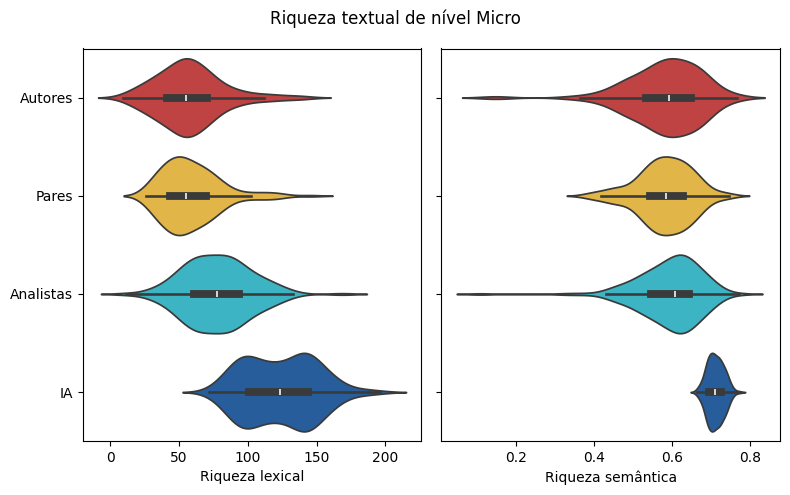

In [ ]:
fig, axes = plt.subplots(1,2, sharey=True, figsize=(8,5))
for richness,ax in zip(['lexical_richness', 'semantic_richness'], axes):
    df = df_micro_richness.xs(richness, level=0, axis = 1)
    sns.violinplot(data=df, ax = ax, orient='h', palette=colors_single)
    
    if richness == 'semantic_richness':
        label = 'Riqueza semântica'
    else:
        label = 'Riqueza lexical'
    ax.set_xlabel(label)
fig.suptitle('Riqueza textual de nível Micro')
fig.tight_layout()
fig.savefig(f'{results_dir}/micro_textual_richness.png', dpi = 300)

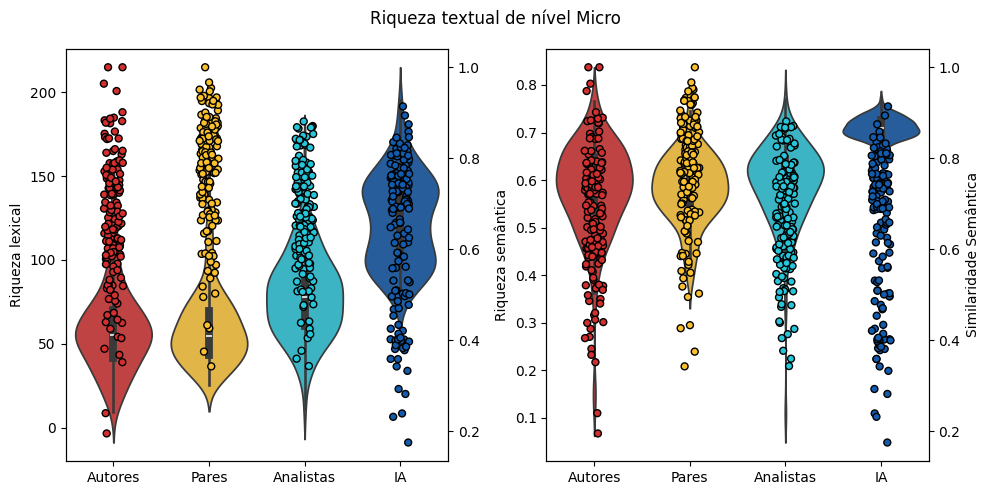

In [ ]:
dfs_micro_ordered = {col: dfs_micro[col] for col in df_micro_richness.columns.get_level_values(level=1).unique()}

fig, axes = plt.subplots(1,2, figsize=(10,5))
for richness,ax in zip(['lexical_richness', 'semantic_richness'], axes):
    df = df_micro_richness.xs(richness, level=0, axis = 1)
    sns.violinplot(data=df, ax = ax, palette=colors_single)
    
    if richness == 'semantic_richness':
        label = 'Riqueza semântica'
    else:
        label = 'Riqueza lexical'
    ax.set_ylabel(label)

for ax in axes:

    df_all = pd.concat({dimension : df['similarity'] for dimension, df in dfs_micro_ordered.items()}, axis = 1)
    secx = ax.twinx()
    if ax == axes[-1]:
        secx.set_ylabel('Similaridade Semântica')
    sns.stripplot(data=df_all, ax = secx, edgecolor='black', linewidth=1, palette=colors_single)

fig.suptitle('Riqueza textual de nível Micro')
fig.tight_layout()
fig.savefig(f'{results_dir}/micro_textual_richness_similarity_violin.png', dpi = 300)

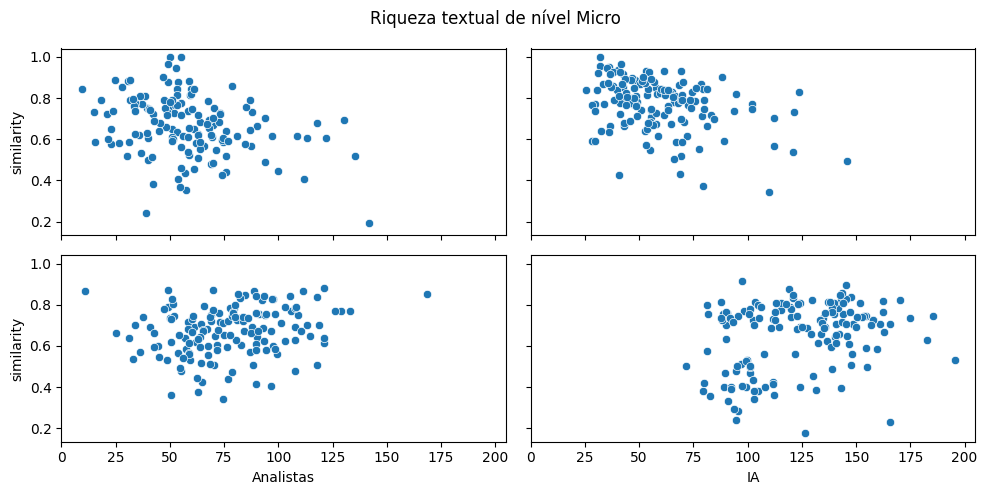

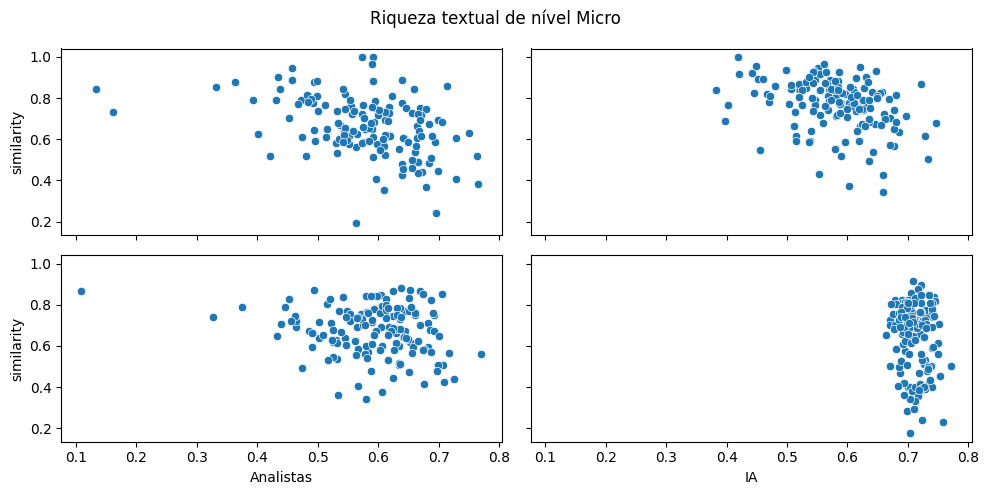

In [ ]:
dfs_micro_ordered = {col: dfs_micro[col] for col in df_micro_richness.columns.get_level_values(level=1).unique()}

for richness in ['lexical_richness', 'semantic_richness']:


    if richness == 'semantic_richness':
        label = 'Riqueza semântica'
    else:
        label = 'Riqueza lexical'
    #ax.set_ylabel(label)


    df_richness = df_micro_richness.xs(richness, level=0, axis = 1)
    
    fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(10,5))

    for dimension, ax in zip(df_richness.columns, axes.flat):
        df = pd.concat([df_richness[dimension], dfs_micro[dimension]['similarity']], axis = 1)
        sns.scatterplot(data=df, x=dimension, y = 'similarity', ax = ax)
        
    # for ax in axes:

    #     df_all = pd.concat({dimension : df['similarity'] for dimension, df in dfs_micro_ordered.items()}, axis = 1)
    #     secx = ax.twinx()
    #     if ax == axes[-1]:
    #         secx.set_ylabel('Similaridade Semântica')
    #     sns.stripplot(data=df_all, ax = secx, edgecolor='black', linewidth=1)

    fig.suptitle('Riqueza textual de nível Micro')
    fig.tight_layout()
#fig.savefig('../results/micro_textual_richness_similarity_violin.png', dpi = 300)
plt.show()

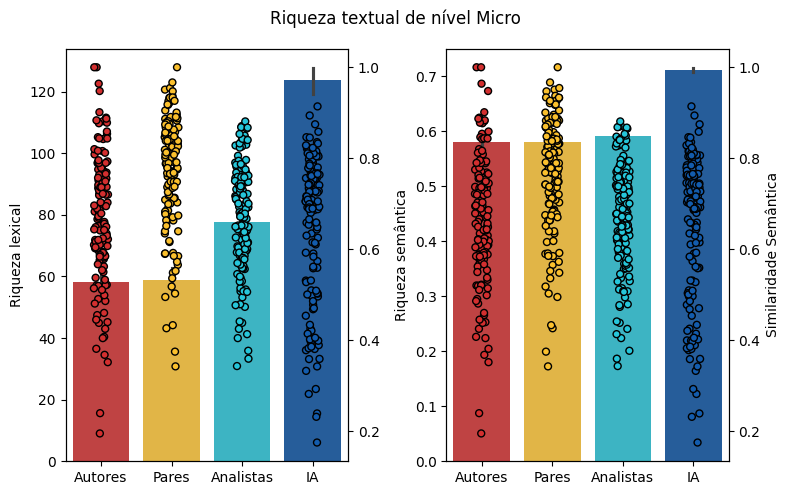

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(8,5))
for richness,ax in zip(['lexical_richness', 'semantic_richness'], axes):
    df = df_micro_richness.xs(richness, level=0, axis = 1)
    sns.barplot(data=df, ax = ax, palette=colors_single)
    
    if richness == 'semantic_richness':
        label = 'Riqueza semântica'
    else:
        label = 'Riqueza lexical'
    ax.set_ylabel(label)

for ax in axes:

    df_all = pd.concat({dimension : df['similarity'] for dimension, df in dfs_micro_ordered.items()}, axis = 1)
    secx = ax.twinx()
    if ax == axes[-1]:
        secx.set_ylabel('Similaridade Semântica')
    sns.stripplot(data=df_all, ax = secx, edgecolor='black', linewidth=1, palette=colors_single)

fig.suptitle('Riqueza textual de nível Micro')
fig.tight_layout()
fig.savefig(f'{results_dir}/micro_textual_richness_similarity_bar.png', dpi = 300)

In [ ]:
df_authors_micro_levels = df_authors_peers_micro[df_authors_peers_micro['Tipo de Participação autores ou pares'] == 'Participou'].copy()
df_authors_micro_levels['film_id'] = df_authors_micro_levels['ID Filme']



columns = ['2013a_Em uma ou duas palavras é um filme sobre...:','2009_Como você resumiria este filme? (em poucas palavras)']
column_author_level = 'Score de Participação autores ou pares de 0 a 5'

df_authors_micro_levels['micro'] = df_authors_micro[columns[0]] + '\n' + df_authors_micro[columns[1]]
df_authors_micro_levels['author_index'] = df_authors_micro_levels.groupby(['film_id', column_author_level]).cumcount()  + 1

df_authors_micro_levels_wide = df_authors_micro_levels.pivot(index='film_id', columns=[column_author_level,'author_index'], values='micro')
df_authors_micro_levels_wide.sort_index(axis=1, inplace= True)


In [ ]:
def get_text_richness_micro_agent(transcript):
    
    if isinstance(transcript, float):
        return np.nan, np.nan

    clean_transcript = transcript_analysis.clean_transcript(transcript)

    try:
        lexical = transcript_analysis.lexical_richness(clean_transcript)
    except:
        lexical = np.nan
    try:
        semantic = transcript_analysis.semantic_richness(clean_transcript)
    except ValueError:
        semantic = np.nan

    return lexical, semantic

_dfs_micro = {'Autores' : df_authors_micro_levels_wide, 
              'Pares' : df_peers_micro_wide, 
              'Analistas' : df_micro_analysts[['micro_SV','micro_VS']], 
              'IA' : df_micro_ai[['micro_ChatGPT','micro_Gemini']]}

dfs_micro_text_richness = {}
for dimension, df in _dfs_micro.items():
    print(dimension)

    file_path = f'{results_dir}/df_micro_text_richness_{dimension}.csv'
    if not os.path.exists(file_path):

        df_out = pd.concat({col: df[col].map(get_text_richness_micro_agent).apply(pd.Series) for col in df.columns}, axis=1)
        df_out.rename(columns={0: "lexical_richness", 1: "semantic_richness"}, level=-1, inplace=True)
        df_out.columns = df_out.columns.set_names(df.columns.names + ['text_richness'])
        
        df_out.to_csv(file_path)
    else:
        if dimension == 'Autores':
            headers = [0,1,2]
        else:
            headers = [0,1]

        df_out = pd.read_csv(file_path, index_col=0, header = headers)    
    
    dfs_micro_text_richness[dimension] = df_out



Autores
Pares
Analistas
IA


In [ ]:
colors_agents = ['#EF9A9A', '#E53935', '#B71C1C', '#FDD835', '#1FA7C5', '#0097A7', '#4C9FEA', '#1E88E5']

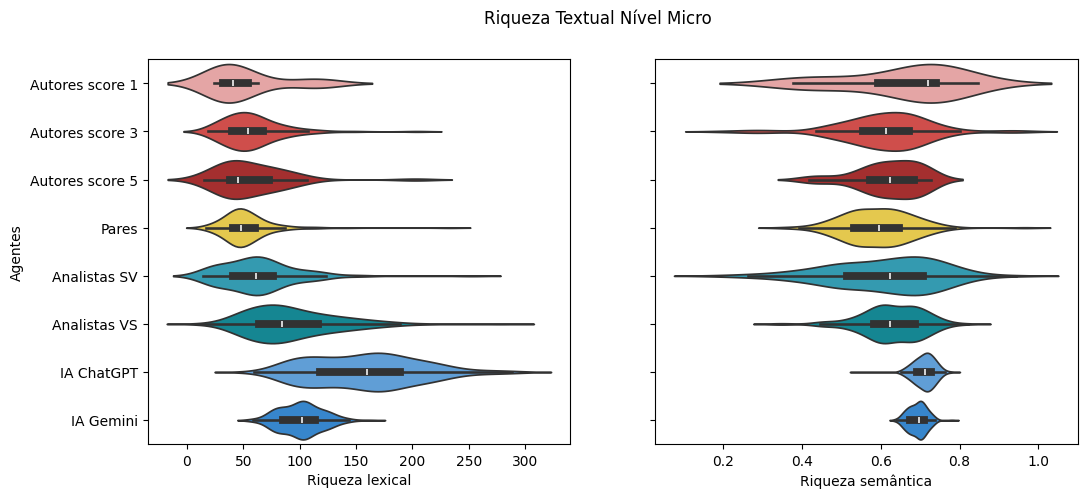

In [ ]:
fig, axes = plt.subplots(1,2, sharey=True, figsize=(12,5))

for richness, ax in zip(['lexical_richness', 'semantic_richness'], axes):
    
    df_richness_list = []
    for dimension, df in dfs_micro_text_richness.items():
        df = df.xs(richness, level = -1, axis = 1)
        if dimension != 'Pares':
                
            df = df.T.groupby(level=0).mean().T

            if dimension == 'Autores':
                df.rename(columns = {col : f'{dimension} score {col}' for col in df.columns}, inplace=True)
            else:
                df.rename(columns = {col : f'{dimension} {col.replace('micro_', '')}' for col in df.columns}, inplace = True)
            
        else:
            df = df.T.groupby(level=0).mean().mean()
            df.name = dimension
        df_richness_list.append(df)

    df_richness = pd.concat(df_richness_list, axis = 1)

    sns.violinplot(data=df_richness, orient='h', ax = ax, palette=colors_agents)
    ax.set_ylabel('Agentes')
    
    if richness == 'lexical_richness':
        label = 'Riqueza lexical'
    else:
        label = 'Riqueza semântica'
    ax.set_xlabel(label)

    df_richness.to_excel(f'{results_dir}/micro_{richness}_agents.xlsx')

fig.suptitle('Riqueza Textual Nível Micro')
fig.savefig(f'{results_dir}/micro_textual_richness_agents.png', dpi = 300)
plt.show()

## Análise nível Meso

In [ ]:
dfs_meso = {}
dfs_meso_agreements = {}
column_themes = ['Tema 0', 'Tema 2', 'Tema 3']

### Analistas

In [ ]:
df_analysts = pd.read_excel(f'{root_dir}/Dados Analistas/Analistas - Empilhada - Tratada e Limpa V02.xlsx')

In [ ]:
df_analysts_sv = df_analysts[df_analysts['A.01b - Analista'] == 'SV'].copy()
df_analysts_vs = df_analysts[df_analysts['A.01b - Analista'] == 'VS'].copy()

2. Extração do ID do filme

In [ ]:
column = 'ID Filme Novo'

df_analysts_sv['film_id'] = df_analysts_sv[column]
df_analysts_vs['film_id'] = df_analysts_vs[column]



In [ ]:
df_analysts_sv = df_analysts_sv[df_analysts_sv['film_id'] > 1069000]
df_analysts_vs = df_analysts_vs[df_analysts_vs['film_id'] > 1069000]

* Nota: O filme "Transcriar" tem dois filmes com o mesmo ID. O mesmo foi observado para os dados de IA

In [ ]:
print(df_analysts_vs[df_analysts_vs['film_id'].duplicated(keep=False)][["ID e Nome do Filme", 'film_id']])
print(df_analysts_sv[df_analysts_sv['film_id'].duplicated(keep=False)][["ID e Nome do Filme", 'film_id']])

Empty DataFrame
Columns: [ID e Nome do Filme, film_id]
Index: []
Empty DataFrame
Columns: [ID e Nome do Filme, film_id]
Index: []


3. Extração de categorias

In [ ]:
for col in column_themes:

    df_analysts_sv[col] = df_analysts_sv[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()
    df_analysts_vs[col] = df_analysts_vs[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

* Nota: correção manual de categorias

In [ ]:
df_analysts_sv.set_index('film_id', inplace = True)
df_analysts_vs.set_index('film_id', inplace = True)

df_analysts_sv.index = df_analysts_sv.index.astype(str)
df_analysts_vs.index = df_analysts_vs.index.astype(str)

df_analysts_sv.loc['1080403', 'Tema 3'] = 'recreação, lazer e entretenimento'
df_analysts_sv.loc['1110215', 'Tema 3'] = 'solidão'

In [ ]:
df_merge_analysts = pd.concat({'SV' : df_analysts_sv[column_themes], 'VS' : df_analysts_vs[column_themes]}, axis = 1)

In [ ]:
alphas = []

df_num = utils.cat_to_numeric(df_merge_analysts)

for col in column_themes:
    data = df_num.xs(col, level=1, axis = 1)

    alphas.append(krippendorff.alpha(reliability_data=data.T, level_of_measurement='nominal'))

dfs_meso['Analistas'] = pd.DataFrame(alphas, index=column_themes, columns=[r'Krippendorff $\alpha$'])

In [ ]:
agreements = []

for col in column_themes:

    df = df_merge_analysts.xs(col, level = 1, axis = 1)

    agreement = df['VS'] == df['SV']

    agreements.append((agreement.sum() / len(df))*100)

dfs_meso_agreements['Analistas'] = pd.DataFrame(agreements, index = column_themes, columns=['Taxa de concordância (%)'])

### IA

In [ ]:
df_ai = pd.read_excel(f'{root_dir}/Dados IA/AN-IAv3 - SVVS_ChatGPT-Gemini.xlsx')

In [ ]:
df_ai['film_id'] = df_ai['IDFilme_NOVOID3']
#df_ai.set_index('film_id', inplace = True)

In [ ]:
df_ai = df_ai[df_ai['film_id'] > 1069000]

In [ ]:
df_ai.rename(columns={'Tema 1' : 'Tema 0'}, inplace=True)

for col in column_themes:
    df_ai[col] = df_ai[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

In [ ]:
df_ai_gemini = df_ai[df_ai['NA (quem processou a IA)'] == 'VS'].copy()
df_ai_chatgpt = df_ai[df_ai['NA (quem processou a IA)'] == 'SV'].copy()

df_ai_gemini['film_id'] = df_ai_gemini['IDFilme_NOVOID3']
df_ai_chatgpt['film_id'] = df_ai_chatgpt['IDFilme_NOVOID3']

In [ ]:
df_ai_chatgpt[df_ai_chatgpt['film_id'].duplicated(keep=False)].sort_values(by='film_id')[['film_id', 'Oficina','ID']]

,film_id,Oficina,ID
66,1080411,10804,4067
169,1080411,10804,4170
81,1090102,10901,4082
80,1090102,10901,4081
106,1110209,11102,4107
118,1110209,11102,4119


In [ ]:
df_ai_gemini[df_ai_gemini['film_id'].duplicated(keep=False)].sort_values(by='film_id')[['film_id', 'Oficina','ID']]

,film_id,Oficina,ID
176,1070107,10701,5007
177,1070107,10701,5008
192,1080107,10801,5023
193,1080107,10801,5024
221,1080410,10804,5052
222,1080410,10804,5053


In [ ]:
df_ai_chatgpt = df_ai_chatgpt.sort_values('ID').drop_duplicates(subset='film_id', keep = 'last').set_index('film_id')      
df_ai_gemini = df_ai_gemini.sort_values('ID').drop_duplicates(subset='film_id', keep = 'last').set_index('film_id')

df_ai_chatgpt.index = df_ai_chatgpt.index.astype(str)
df_ai_gemini.index = df_ai_gemini.index.astype(str)

df_merge_ai = pd.concat({'ChatGPT' : df_ai_chatgpt[column_themes], 'Gemini' : df_ai_gemini[column_themes]}, axis = 1)



In [ ]:
alphas = []

df_num = utils.cat_to_numeric(df_merge_ai)

for col in column_themes:
    data = df_num.xs(col, level=1, axis = 1)

    alphas.append(krippendorff.alpha(reliability_data=data.T, level_of_measurement='nominal'))

dfs_meso['IA'] = pd.DataFrame(alphas, index=column_themes, columns=[r'Krippendorff $\alpha$'])

In [ ]:
agreements = []

for col in column_themes:

    df = df_merge_ai.xs(col, level = 1, axis = 1)

    agreement = df['ChatGPT'] == df['Gemini']

    agreements.append((agreement.sum() / len(df))*100)

dfs_meso_agreements['IA'] = pd.DataFrame(agreements, index = column_themes, columns=['Taxa de concordância (%)'])

### Autores e Pares

In [ ]:
df_authors_peers = pd.read_excel(f'{root_dir}/Dados Autores e Pares/Empilhado_SVVS Partes 1 e 2 Empilhado - regular.xlsx')

In [ ]:
df_authors_peers['film_id'] = df_authors_peers['ID Filme']
df_authors_peers = df_authors_peers[df_authors_peers['film_id'] > 1069000]

In [ ]:
df_authors_peers.set_index(['Analista','film_id'], inplace = True)

In [ ]:
for col in column_themes:
    
    df_authors_peers[col] = df_authors_peers[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

In [ ]:
column_status = 'Tipo de Participação autores ou pares'

df_authors = df_authors_peers[df_authors_peers[column_status] == 'Participou'].copy()
df_peers = df_authors_peers[df_authors_peers[column_status] == 'Não Participou'].copy()

df_authors_vs = df_authors.loc['VS']
df_authors_sv = df_authors.loc['SV']

df_peers_vs = df_peers.loc['VS']
df_peers_sv = df_peers.loc['SV']

In [ ]:
importlib.reload(utils)

df_supervisors = {'SV' : {'autores' : df_authors_sv, 'pares' : df_peers_sv},
       'VS' : {'autores' : df_authors_vs, 'pares' : df_peers_vs}}

results = []
for analyst, analyst_df in df_supervisors.items():
    for label, df in analyst_df.items():
        df = df.copy()
        df[label] = df.groupby('film_id').cumcount() + 1
        pt = df.reset_index(drop=False).set_index(['film_id', label])[column_themes].unstack(label)

        df_num = utils.cat_to_numeric(pt[column_themes])

        themes = pt.columns.get_level_values(0).unique()

        for theme in themes:
            data = df_num.xs(theme, level=0, axis = 1)

            results.append([analyst, label, theme, krippendorff.alpha(data.T)])

df_results = pd.DataFrame(results, columns=['Analista', 'Dimensão', 'Tema', r'Krippendorff $\alpha$'])

In [ ]:
dfs_meso['Autores'] = df_results[df_results['Dimensão'] == 'autores'].pivot_table(values = r'Krippendorff $\alpha$', columns='Analista', index='Tema')
dfs_meso['Pares'] = df_results[df_results['Dimensão'] == 'pares'].pivot_table(values = r'Krippendorff $\alpha$', columns='Analista', index='Tema')

In [ ]:
results = []
for analyst, analyst_df in df_supervisors.items():
    for label, df in analyst_df.items():
        df = df.copy()
        df[label] = df.groupby('film_id').cumcount() + 1
        pt = df.reset_index(drop=False).set_index(['film_id', label])[column_themes].unstack(label)

        for theme in column_themes:
            for film_id, row in pt[theme].iterrows():
                results.append([film_id, analyst, label, theme, row.dropna().duplicated().any()])

df_results_agreement = pd.DataFrame(results, columns = ['film_id', 'Analista', 'Dimensão', 'Tema', 'Concordância'])
        

In [ ]:
from itertools import product

results = []

combinations = list(product(column_themes, ['autores', 'pares'], ['VS', 'SV']))

for combination in combinations:
    theme, dimension, analyst = combination

    df = df_results_agreement[(df_results_agreement['Tema'] == theme) & 
                    (df_results_agreement['Dimensão'] == dimension) &
                    (df_results_agreement['Analista'] == analyst)]

    results.append([theme, dimension, analyst, (df['Concordância'].sum() / len(df))*100])

df_results_agreement = pd.DataFrame(results, columns=['Tema', 'Dimensão', 'Analista', 'Taxa de Concordância (%)'])

dfs_meso_agreements['Autores'] = df_results_agreement[df_results_agreement['Dimensão'] == 'autores'].pivot_table(values = 'Taxa de Concordância (%)', columns='Analista', index='Tema')
dfs_meso_agreements['Pares'] = df_results_agreement[df_results_agreement['Dimensão'] == 'pares'].pivot_table(values = 'Taxa de Concordância (%)', columns='Analista', index='Tema')


### Comparações

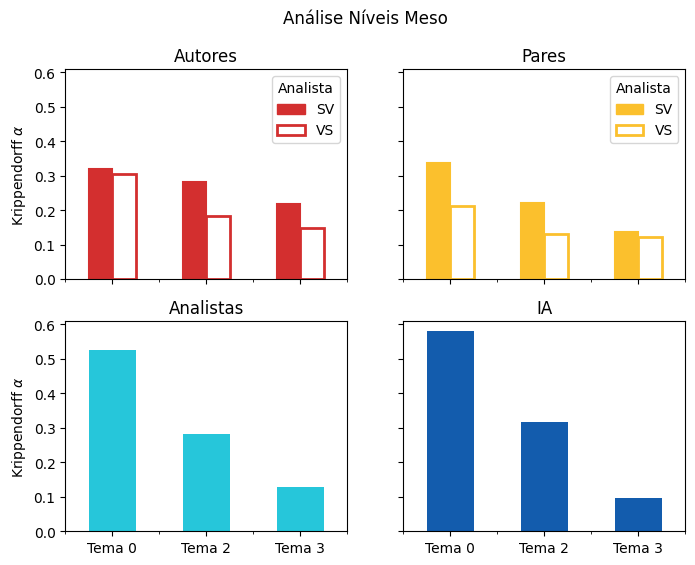

In [ ]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8,6))

dfs_meso = {k : dfs_meso[k] for k in ['Autores', 'Pares', 'Analistas', 'IA']}

for idx, ((label, df), ax) in enumerate(zip(dfs_meso.items(), axes.flat)):
    if label in ['Autores', 'Pares']:
        legend = True
    else:
        legend = False
    
    df.plot(kind='bar', ax = ax, legend=legend, color=colors_single[idx])

    if label in ['Autores', 'Pares']:

        n_rows, n_cols = df.shape
        bars = ax.patches

        for col_idx in range(n_cols):
            for row_idx in range(n_rows):
                i = col_idx * n_rows + row_idx
                bar = bars[i]
        
                if col_idx == 0:
                    bar.set_facecolor(colors_single[idx])
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(1.5)
                else:
                    bar.set_facecolor("none")
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(2.0)
        legend_items = [Patch(facecolor=colors_single[idx], edgecolor=colors_single[idx], label=df.columns[0]),
                        Patch(facecolor="none", edgecolor=colors_single[idx], linewidth=2, label=df.columns[1])]
        
        ax.legend(handles=legend_items, title="Analista")


    ax.set_ylabel(r'Krippendorff $\alpha$')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(label)

fig.suptitle('Análise Níveis Meso')
fig.savefig(f'{results_dir}/meso.png')
plt.show()

In [ ]:
df = pd.concat({k : v for k,v in dfs_meso.items()}, axis = 1)
df.to_excel(f'{results_dir}/meso.xlsx')

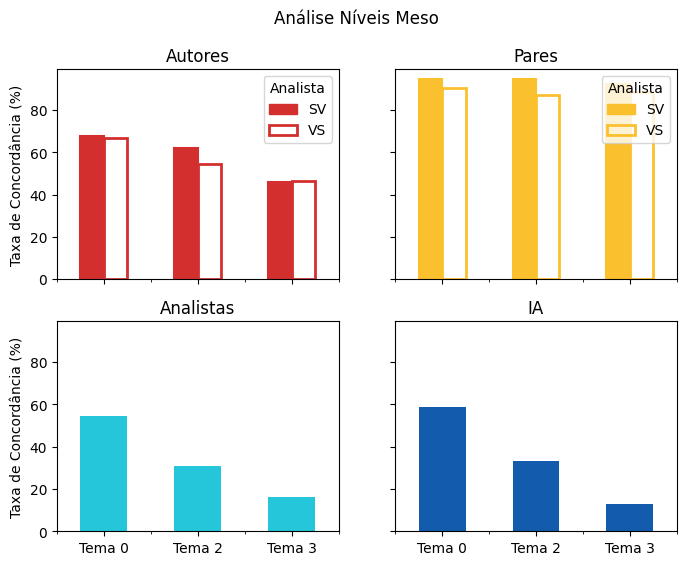

In [ ]:
fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8,6))

dfs_meso_agreements = {k : dfs_meso_agreements[k] for k in ['Autores', 'Pares', 'Analistas', 'IA']}

for idx, ((label, df), ax) in enumerate(zip(dfs_meso_agreements.items(), axes.flat)):
    if label in ['Autores', 'Pares']:
        legend = True
    else:
        legend = False
    df.plot(kind='bar', ax = ax, legend=legend, color=colors_single[idx])

    if label in ['Autores', 'Pares']:

        n_rows, n_cols = df.shape
        bars = ax.patches

        for col_idx in range(n_cols):
            for row_idx in range(n_rows):
                i = col_idx * n_rows + row_idx
                bar = bars[i]
        
                if col_idx == 0:
                    bar.set_facecolor(colors_single[idx])
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(1.5)
                else:
                    bar.set_facecolor("none")
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(2.0)
        legend_items = [Patch(facecolor=colors_single[idx], edgecolor=colors_single[idx], label=df.columns[0]),
                        Patch(facecolor="none", edgecolor=colors_single[idx], linewidth=2, label=df.columns[1])]
        
        ax.legend(handles=legend_items, title="Analista")
    
    ax.set_ylabel('Taxa de Concordância (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(label)

fig.suptitle('Análise Níveis Meso')
fig.savefig(f'{results_dir}/meso_concordancia.png')
plt.show()

In [ ]:
df = pd.concat({k : v for k,v in dfs_meso_agreements.items()}, axis = 1)
df.to_excel(f'{results_dir}/meso_concordancia.xlsx')

In [ ]:
import collections

dfs_dimensions = {'authors' : {'SV' : df_authors_sv, 'VS' : df_authors_vs}, 
                  'peers' : {'SV' : df_peers_sv, 'VS' : df_peers_vs}
                  }

processed_dfs = collections.defaultdict(dict)

for dimension, dfs in dfs_dimensions.items():
    for analyst, df in dfs.items():
        df = df.copy()
        df['rater'] = df.groupby('film_id').cumcount().add(1)

        df_long = df.reset_index(drop=False).set_index(['film_id', 'rater'])
        df_long = df_long[column_themes]

        df_wide = df_long.unstack('rater')
        df_wide.columns = df_wide.columns.swaplevel(0,1)
        df_wide = df_wide.sort_index(axis = 1, level=[0,1])

        processed_dfs[dimension][analyst] = df_wide

In [ ]:
df_merge_authors = pd.concat({'SV' : processed_dfs['authors']['SV'], 'VS' : processed_dfs['authors']['VS']}, axis = 1)
df_merge_peers = pd.concat({'SV' : processed_dfs['peers']['SV'], 'VS' : processed_dfs['peers']['VS']}, axis = 1)

In [ ]:
df_merge_analysts.columns = df_merge_analysts.columns.set_names(['rater', 'level'])
df_merge_ai.columns = df_merge_ai.columns.set_names(['rater', 'level'])
df_merge_authors.columns = df_merge_authors.columns.set_names(['supervisor', 'rater', 'level'])
df_merge_peers.columns = df_merge_peers.columns.set_names(['supervisor', 'rater', 'level'])

In [ ]:
dfs = {'Autores' : df_merge_authors,  
       'Pares' : df_merge_peers, 
       'Analistas' : df_merge_analysts,
       'IA' : df_merge_ai
       }

In [ ]:
flat = {}

for dimension, df in dfs.items():
    df_flat = df.copy()
    df_flat.columns = ["_".join(map(str, col)) for col in df.columns]

    flat[dimension] = df_flat

dfs_flat = pd.concat({k : v for k,v in flat.items()}, axis=1)

def get_human_ai_correspondence(row):

    human = row[row.index.get_level_values(0).isin(['Autores','Pares', 'Analistas'])].dropna()
    ai = row[row.index.get_level_values(0).isin(['IA'])].dropna()

    human_categories = set(human.unique())
    ai_categories = set(ai.unique())
    
    if len(human_categories.intersection(ai_categories)):
        return True
    else:
        return False

dfs_flat['correspondence'] = dfs_flat.apply(get_human_ai_correspondence, axis = 1)

dfs_flat['correspondence'].describe()


count       299
unique        2
top       False
freq        151
Name: correspondence, dtype: object

### MASI

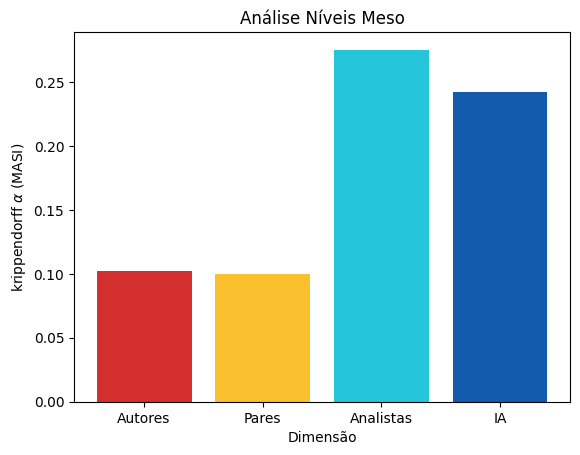

In [ ]:
alphas = []
for dimension, df in dfs.items():
    alpha = utils.krippendorff_alpha_masi(df)
    alphas.append(alpha)    

plt.bar(dfs.keys(), alphas, color = colors_single)
plt.xlabel('Dimensão')
plt.ylabel(r'krippendorff $\alpha$ (MASI)')
plt.title('Análise Níveis Meso')
plt.savefig(f'{results_dir}/meso_MASI.png', dpi = 300)
plt.show()

df = pd.DataFrame([alphas], columns=dfs.keys())
df.to_excel(f'{results_dir}/meso_MASI.xlsx')

### Concordância por categoria

In [ ]:
categories = set()
for df in dfs.values():
    for col in df.columns:
        categories.update(df[col].dropna().unique())
categories = sorted(list(categories), reverse=True)

In [ ]:
results = []
for dimension, df in dfs.items():

    df_labels = df.xs('Tema 0', level=-1, axis = 1)
    #df_labels = df.loc[:, df.columns.get_level_values(-1).isin(column_themes)] # it gives very low alphas for all dimensions
    if dimension in ['Autores', 'Pares']:
        df_labels = (df_labels.stack(level=0, future_stack=True).reset_index()).set_index('film_id').drop('supervisor', axis = 1)
    alphas = []
    for cat in categories:
        df_cat = (df_labels == cat).astype(float)
        if df_cat.sum().sum() == 0:
            alpha = np.nan
        else:
            alpha = krippendorff.alpha(reliability_data=df_cat.T, level_of_measurement='nominal')
        alphas.append(alpha)
    
    results.append(alphas)

df_alphas_categories = pd.DataFrame(np.asarray(results).T, columns=dfs.keys(), index = categories)    

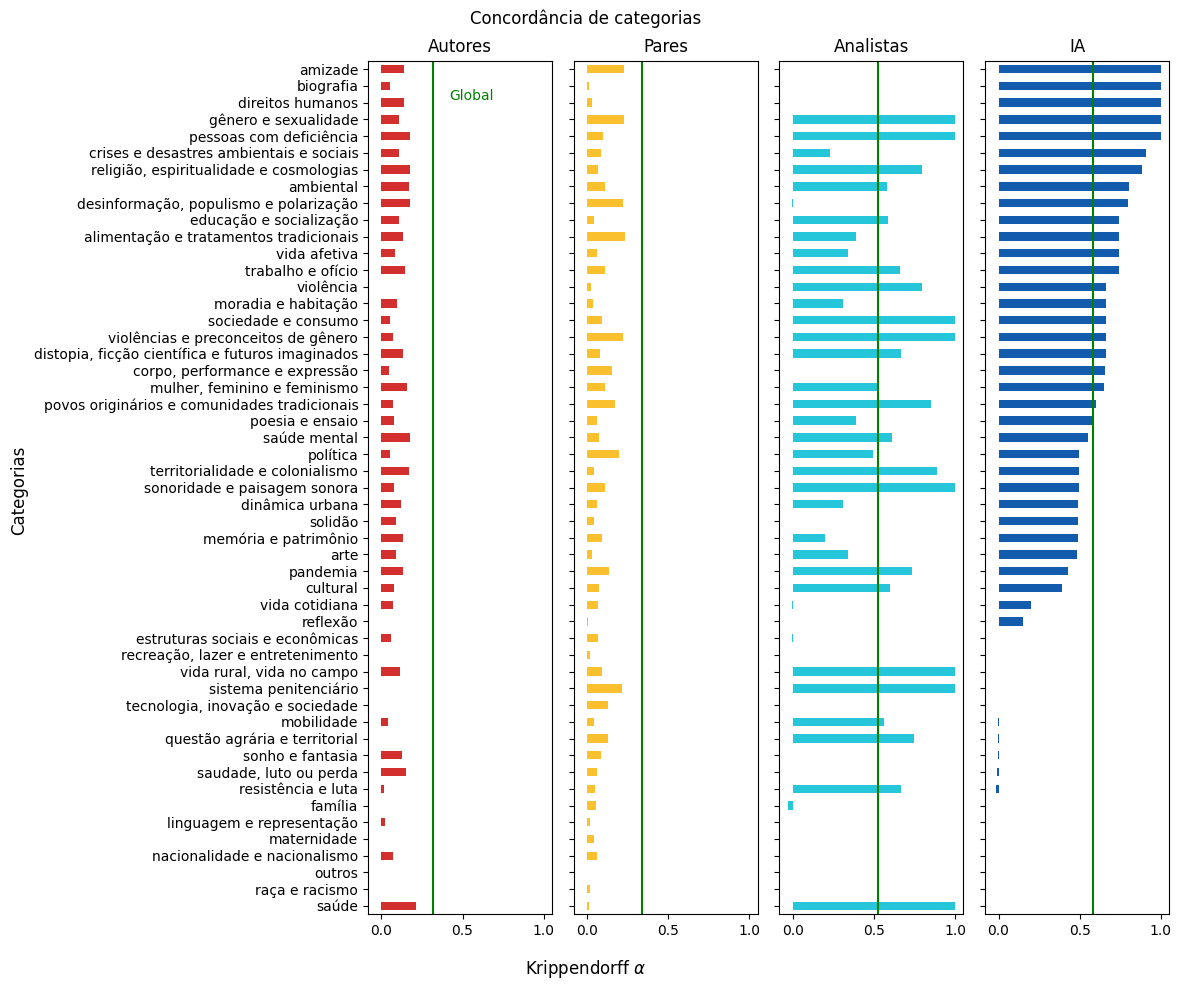

In [ ]:
fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

df_sorted = df_alphas_categories['IA'].sort_values(na_position='first')
df_alphas_categories_sorted = df_alphas_categories.loc[df_sorted.index]

for idx, (col, ax) in enumerate(zip(['Autores', 'Pares', 'Analistas', 'IA'], axes.flat)):
    
    df_alphas_categories_sorted[col].plot(kind='barh', ax = ax, color = colors_single[idx])
    ax.set_title(col)
    ax.axvline(dfs_meso[col].loc['Tema 0'].values[0], color = 'green')
    ax.set_xticks([0,0.5,1])

    if ax == axes[0]:
        ax.text(x=dfs_meso[col].loc['Tema 0'].values[0] + 0.1, y = 48,
        s='Global', 
        color='green', 
        fontsize=10,
        va='bottom',
        ha='left',
        backgroundcolor='white'
        )

fig.suptitle('Concordância de categorias')
fig.supxlabel(r'Krippendorff $\alpha$')
fig.supylabel('Categorias')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_per_cat.png', dpi = 300)
plt.show()

df_alphas_categories_sorted.to_excel(f'{results_dir}/meso_per_cat.xlsx')

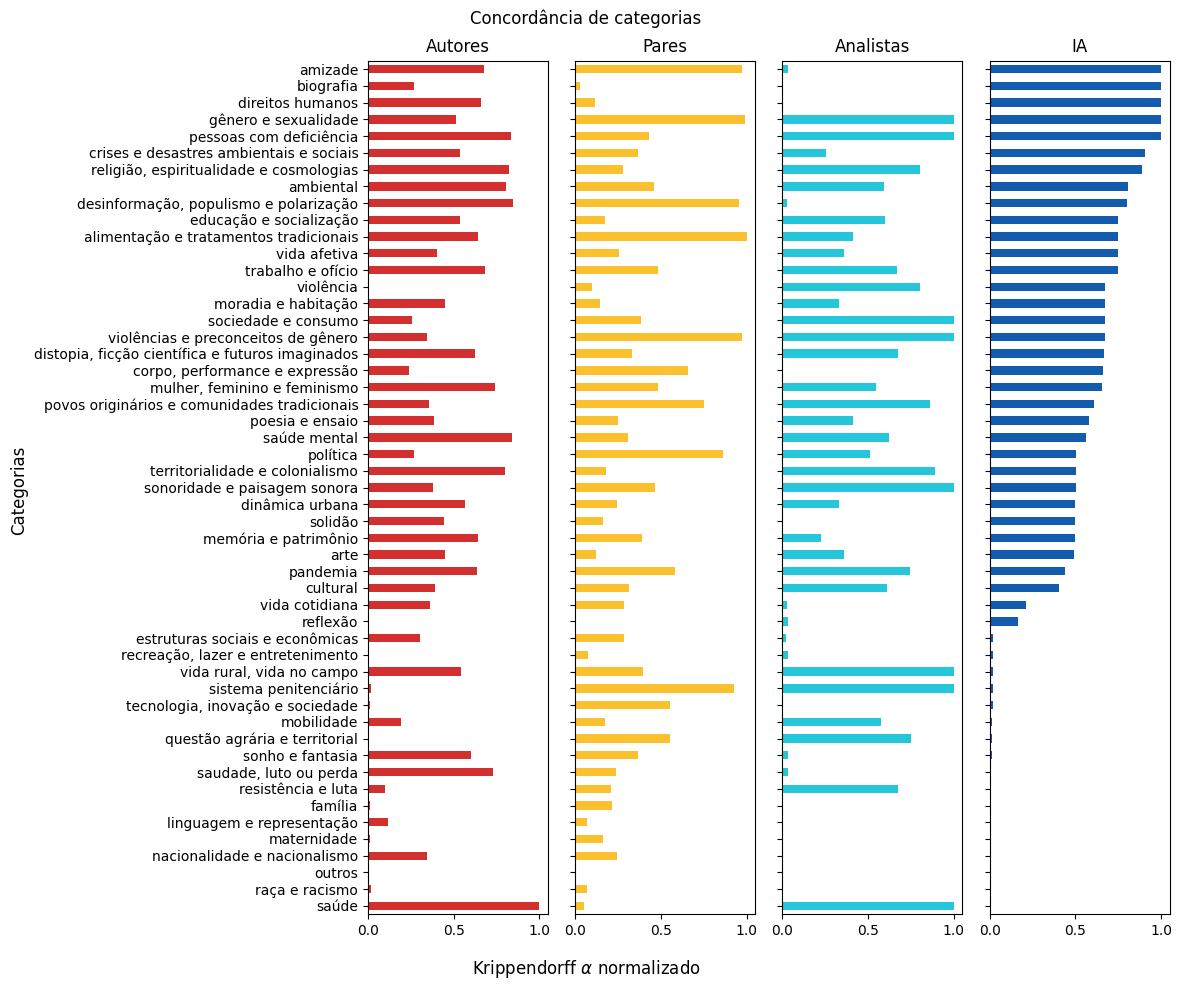

In [ ]:
fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

df_alphas_categories_normalized = (df_alphas_categories - df_alphas_categories.min()) / (df_alphas_categories.max() - df_alphas_categories.min())
df_alphas_categories_normalized = df_alphas_categories_normalized.sort_values(by='IA', na_position='first')

for idx, (col, ax) in enumerate(zip(df_alphas_categories_normalized.columns, axes.flat)):
    data = df_alphas_categories_normalized[col]
    data.plot(kind='barh', ax = ax, color=colors_single[idx])
    ax.set_title(col)
    #ax.axvline(dfs_meso[col].loc['Tema 0'].values[0], color = 'green')
    ax.set_xticks([0,0.5,1])

fig.suptitle('Concordância de categorias')
fig.supxlabel(r'Krippendorff $\alpha$ normalizado')
fig.supylabel('Categorias')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_per_cat_minmax.png', dpi = 300)
plt.show()

df_alphas_categories_normalized.to_excel(f'{results_dir}/meso_per_cat_minmax.xlsx')

In [ ]:
results = []
for dimension, df in dfs.items():

    agreements = []
    for cat in categories:
        df_cat = (df == cat).astype(float)
        
        agreement_ratio = ((df_cat.eq(1).sum(axis=1) > 1).sum() / len(df_cat))*100
        agreements.append(agreement_ratio)
    
    results.append(agreements)

df_agreements_categories = pd.DataFrame(np.asarray(results).T, columns=dfs.keys(), index = categories)    

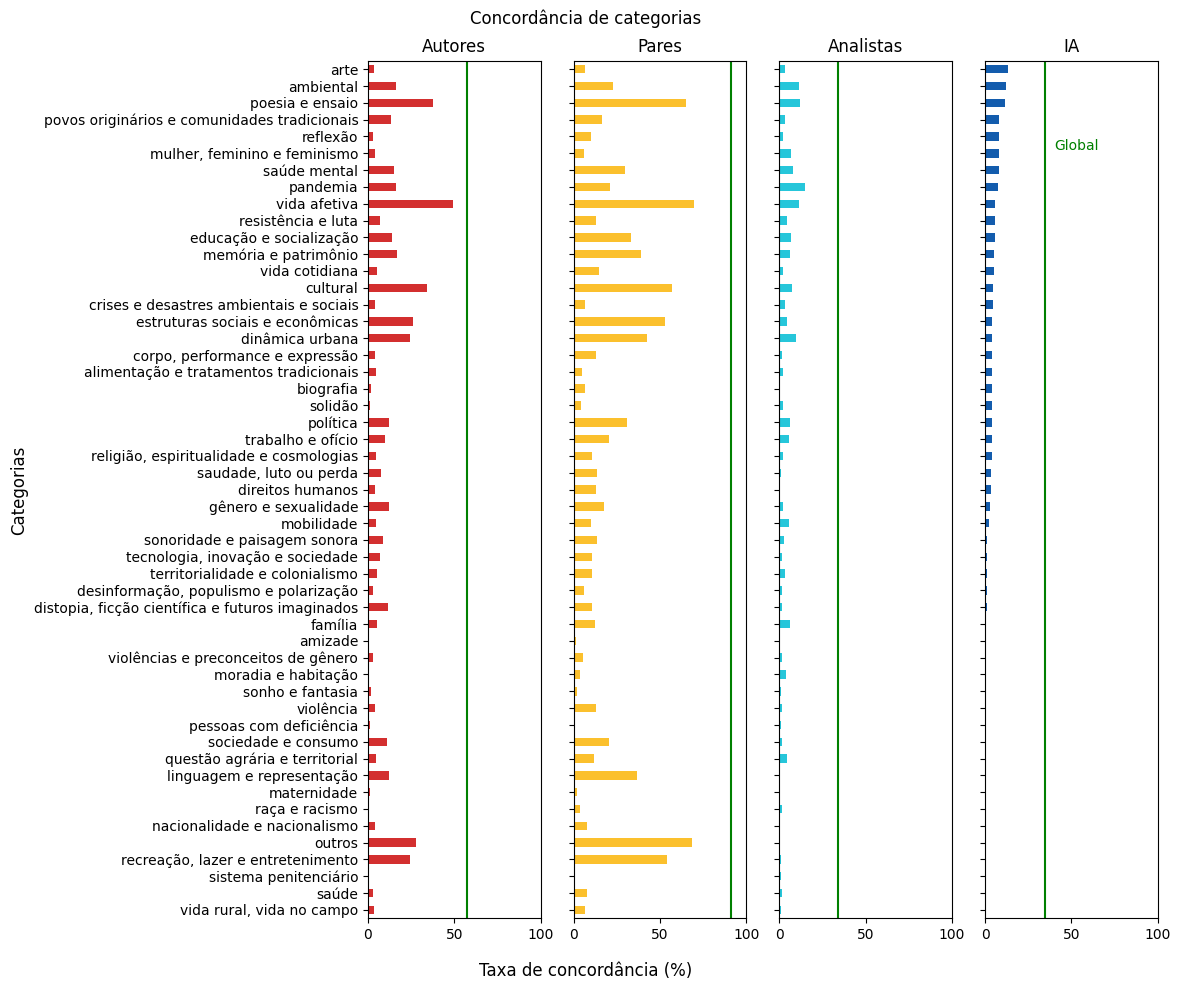

In [ ]:
df_agreements_categories = df_agreements_categories.sort_values(by='IA', na_position='first')

fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

for idx, (col, ax) in enumerate(zip(df_agreements_categories.columns, axes.flat)):
    df_agreements_categories[col].plot(kind='barh', ax = ax, color = colors_single[idx])
    ax.set_title(col)
    if col in ['Autores', 'Pares']:
        vline = dfs_meso_agreements[col].mean().mean()
    else:
        vline = dfs_meso_agreements[col].mean().values[0] 
    ax.axvline(vline, color = 'green')
    ax.set_xticks([0,50,100])

    if ax == axes[-1]:
        ax.text(x=vline + 5, y = 45,
        s='Global', 
        color='green', 
        fontsize=10,
        va='bottom',
        ha='left',
        backgroundcolor='white'
        )

fig.suptitle('Concordância de categorias')
fig.supxlabel('Taxa de concordância (%)')
fig.supylabel('Categorias')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_agreements_per_cat.png', dpi = 300)
plt.show()

df_agreements_categories.to_excel(f'{results_dir}/meso_agreements_per_cat.xlsx')

### Viés de categorias por dimensão

In [ ]:
long_frames = []

for dimension, df in dfs.items():
    tmp = df.copy()
    tmp = tmp.reset_index()
    tmp = tmp.rename(columns={tmp.columns[0]: "film_id"})
    
    flat_cols = []
    for col in tmp.columns:
        if any(str(c) == "film_id" for c in col):
            flat_cols.append("film_id")
        else:
            parts = [str(c) for c in col if c not in (None, "", "nan")]
            flat_cols.append("_".join(parts))
    tmp.columns = flat_cols

    label_cols = [c for c in tmp.columns if c != 'film_id']

    tmp_long = tmp.melt(
        id_vars="film_id",
        value_vars=label_cols,
        var_name="rater_level",
        value_name="label")

    tmp_long["group"] = dimension
    tmp_long = tmp_long.dropna(subset=["label"])

    long_frames.append(tmp_long)

df_long = pd.concat(long_frames, ignore_index=True)

category_counts = (
    df_long
    .groupby(["group", "label"])
    .size()
    .unstack(fill_value=0)
)

category_counts = category_counts.loc[['Autores', 'Pares', 'Analistas', 'IA']]

In [ ]:
category_counts.T.to_excel(f'{results_dir}/meso_category_counts.xlsx')

In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(category_counts)

expected = pd.DataFrame(
    expected,
    index=category_counts.index,
    columns=category_counts.columns,
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

residuals = (category_counts - expected) / np.sqrt(expected)

Chi-square statistic: 1895.7551179499164
Degrees of freedom: 150
p-value: 1.3720871631436334e-299


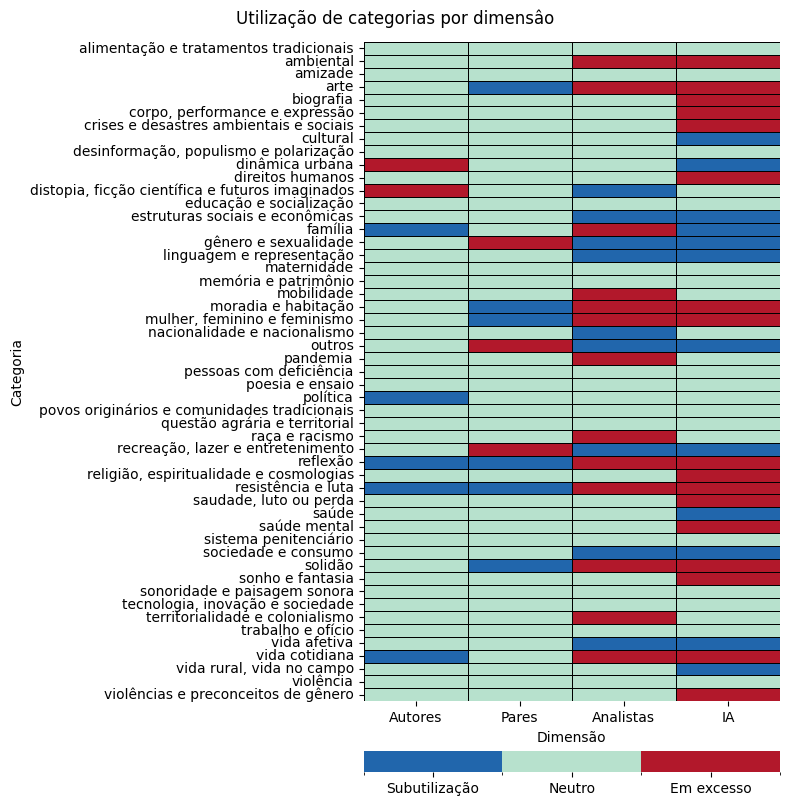

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm


vmin = np.nanmin(residuals.values)
vmax = np.nanmax(residuals.values)

underuse_thr = -2
overuse_thr  =  2

# Ensure boundaries cover both data range and thresholds
low_bound  = min(vmin, underuse_thr)
high_bound = max(vmax, overuse_thr)

boundaries = [low_bound, underuse_thr, overuse_thr, high_bound]

colors = [
    "#2166ac",
    "#b7e1cd",   
    "#b2182b" 
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, cmap.N)

fig, ax = plt.subplots(1,1, figsize=(8,9))

sns.heatmap(residuals.T, 
            cmap=cmap,
            norm=norm, 
            ax = ax,
            linewidths=0.5,
            linecolor='black',
            cbar_kws={"orientation": "horizontal", "pad": 0.06}
            )
ax.set_yticks(np.arange(0.5, category_counts.shape[1] + 0.5))
ax.set_yticklabels(category_counts.columns)
ax.set_xlabel('Dimensão')
ax.set_ylabel('Categoria')

cbar = ax.collections[0].colorbar
cbar.set_ticks([(low_bound + underuse_thr)/2, 0, (overuse_thr + high_bound)/2])
cbar.set_ticklabels(["Subutilização", "Neutro", "Em excesso"])

fig.suptitle('Utilização de categorias por dimensâo')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_category_usage.png', dpi = 300)
plt.show()

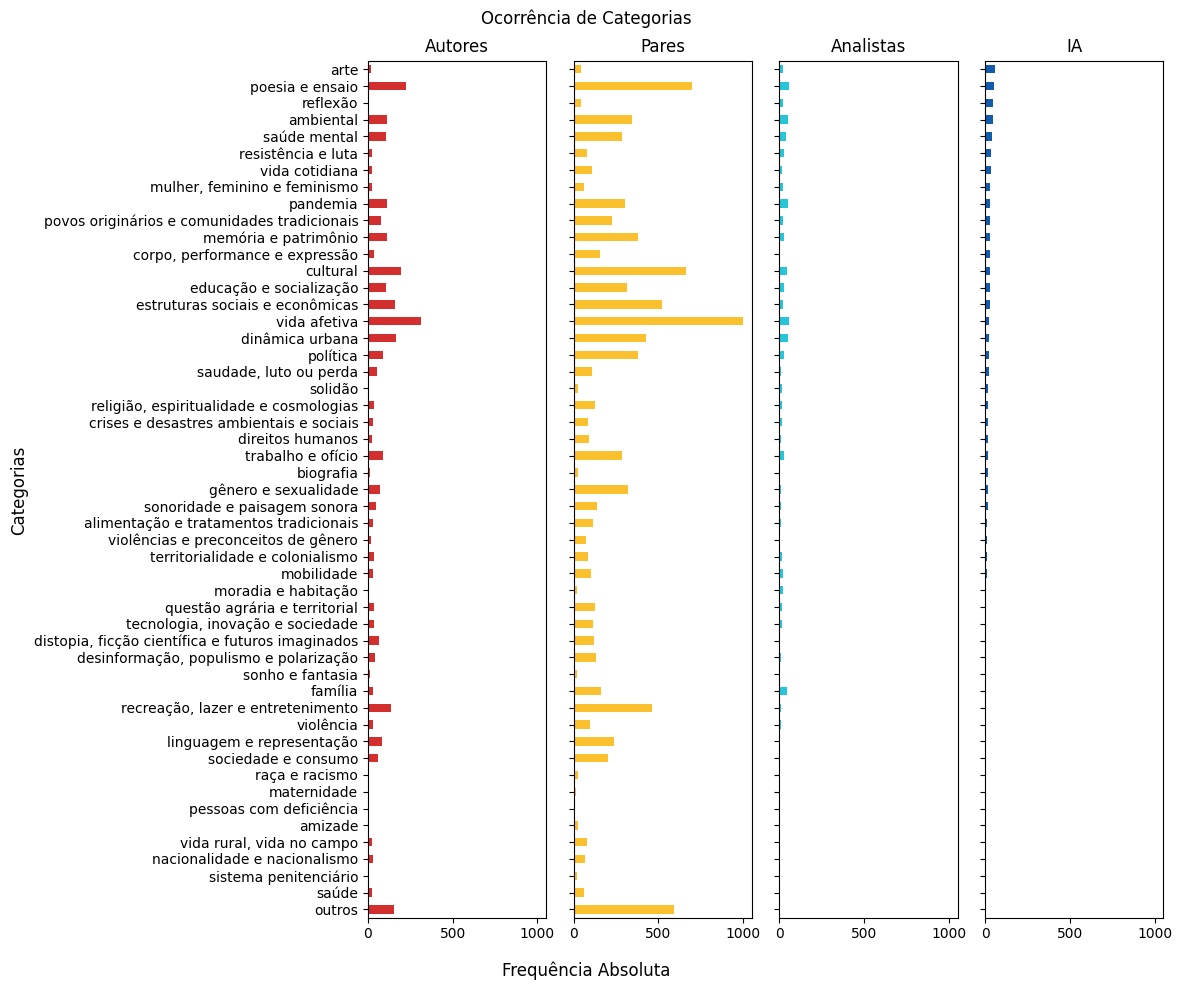

In [ ]:
fig, axes = plt.subplots(1,4, sharey=True, sharex=True, figsize=(12,10))

category_counts_sorted = category_counts.T.sort_values(by='IA', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_sorted.columns, axes.flat)):
    category_counts_sorted[dimension].plot(kind='barh', ax = ax, color=colors_single[idx])
    ax.set_ylabel('')
    ax.set_title(dimension)
    
fig.suptitle('Ocorrência de Categorias')
fig.supxlabel('Frequência Absoluta')
fig.supylabel('Categorias')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_category_usage_frequency.png', dpi = 300)
plt.show()

category_counts_sorted.to_excel(f'{results_dir}/meso_category_usage_frequency.xlsx')

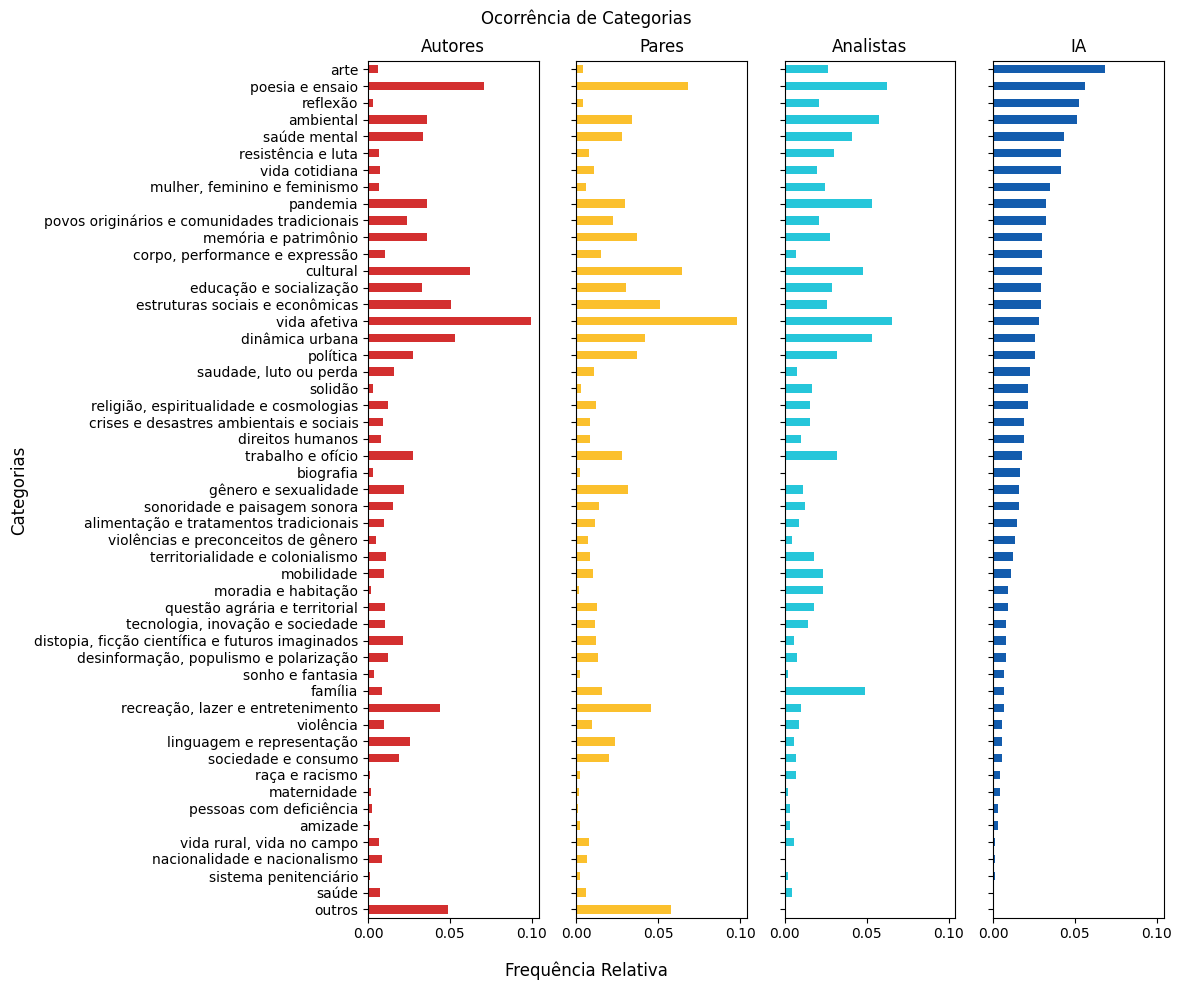

In [ ]:
category_counts_normalized = category_counts.div(category_counts.sum(axis=1), axis = 0)

fig, axes = plt.subplots(1,4, sharey=True, sharex=True, figsize=(12,10))

category_counts_normalized_sorted = category_counts_normalized.T.sort_values(by='IA', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_normalized_sorted.columns, axes.flat)):
    category_counts_normalized_sorted[dimension].plot(kind='barh', ax = ax, color=colors_single[idx])
    ax.set_ylabel('')
    ax.set_title(dimension)
    
fig.suptitle('Ocorrência de Categorias')
fig.supxlabel('Frequência Relativa')
fig.supylabel('Categorias')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_category_usage_frequency_relative.png', dpi = 300)
plt.show()

category_counts_normalized_sorted.to_excel(f'{results_dir}/meso_category_usage_frequency_relative.xlsx')

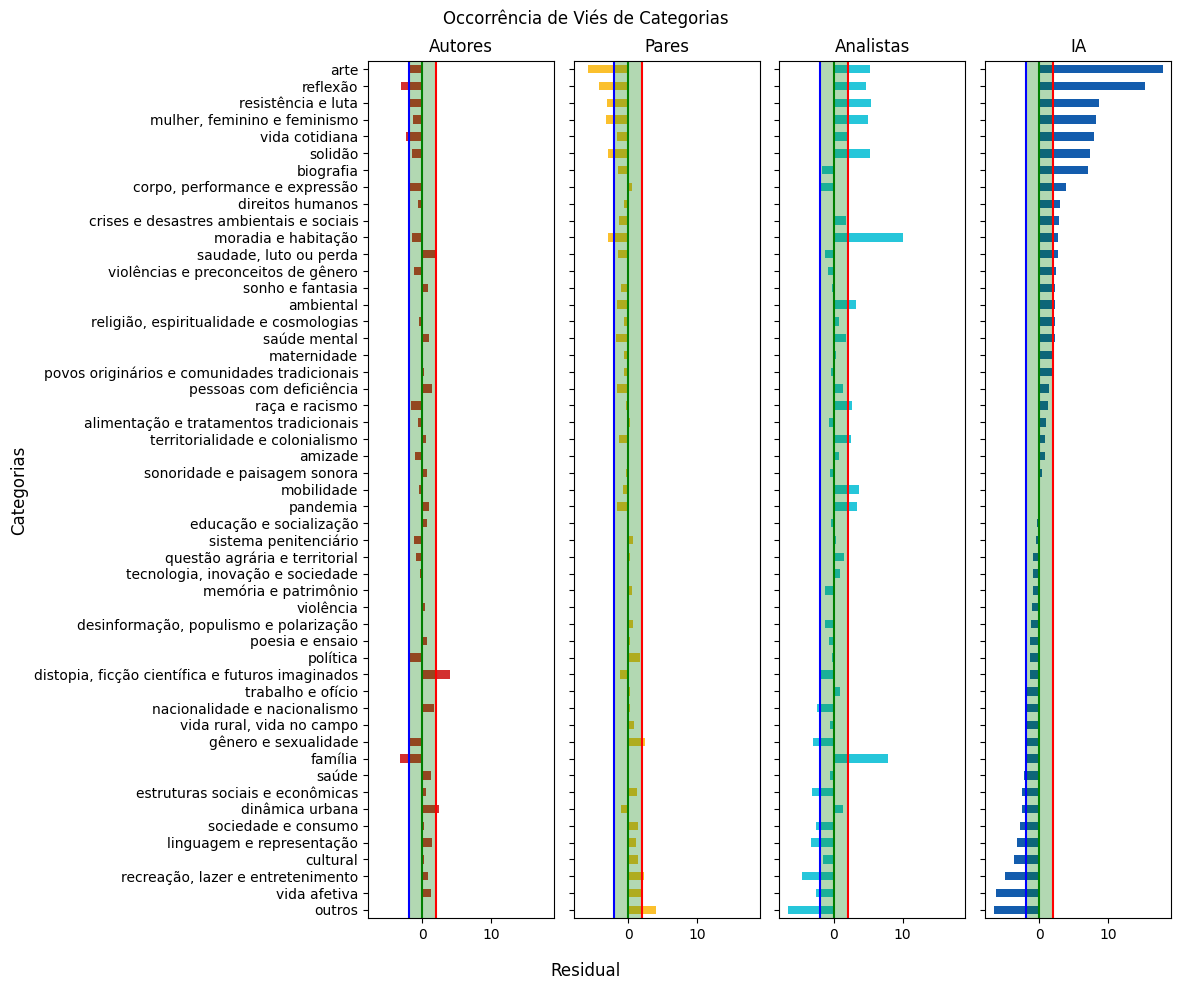

In [ ]:
residuals_sorted = residuals.T.sort_values(by='IA', na_position='first')

fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

for idx, (dimension, ax) in enumerate(zip(residuals_sorted.columns, axes.flat)):

    residuals_sorted[dimension].plot(kind='barh', ax = ax, color = colors_single[idx])

    ax.axvline(0, color = 'green')
    ax.axvspan(-2,2, alpha = 0.3, color='green', linewidth=0)
    ax.axvline(-2, color = 'blue', linewidth=1.5) #residuals_sorted.min().min()
    ax.axvline(2, color = 'red', linewidth=1.5) # residuals_sorted.max().max()

    ax.set_ylabel('')
    ax.set_title(dimension)

fig.suptitle('Occorrência de Viés de Categorias')
fig.supxlabel('Residual')
fig.supylabel('Categorias')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_category_bias.png', dpi = 300)
plt.show()

residuals_sorted.to_excel(f'{results_dir}/meso_category_bias.xlsx')

In [ ]:
_df_authors = df_authors.reset_index().copy()

_df_authors['rater_index'] = (_df_authors.groupby(['film_id', 'Analista', column_author_level]).cumcount() + 1)

df_authors_meso_wide = (_df_authors
                        .set_index(['film_id', 'Analista', column_author_level, 'rater_index'])[column_themes]
                        .unstack(['Analista', column_author_level,'rater_index']))

df_authors_meso_wide.columns = df_authors_meso_wide.columns.reorder_levels([1, 2, 3, 0])
df_authors_meso_wide.columns = df_authors_meso_wide.columns.set_names(['supervisor', 'score', 'rater', 'level'])
df_authors_meso_wide = df_authors_meso_wide.sort_index(axis=1, level = 0)

In [ ]:
long_frames = []

dfs_meso_agents = dfs.copy()

dfs_meso_agents['Autores'] = df_authors_meso_wide

for dimension, df in dfs_meso_agents.items():
    tmp = df.copy()
    tmp = tmp.reset_index()
    tmp = tmp.rename(columns={tmp.columns[0]: "film_id"})
    
    flat_cols = []
    for col in tmp.columns:
        if any(str(c) == "film_id" for c in col):
            flat_cols.append("film_id")
        else:
            parts = [str(c) for c in col if c not in (None, "", "nan")]
            flat_cols.append("_".join(parts))
    tmp.columns = flat_cols

    label_cols = [c for c in tmp.columns if c != 'film_id']

    tmp_long = tmp.melt(
        id_vars="film_id",
        value_vars=label_cols,
        var_name="rater_level",
        value_name="level")
    

    if dimension in ['Analistas', 'IA']:
        agents = [f'{dimension} {col.split('_')[0]}' for col in tmp_long['rater_level']]
    elif dimension == 'Pares':
        agents = [dimension] * len(tmp_long)
    else:
        agents = [f'{dimension} {' Score '.join(col.split('_')[:2])}' for col in tmp_long['rater_level']]

    tmp_long["group"] = agents
    tmp_long = tmp_long.dropna(subset=["level"])

    long_frames.append(tmp_long)

df_long = pd.concat(long_frames, ignore_index=True)

category_counts_agents = (
    df_long
    .groupby(["group", "level"])
    .size()
    .unstack(fill_value=0)
)


In [ ]:
idx = category_counts_agents.index.to_series()

mask_authors = idx.str.contains('Autores', case=False, na=False)

level_from_idx = idx.str.extract(r'(Score\s+[135])')[0]

df_authors_avg = category_counts_agents[mask_authors].copy()
df_authors_avg['level_tmp'] = level_from_idx[mask_authors]

authors_avg = (
    df_authors_avg
    .groupby('level_tmp')
    .mean(numeric_only=True)
)
authors_avg = authors_avg.astype(int)
authors_avg.index = [f'Autores {lvl}' for lvl in authors_avg.index]

df_others = category_counts_agents[~mask_authors].copy()
df_others = df_others.loc[['Pares', 'Analistas SV','Analistas VS', 'IA ChatGPT', 'IA Gemini']]

category_counts_agents = pd.concat([authors_avg, df_others], axis=0)
category_counts_agents

level,alimentação e tratamentos tradicionais,ambiental,amizade,arte,biografia,"corpo, performance e expressão",crises e desastres ambientais e sociais,cultural,"desinformação, populismo e polarização",dinâmica urbana,...,sonho e fantasia,sonoridade e paisagem sonora,"tecnologia, inovação e sociedade",territorialidade e colonialismo,trabalho e ofício,vida afetiva,vida cotidiana,"vida rural, vida no campo",violência,violências e preconceitos de gênero
Autores Score 1,0,4,0,1,0,1,0,4,0,1,...,0,0,0,0,2,3,0,0,0,0
Autores Score 3,14,49,2,6,5,7,14,72,10,61,...,1,12,15,15,25,102,10,10,10,4
Autores Score 5,1,3,0,2,0,7,0,22,9,21,...,4,12,1,1,15,51,1,0,5,3
Pares,116,346,23,41,25,156,86,660,134,427,...,22,140,114,86,286,1001,107,79,96,70
Analistas SV,3,31,0,7,0,2,5,26,2,27,...,1,4,4,7,14,29,9,1,5,2
Analistas VS,5,21,3,17,0,4,9,17,5,21,...,1,7,9,9,15,30,9,4,3,2
IA ChatGPT,6,25,2,28,6,18,8,14,4,11,...,2,10,5,2,8,12,23,1,2,2
IA Gemini,7,21,1,33,9,9,9,13,3,12,...,4,4,2,9,8,13,14,0,3,10


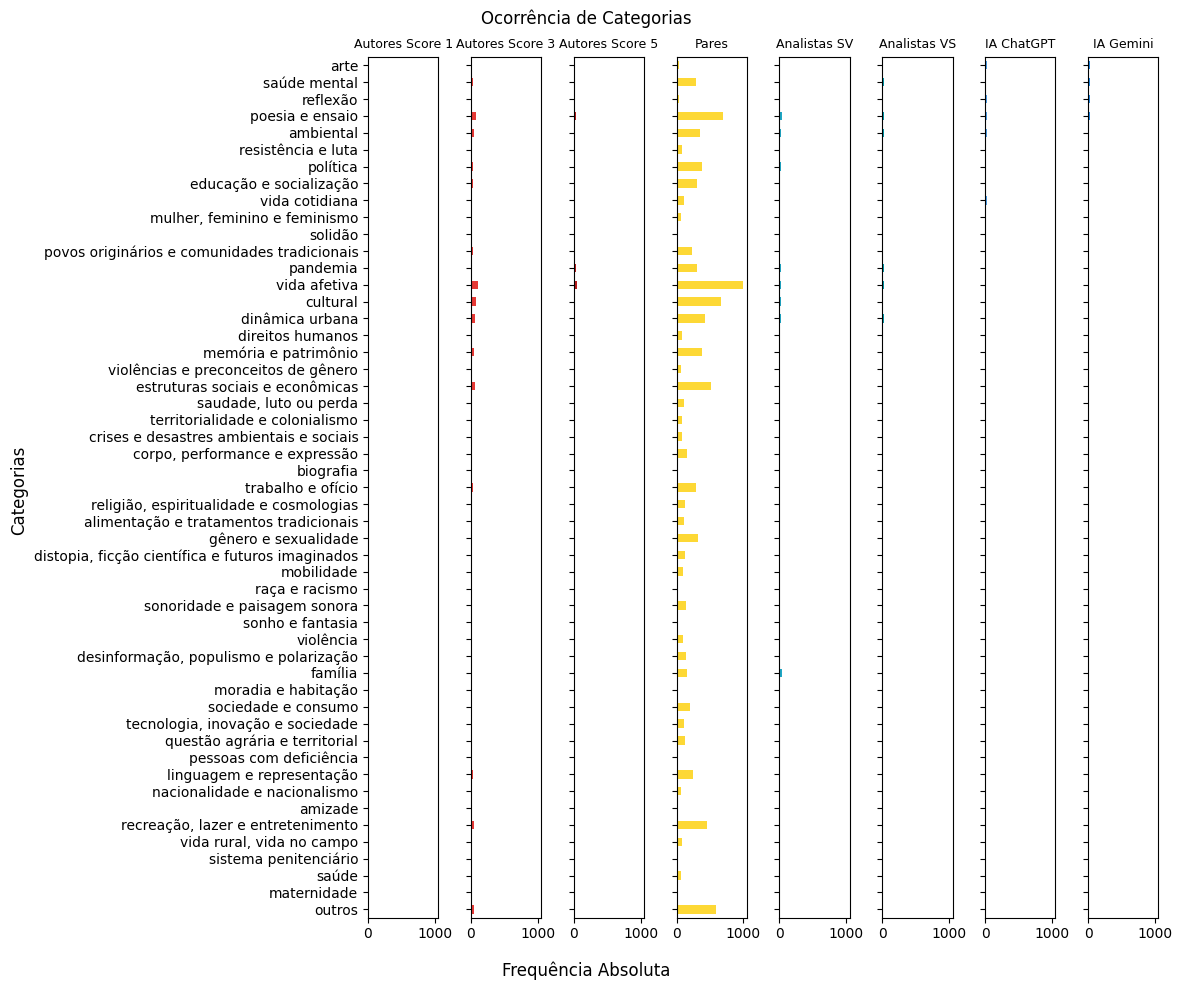

In [ ]:
fig, axes = plt.subplots(1,len(category_counts_agents.T.columns), sharey=True, sharex=True, figsize=(12,10))

category_counts_agents_sorted = category_counts_agents.T.sort_values(by='IA Gemini', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_agents_sorted.columns, axes.flat)):
    category_counts_agents_sorted[dimension].plot(kind='barh', ax = ax, color=colors_agents[idx])
    ax.set_ylabel('')
    ax.set_title(dimension, fontsize=9)
    
fig.suptitle('Ocorrência de Categorias')
fig.supxlabel('Frequência Absoluta')
fig.supylabel('Categorias')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_category_usage_frequency_agents.png', dpi = 300)
plt.show()

category_counts_sorted.to_excel(f'{results_dir}/meso_category_usage_frequency_agents.xlsx')

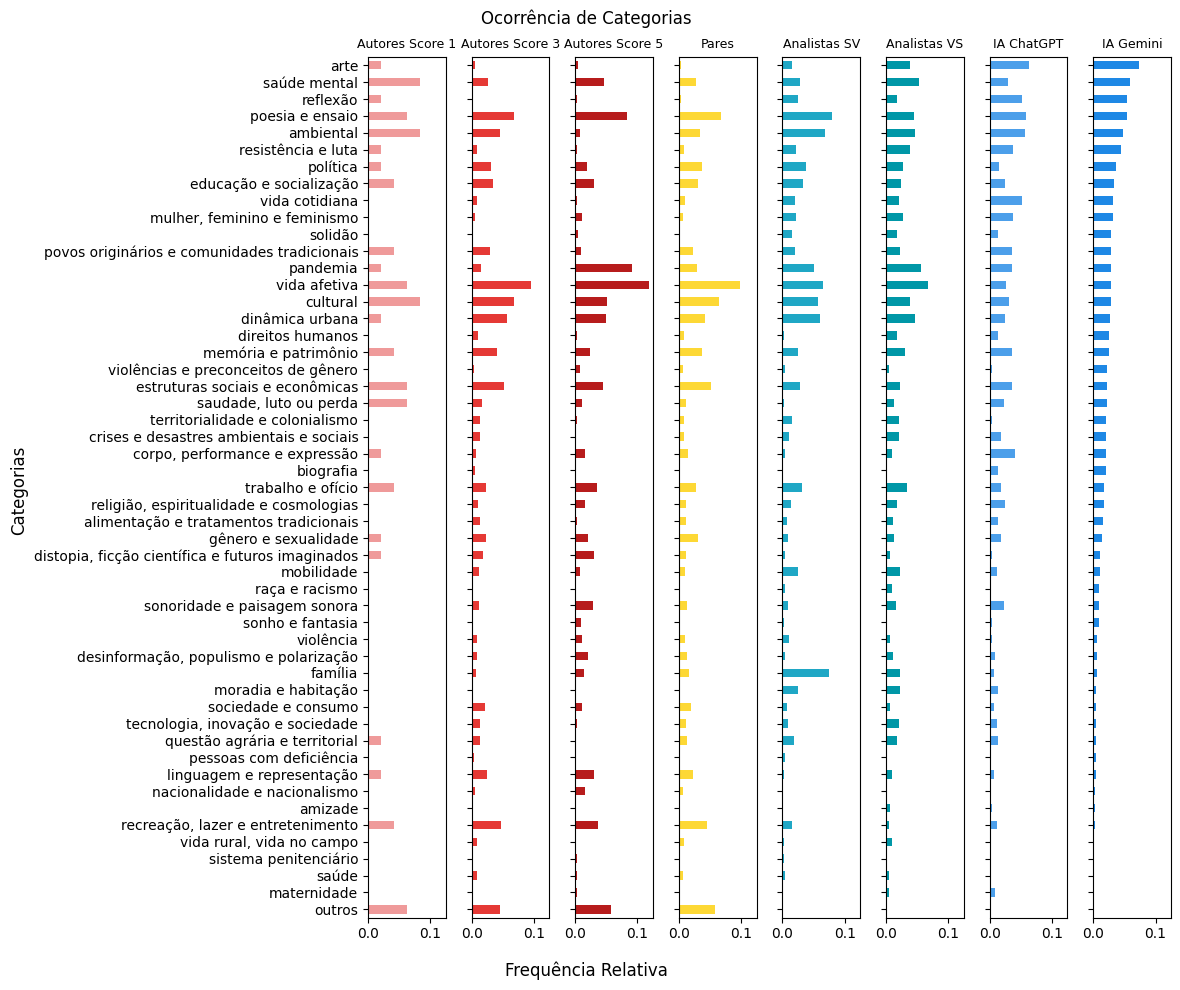

In [ ]:
category_counts_agents_normalized = category_counts_agents.div(category_counts_agents.sum(axis=1), axis = 0)

fig, axes = plt.subplots(1,len(category_counts_agents.T.columns), sharey=True, sharex=True, figsize=(12,10))

category_counts_agents_normalized_sorted = category_counts_agents_normalized.T.sort_values(by='IA Gemini', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_agents_normalized_sorted.columns, axes.flat)):
    category_counts_agents_normalized_sorted[dimension].plot(kind='barh', ax = ax, color=colors_agents[idx])
    ax.set_ylabel('')
    ax.set_title(dimension, fontsize=9)
    
fig.suptitle('Ocorrência de Categorias')
fig.supxlabel('Frequência Relativa')
fig.supylabel('Categorias')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_category_usage_frequency_relative_agents.png', dpi = 300)
plt.show()

category_counts_agents_normalized_sorted.to_excel(f'{results_dir}/meso_category_usage_frequency_relative_agents.xlsx')

In [ ]:
chi2, p, dof, expected = chi2_contingency(category_counts_agents)

expected = pd.DataFrame(
    expected,
    index=category_counts_agents.index,
    columns=category_counts_agents.columns,
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

residuals_agents = (category_counts_agents - expected) / np.sqrt(expected)

Chi-square statistic: 2197.246589193088
Degrees of freedom: 350
p-value: 1.7723568102149443e-264


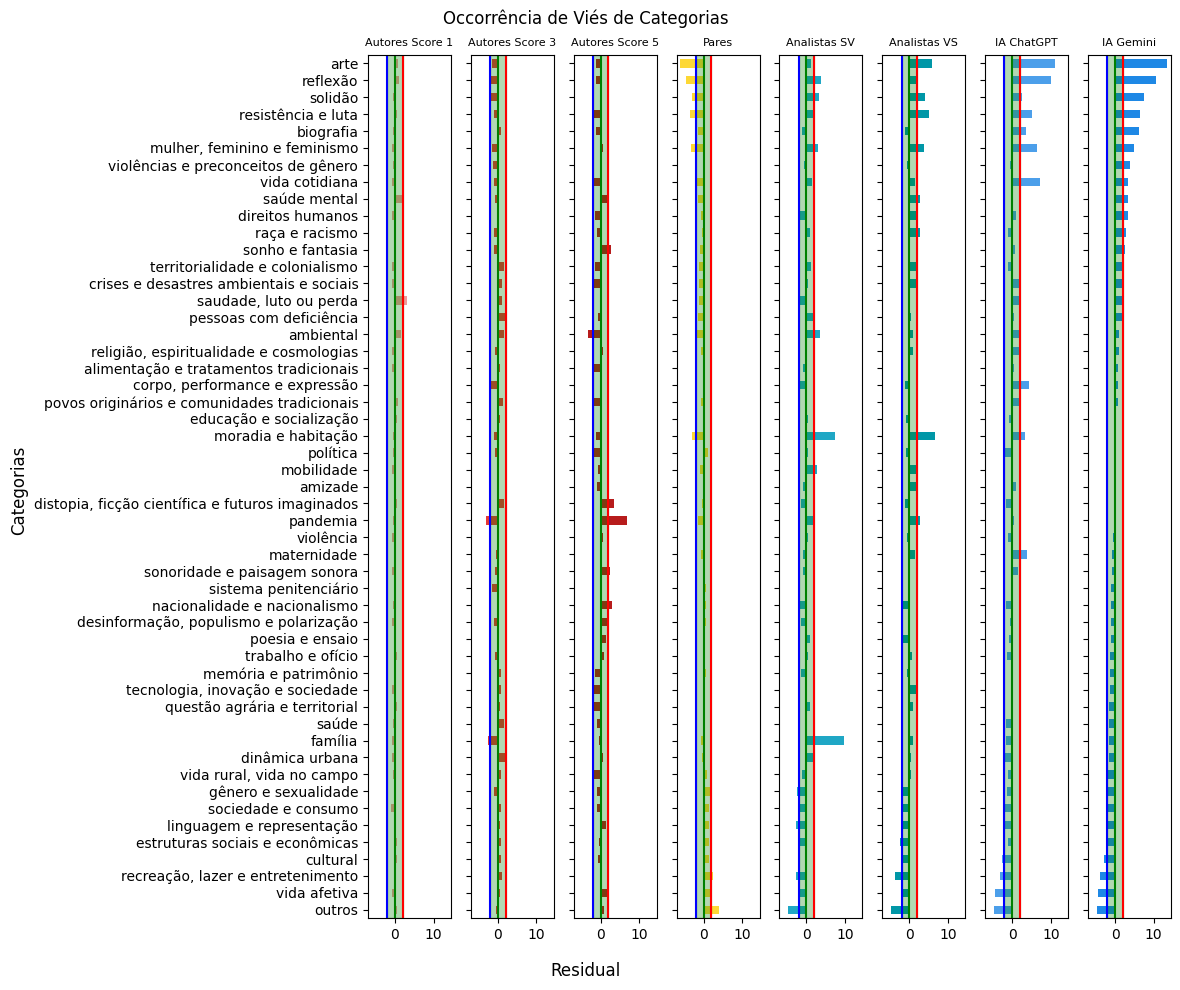

In [ ]:
residuals_agents_sorted = residuals_agents.T.sort_values(by='IA Gemini', na_position='first')

fig, axes = plt.subplots(1,len(residuals_agents_sorted.columns), sharex=True, sharey=True, figsize=(12,10))

for idx, (dimension, ax) in enumerate(zip(residuals_agents_sorted.columns, axes.flat)):

    residuals_agents_sorted[dimension].plot(kind='barh', ax = ax, color = colors_agents[idx])

    ax.axvline(0, color = 'green')
    ax.axvspan(-2,2, alpha = 0.3, color='green')
    ax.axvline(-2, color = 'blue', linewidth=1.5) #residuals_agents_sorted.min().min()
    ax.axvline(2, color = 'red', linewidth=1.5) #residuals_agents_sorted.max().max()

    ax.set_ylabel('')
    ax.set_title(dimension, fontsize=8)

fig.suptitle('Occorrência de Viés de Categorias')
fig.supxlabel('Residual')
fig.supylabel('Categorias')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_category_bias_agents.png', dpi = 300)
plt.show()

residuals_sorted.to_excel(f'{results_dir}/meso_category_bias_agents.xlsx')

### Entropia por filme

In [ ]:
df_all = pd.concat([df for df in dfs.values()], axis = 1)

df_entropy = utils.per_film_entropy(df_all)
df_entropy.set_index('film_id', inplace =True)
df_entropy.to_excel(f'{results_dir}/meso_entropy.xlsx')

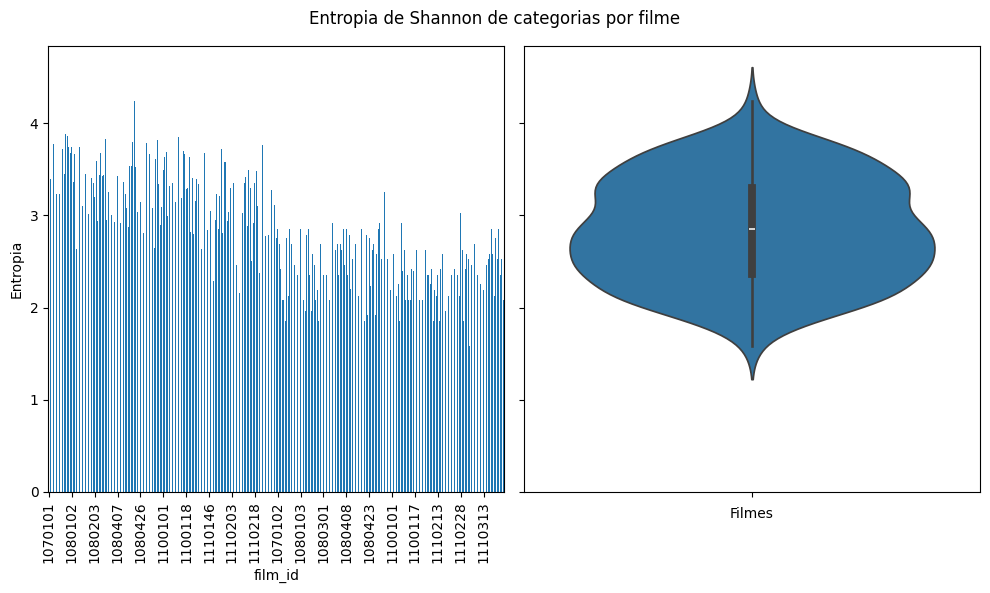

In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1,2, figsize = (10,6), sharey=True)

df_entropy['entropy'].plot(kind='bar', ax = ax[0])
sns.violinplot(data=df_entropy, y='entropy', ax = ax[1])
ax[0].xaxis.set_major_locator(MaxNLocator(nbins=20))
ax[0].set_ylabel('Entropia')
ax[1].set_xlabel('Filmes')
fig.suptitle('Entropia de Shannon de categorias por filme')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_per_film_entropy.png', dpi = 300)
plt.show()

In [ ]:
df_entropy.to_csv(f'{results_dir}/meso_entropy.csv')

### Entropia por filme em comparação com nível micro

C:\Users\User01\AppData\Local\Temp\ipykernel_23444\4089834852.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


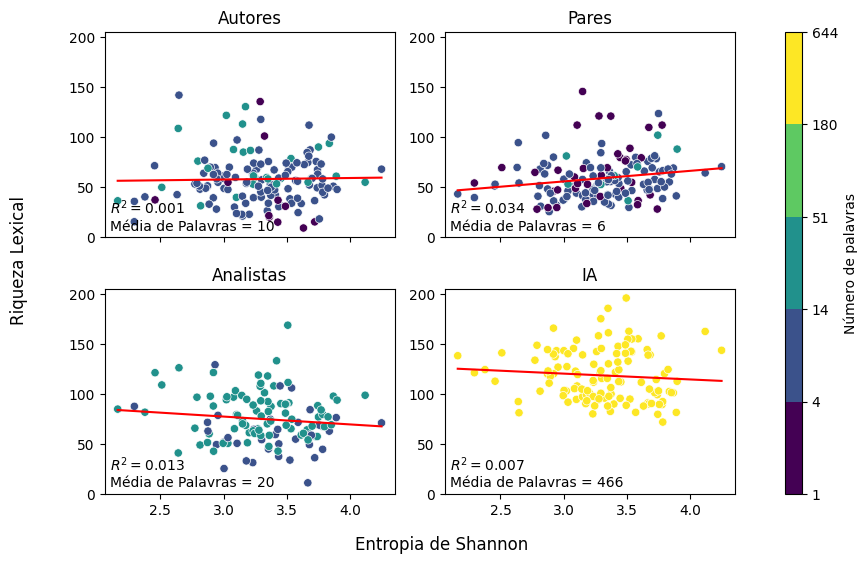

C:\Users\User01\AppData\Local\Temp\ipykernel_23444\4089834852.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


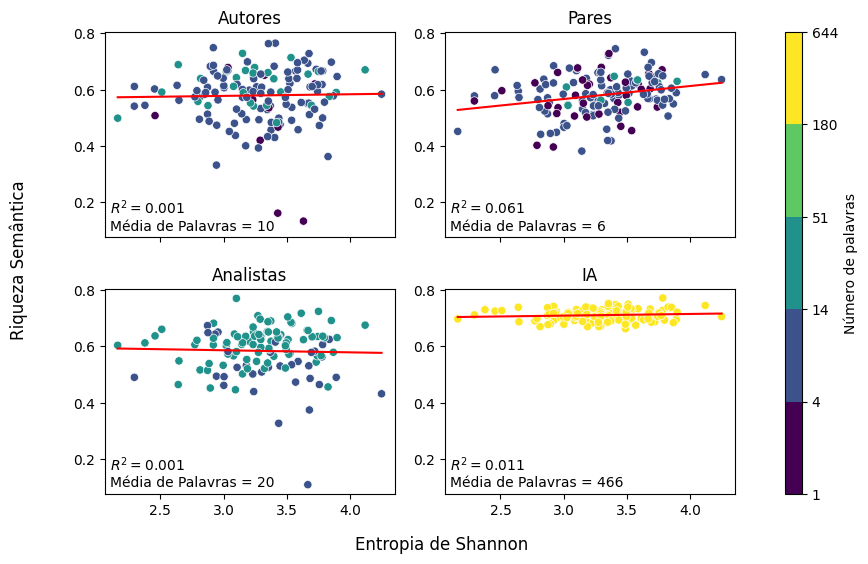

In [ ]:
importlib.reload(utils)

labels =[1,2,3,4,5]

for richness in ['lexical_richness', 'semantic_richness']:
    if richness == 'lexical_richness':
        label = 'Riqueza Lexical'
    else:
        label = 'Riqueza Semântica'

    fig = plt.figure(figsize=(9, 6))

    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.06], height_ratios = [1,1], hspace=0.25, wspace=0.25)

    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[0,1], sharex=ax1, sharey=ax1)
    ax3 = fig.add_subplot(gs[1,0], sharex=ax1, sharey=ax1)
    ax4 = fig.add_subplot(gs[1,1], sharex=ax1, sharey=ax1)

    ax1.tick_params(labelbottom=False)
    ax2.tick_params(labelbottom=False)

    axes = [ax1,ax2,ax3,ax4]

    df = df_micro_richness.xs(richness, level=0, axis = 1)

    for dimension, ax in zip(df.columns, axes):

        #df_merge = pd.merge(df_entropy['entropy'], df[dimension], on = 'film_id')
        
        df_merge = pd.concat([df_entropy['entropy'], df[dimension], df_bins[f'{dimension}_N']], axis = 1)

        df_merge.rename(columns={dimension : label}, inplace=True)
        mean_word_count = df_word_counts[f'{dimension}_N'].mean()
        
        sns.scatterplot(data=df_merge, 
                        x='entropy', 
                        y=label, 
                        hue=f'{dimension}_color',
                        hue_order=labels,
                        palette=palette, 
                        legend=False,
                        ax = ax)
        
        ax.set_title(dimension)
        ax.set_xlabel('')
        ax.set_ylabel('')

        x_range, y_pred, r2 = utils.get_fitted(df_merge, 'entropy', label)

        ax.plot(x_range, y_pred, color='red')

        locs = 0.95 if richness == 'lexical_richess' else 0.02

        ax.text(
                0.02, locs,
                f"$R^2 = {r2:.3f}$\nMédia de Palavras = {mean_word_count:.0f}",
                transform=ax.transAxes,
                fontsize=10,
                va='bottom',
                ha='left'
            )
    
    cax = fig.add_subplot(gs[:, 2])

    sm = ScalarMappable(norm=norm_word, cmap=cmap_word)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)

    # Ticks at the bin edges, label nicely
    cbar.set_ticks(bins)
    cbar.set_ticklabels([f"{b:.0f}" for b in bins])
    cbar.set_label("Número de palavras")

    fig.supylabel(label)
    fig.supxlabel('Entropia de Shannon')
    fig.tight_layout()
    fig.savefig(f'{results_dir}/{richness}_micro_vs_meso.png', dpi = 300)
    plt.show()


### Comparação entre riqueza de texto e meso

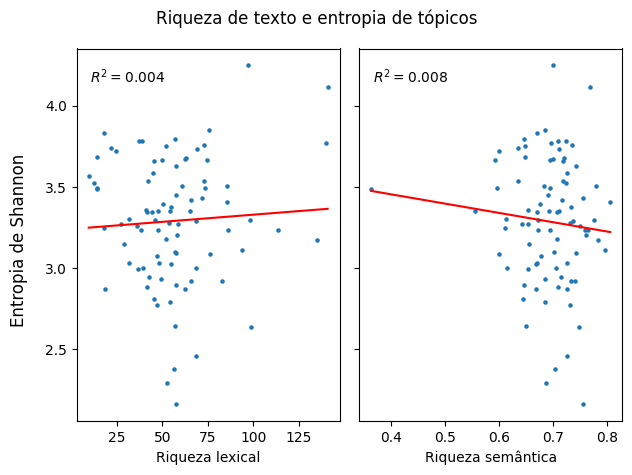

In [ ]:
fig, axes = plt.subplots(1,2, sharey=True)

for ax, richness in zip(axes, ['lexical_richness', 'semantic_richness']):
    df = pd.concat([df_entropy, df_transcripts[richness]], axis = 1)
    
    if richness == 'lexical_richness':
        label = 'Riqueza lexical'
    else:
        label = 'Riqueza semântica'
  
    ax.scatter(df[richness], df['entropy'], s = 5)
    ax.set_xlabel(label)

    
    x_range, y_pred, r2 = utils.get_fitted(df, richness, 'entropy')

    ax.plot(x_range, y_pred, color='red')
    ax.text(
            0.05, 0.95,
            f"$R^2 = {r2:.3f}$",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top'
        )

fig.suptitle('Riqueza de texto e entropia de tópicos')
fig.supylabel('Entropia de Shannon')
fig.tight_layout()
fig.savefig(f'{results_dir}/meso_richness.png', dpi = 300)
plt.show()

### Visualizações de relações entre tópicos

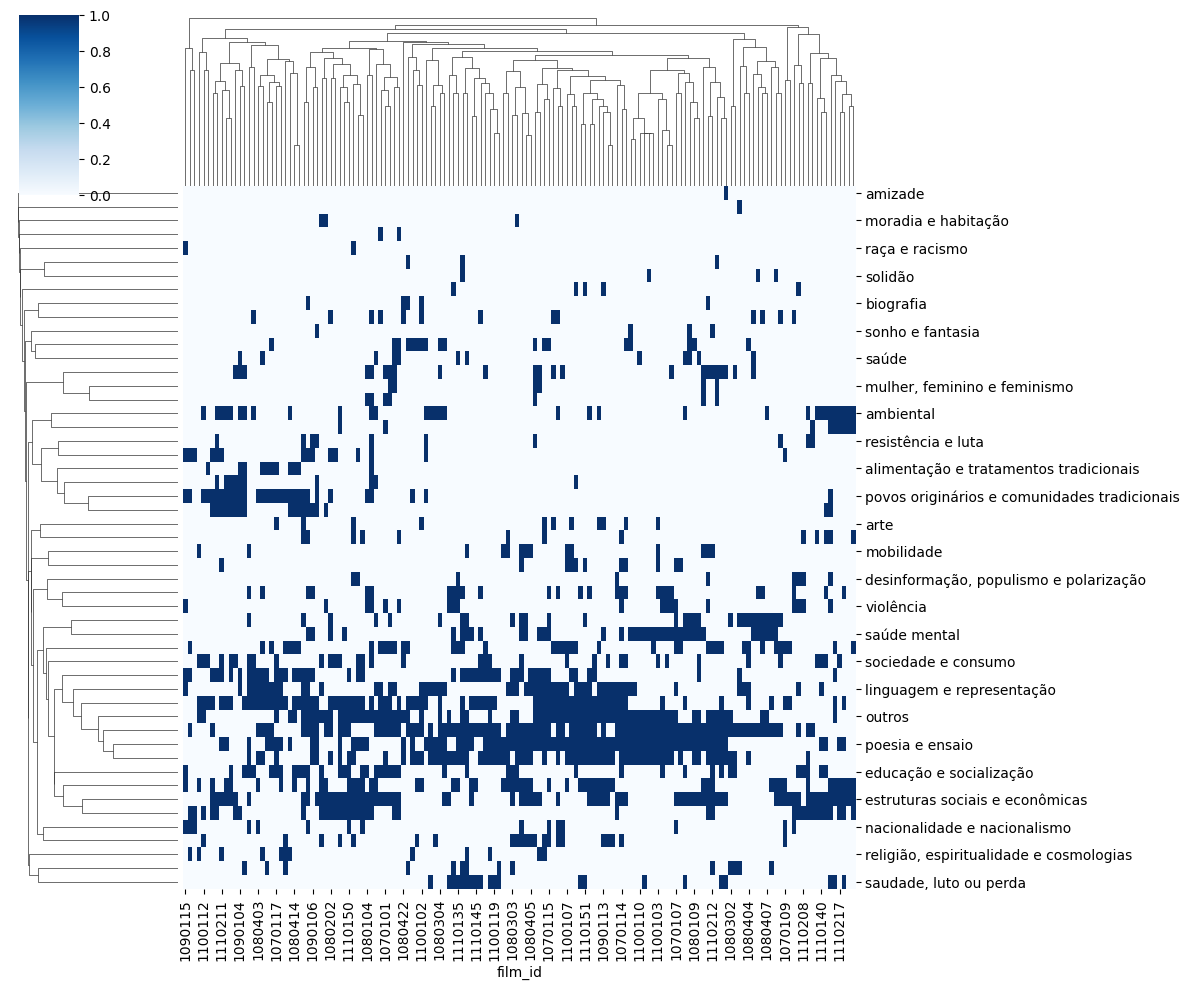

                                               topic  cluster
17                                       maternidade        1
40                                           solidão        1
43                  tecnologia, inovação e sociedade        2
4                                          biografia        2
41                                  sonho e fantasia        3
36                                             saúde        3
5                     corpo, performance e expressão        3
0             alimentação e tratamentos tradicionais        4
12                           educação e socialização        4
9                                    dinâmica urbana        4
10                                  direitos humanos        4
11  distopia, ficção científica e futuros imaginados        4
6            crises e desastres ambientais e sociais        4
3                                               arte        4
7                                           cultural        4
1       

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


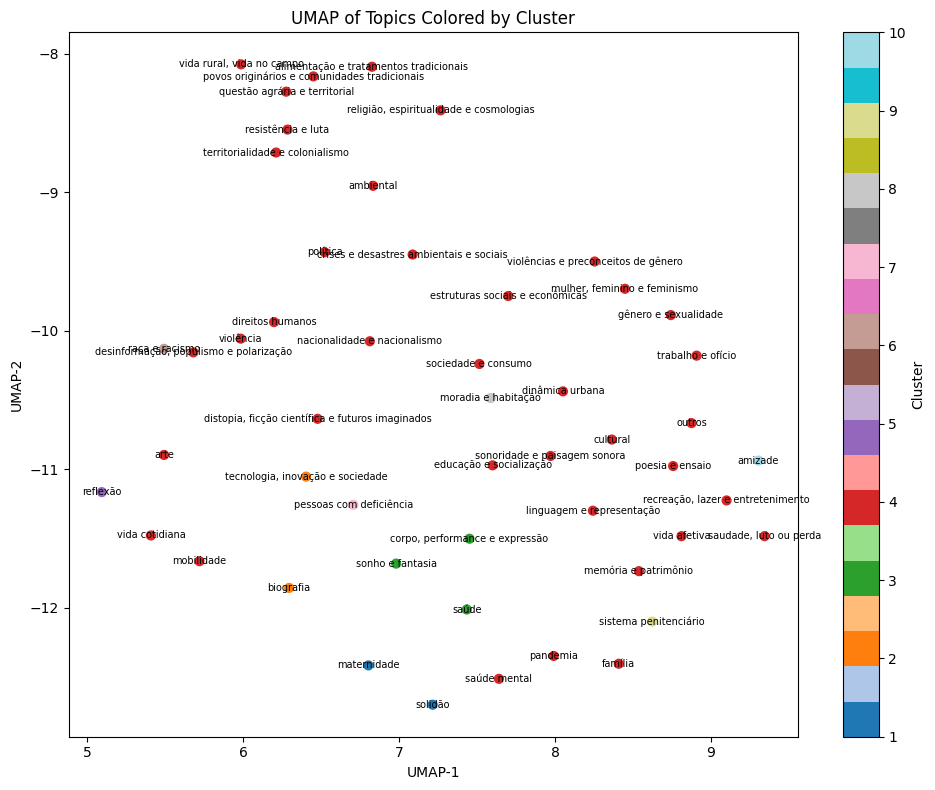

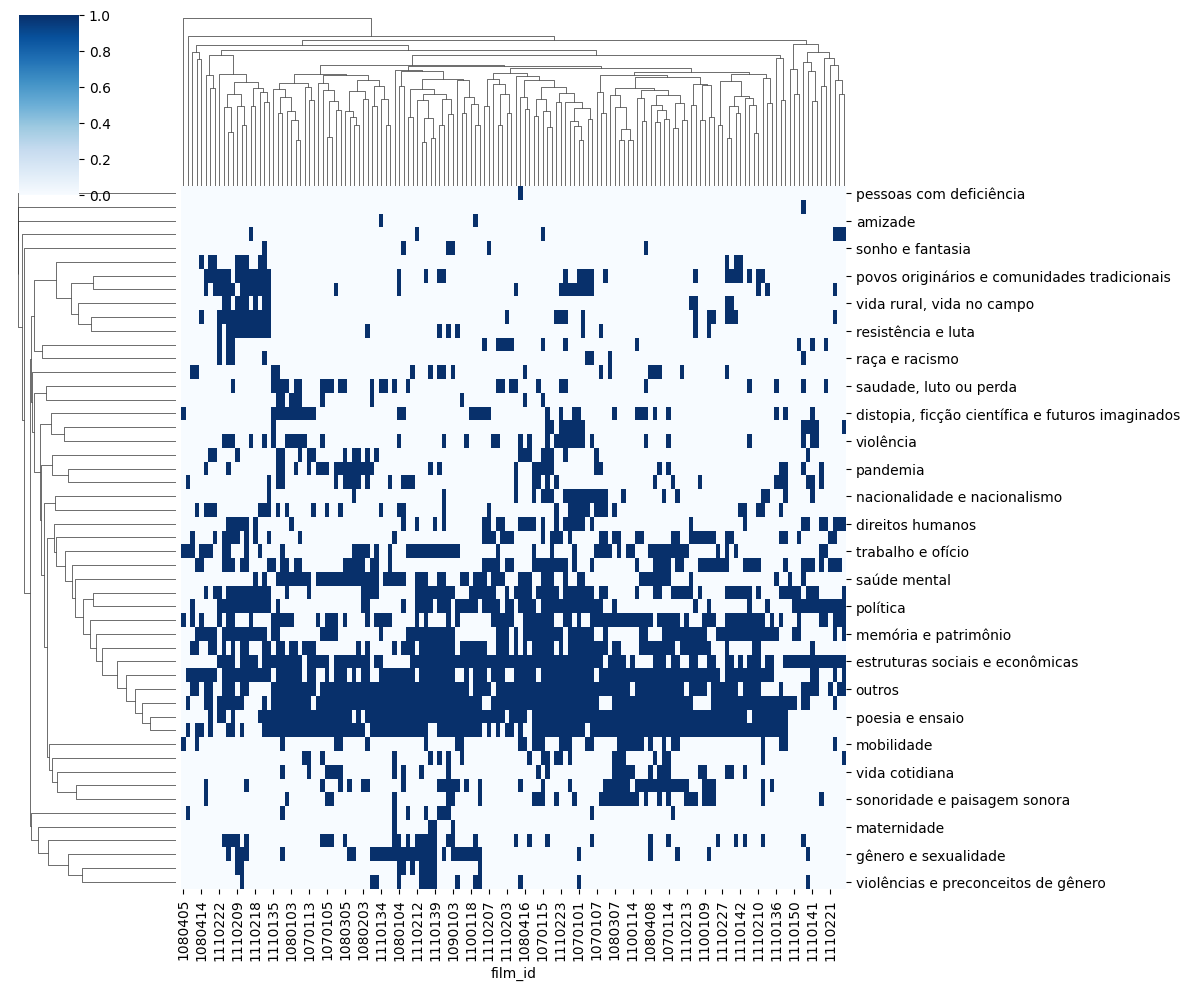

                                               topic  cluster
0             alimentação e tratamentos tradicionais        1
6            crises e desastres ambientais e sociais        1
28      povos originários e comunidades tradicionais        1
30                                    raça e racismo        1
29                     questão agrária e territorial        1
48                         vida rural, vida no campo        1
44                   territorialidade e colonialismo        1
34                                resistência e luta        1
12                           educação e socialização        2
13                   estruturas sociais e econômicas        2
11  distopia, ficção científica e futuros imaginados        2
22                      nacionalidade e nacionalismo        2
16                         linguagem e representação        2
7                                           cultural        2
5                     corpo, performance e expressão        2
1       

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


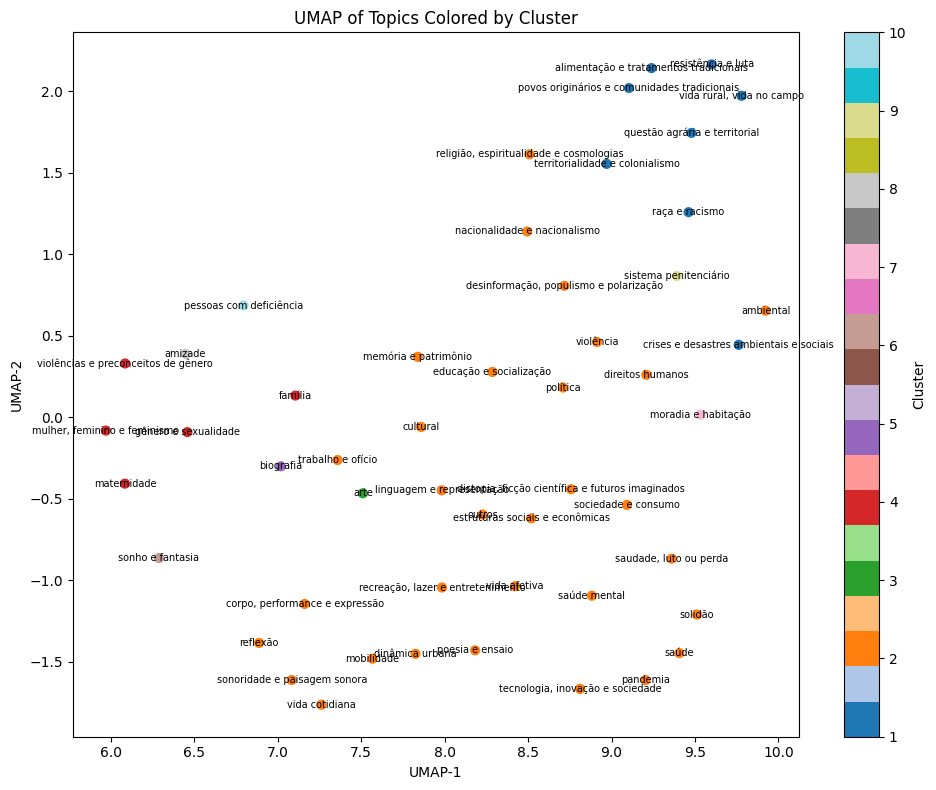

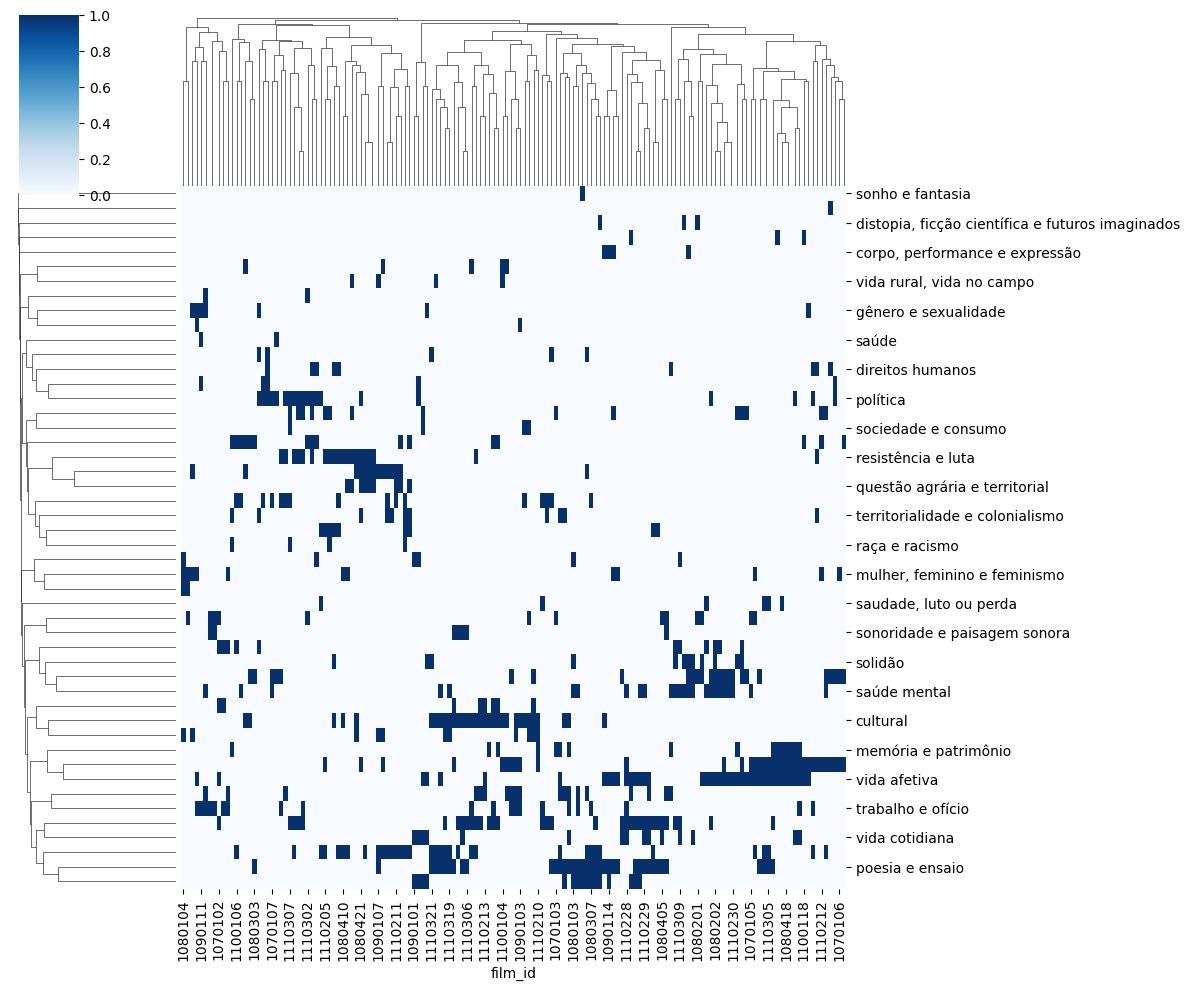

                                               topic  cluster
0             alimentação e tratamentos tradicionais        1
45                         vida rural, vida no campo        1
22                           pessoas com deficiência        2
14                              gênero e sexualidade        2
16                                       maternidade        2
11                           educação e socialização        3
7             desinformação, populismo e polarização        3
12                   estruturas sociais e econômicas        3
24                                          política        3
25      povos originários e comunidades tradicionais        3
26                     questão agrária e territorial        3
27                                    raça e racismo        3
31                                resistência e luta        3
19                               moradia e habitação        3
9                                   direitos humanos        3
5       

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


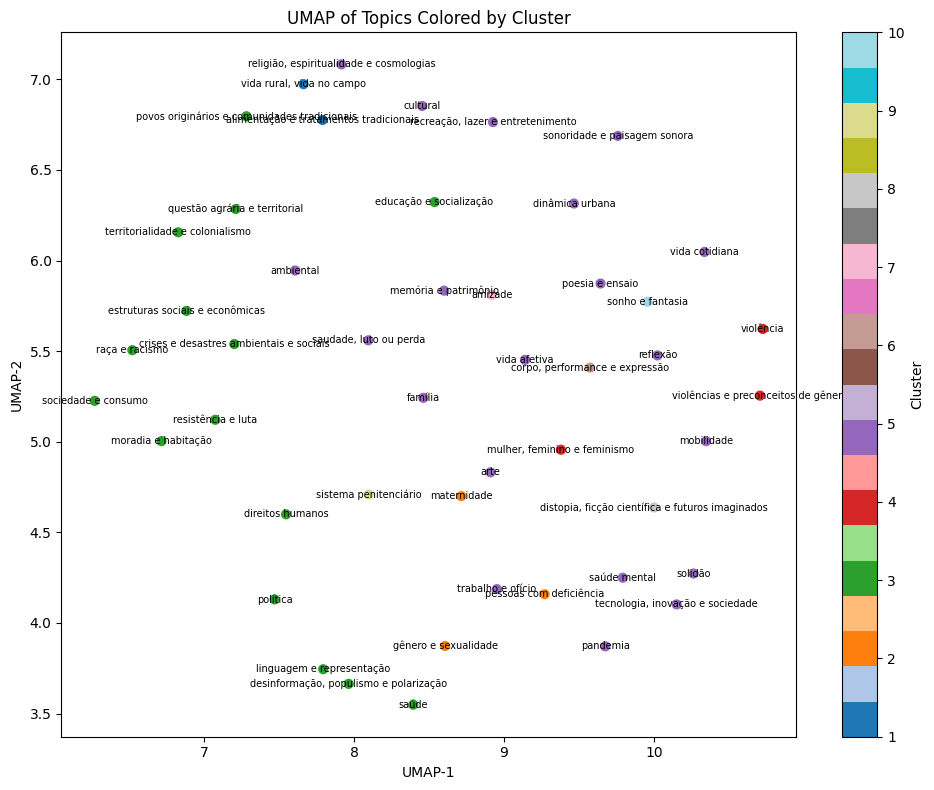

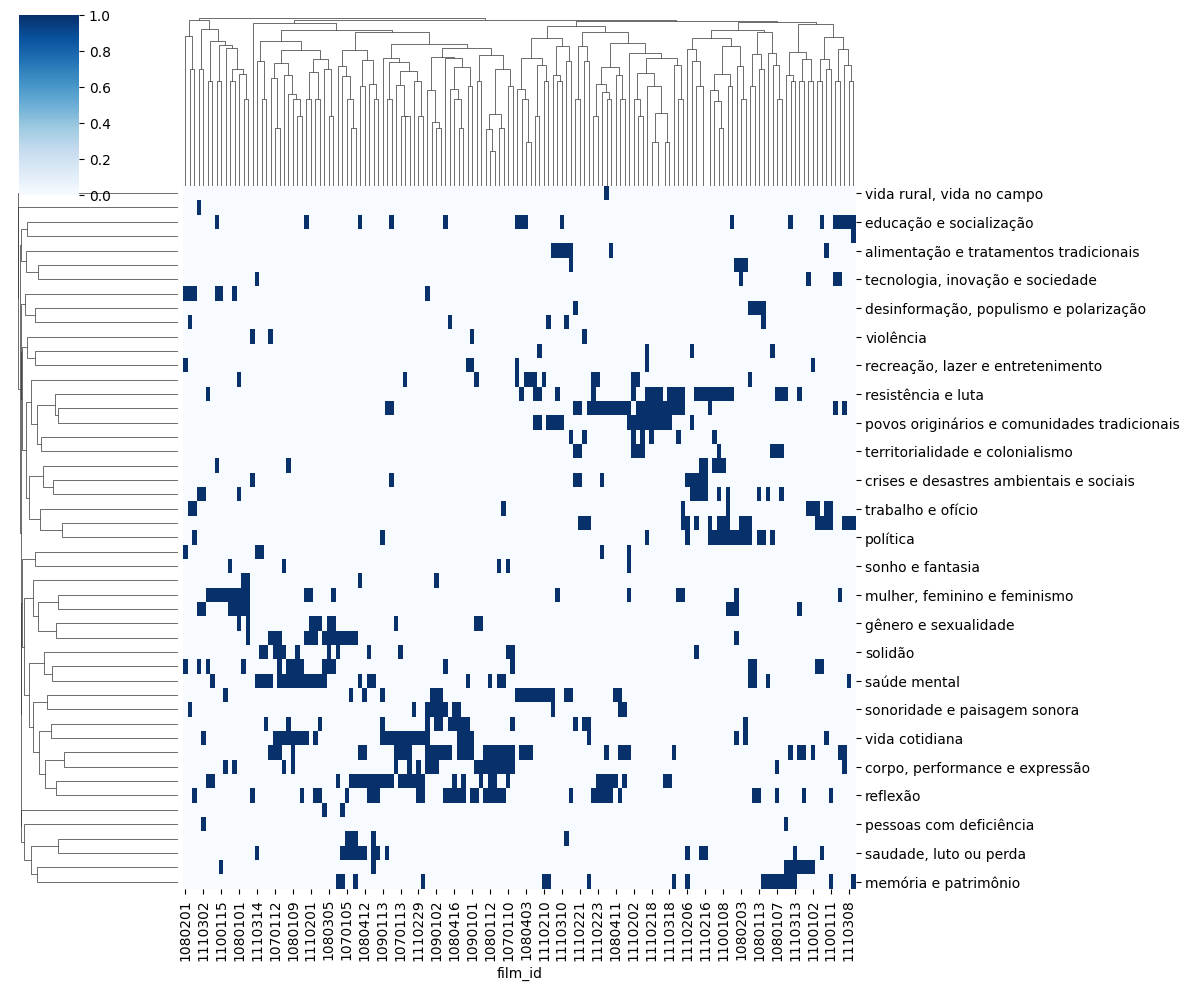

                                               topic  cluster
12                           educação e socialização        1
22                      nacionalidade e nacionalismo        1
0             alimentação e tratamentos tradicionais        2
37                               sociedade e consumo        2
41                  tecnologia, inovação e sociedade        2
19                                        mobilidade        3
16                         linguagem e representação        3
8             desinformação, populismo e polarização        3
27      povos originários e comunidades tradicionais        4
26                                          política        4
29                                    raça e racismo        4
28                     questão agrária e territorial        4
20                               moradia e habitação        4
13                   estruturas sociais e econômicas        4
10                                  direitos humanos        4
1       

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


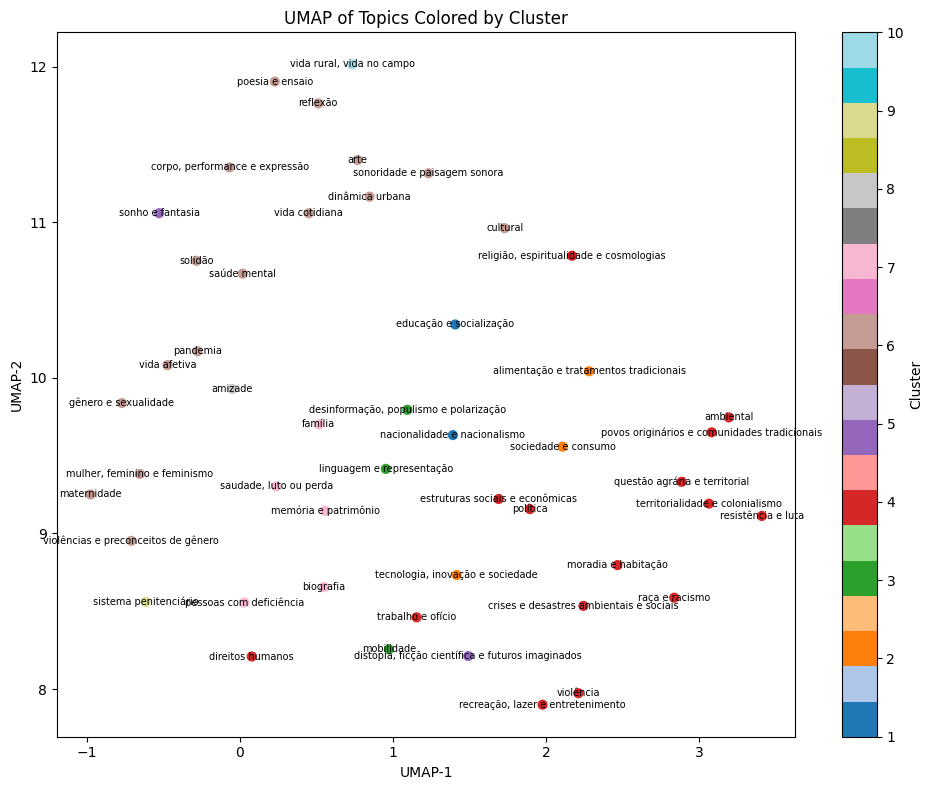

In [ ]:
importlib.reload(utils)

for df in dfs.values():

    utils.get_topic_visualizations(df)

## MCA

In [ ]:
top_categories = pd.read_excel(f'{root_dir}/Dados Integrados/v4-NOVO-TabelaSimples de Temas por Filmes e Agentes.xlsx', sheet_name=['An-Analistas Ambos', 'Au-Autores1a5', 'Pa-Pares', 'IA-IAs'])

In [ ]:
# df = top_categories['An-Analistas Ambos'][['ID Filme', 'Nome Filme']].copy()
# df['film_id'] = df['ID Filme'].astype(str)
# df['title'] = df['Nome Filme']
# df_titles = df[['film_id','title']]

In [ ]:
dimension_map = {'An-Analistas Ambos' : 'Analistas',
                 'Au-Autores1a5' : 'Autores',
                 'Pa-Pares' : 'Pares',
                 'IA-IAs' : 'IA'}

dfs_categories = {}

for dimension, _df in top_categories.items():
    df = _df.copy()
    df['film_id'] = df['ID Filme']
    df.set_index('film_id', inplace=True)
    df['category'] = df['Categoria-Tema'].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()
    dfs_categories[dimension_map[dimension]] = df[['category']]

In [ ]:
import prince
import plotly.graph_objects as go
import plotly.express as px
import hdbscan

def get_mca(X, label, df_titles, file_name, n_components = 10):

    mca = prince.MCA(n_components=n_components,
                    n_iter=10,
                    copy=True,
                    check_input=True,
                    engine='sklearn',
                    random_state=42
                    )

    mca.fit(X)

    #X.index = X.index.astype(int)

    # Row coordinates (films)
    X_rows = mca.row_coordinates(X)
    X_rows.columns = [f'Dim{n}' for n in range(1,n_components+1)]
    X_rows['film_id'] = X.index.astype(int)

    df_title = pd.merge(X, df_titles, on='film_id')[['film_id','title']]
    df_title['title'] = df_title['film_id'].astype(str) + ' - ' + df_title['title']
    df_title.set_index('film_id', inplace=True)
    X_rows['title'] = df_title['title']

    # Column coordinates (categories / modalities)
    X_cols = mca.column_coordinates(X)
    X_cols.columns = [f'Dim{n}' for n in range(1,n_components+1)]
    X_cols['modality'] = X_cols.index

    # Optionally, variance explained
    eigvals = mca.eigenvalues_
    expl_var = eigvals / eigvals.sum()
    dim1_pct = round(expl_var[0] * 100, 1)
    dim2_pct = round(expl_var[1] * 100, 1)

    X_for_cluster = X_rows[[f'Dim{n}' for n in range(1,n_components+1)]].values

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=2,   # tune for your data
        min_samples=None,      # default = min_cluster_size
        metric='euclidean'
    )

    film_labels = clusterer.fit_predict(X_for_cluster)
    X_rows['cluster'] = film_labels

    X_cols_for_cluster = X_cols[[f'Dim{n}' for n in range(1,n_components+1)]].values

    clusterer_cat = hdbscan.HDBSCAN(
        min_cluster_size=2,    # typically smaller, fewer modalities
        metric='euclidean'
    )

    cat_labels = clusterer_cat.fit_predict(X_cols_for_cluster)
    X_cols['cluster'] = cat_labels

    # ---- Build color map for film clusters ----
    film_clusters = X_rows['cluster'].astype(int).unique()
    film_clusters_sorted = sorted(film_clusters)

    # Use a qualitative palette and cycle if needed
    palette = px.colors.qualitative.Safe
    color_map = {cl: palette[i % len(palette)] for i, cl in enumerate(film_clusters_sorted)}

    # Optional: special color for noise (-1)
    if -1 in color_map:
        color_map[-1] = "#272525"  # light grey for noise

    film_colors = X_rows['cluster'].astype(int).map(color_map)

    # ---- Category colors (if you clustered modalities too) ----
    if 'cluster' in X_cols.columns:
        cat_clusters = X_cols['cluster'].astype(int).unique()
        # Reuse the same palette mapping by cluster id
        cat_colors = X_cols['cluster'].astype(int).map(color_map)
    else:
        # If you did not cluster categories, keep them all in one neutral color
        cat_colors = "#FF7F0E"  # orange

    plt.plot(range(1, len(eigvals)+1), expl_var, marker='o')
    plt.xlabel("Dimension")
    plt.ylabel("Explained inertia")
    plt.title("MCA Scree Plot")
    plt.show()

    col_coords = mca.column_coordinates(X)
    col_contrib = (col_coords**2).div(col_coords**2).sum(axis=1)
    print(col_contrib.unique())

    # --- Films (individuals) ---
    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=X_rows['Dim1'],
            y=X_rows['Dim2'],
            mode='markers',
            name='Filmes',
            hovertext=X_rows['title'],
            hoverinfo='text+x+y',
            marker=dict(symbol='circle', size=12, opacity=0.8, color=film_colors)
        )
    )

    # --- Modalities (categories) ---
    fig.add_trace(
        go.Scatter(
            x=X_cols['Dim1'],
            y=X_cols['Dim2'],
            mode='markers',
            name='Categorias',
            text=X_cols['modality'],
            textposition='top center',
            hovertext=X_cols['modality'],
            hoverinfo='text+x+y',
            marker=dict(symbol='diamond', size=8, opacity=0.6, color = cat_colors)
        )
    )

    fig.update_layout(
        title=f"ACM {label}",
        title_x = 0.5,
        xaxis_title=f"Dimensão 1 ({dim1_pct}%)",
        yaxis_title=f"Dimensão 2 ({dim2_pct}%)",
        template="plotly_white",
        width=900,
        height=700,
        legend=dict(x=0.01, y=0.99)
    )

    #fig.update_xaxes(type="log")
    #fig.update_yaxes(type="log")

    fig.write_html(f"{results_dir}/mca_{label}_{file_name}.html", include_plotlyjs="cdn")
    fig.show()

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


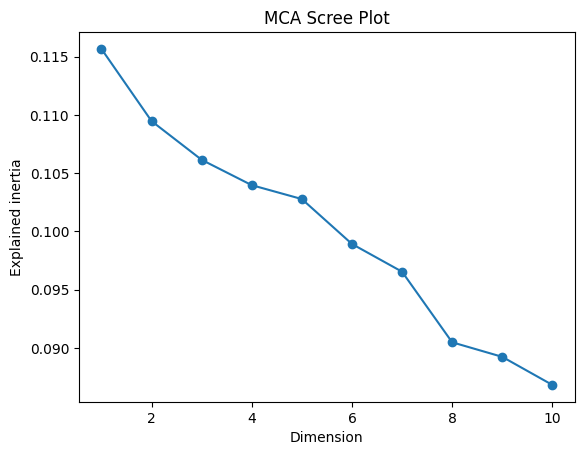

[10.]


c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



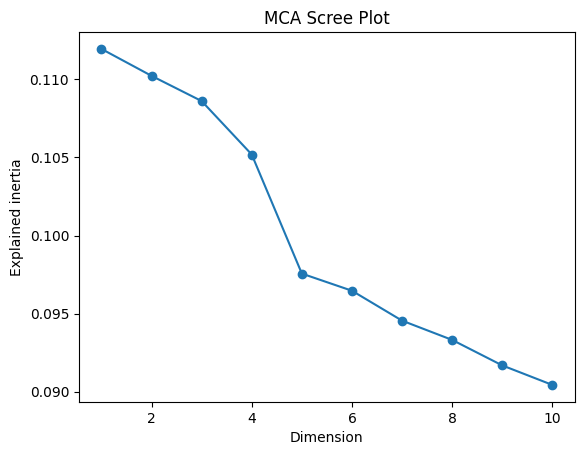

[10.]


c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



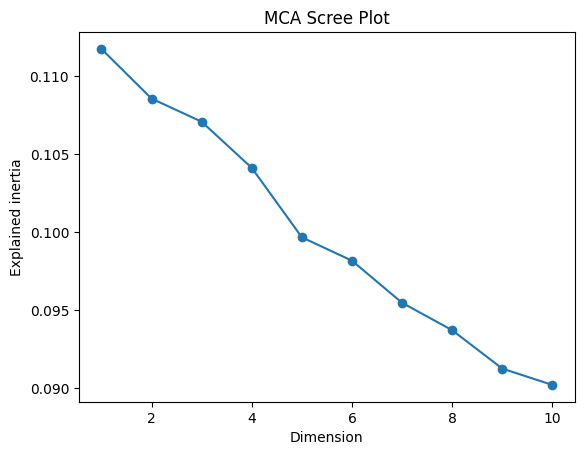

[10.]


c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



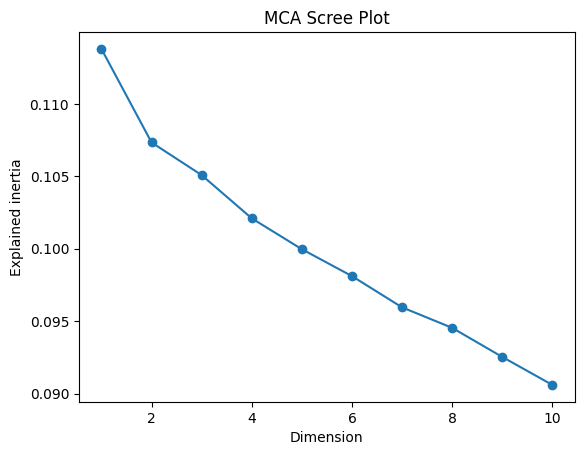

[10.]


In [ ]:
for dimension, _df in dfs.items():
    df = _df.copy()
    #df = df.xs('Tema 0', level=-1, axis = 1)
    df.columns = df.columns.map(lambda tup: "_".join(map(str, tup)))

    for col in df.columns:
        df[col] = df[col].astype('category')

    df.index = df.index.astype(int)

    get_mca(df, dimension, df_titles, 'test')
    

    



In [ ]:
_dfs_prep_mca = dfs_meso_agents.copy()

_df = _dfs_prep_mca['Autores'].copy()
_df.columns = pd.MultiIndex.from_tuples([
        (f"{l0}_{l1}_{l2}", l3) for l0, l1, l2, l3 in _df.columns], names=["rater", _df.columns.names[3]])

_dfs_prep_mca['Autores'] = _df

_df = _dfs_prep_mca['Pares'].copy()
_df.columns = pd.MultiIndex.from_tuples([
        (f"{l0}_{l1}", l2) for l0, l1, l2 in _df.columns], names=["rater", _df.columns.names[2]])

_dfs_prep_mca['Pares'] = _df

dfs_prep_mca = pd.concat({k:v for k,v in _dfs_prep_mca.items()}, axis = 1)
dfs_prep_mca

Autores                                           \
rater                    SV_1_1                                   SV_3_1   
level                    Tema 0           Tema 2  Tema 3          Tema 0   
film_id                                                                    
1070101                     NaN              NaN     NaN             NaN   
1070102                     NaN              NaN     NaN  vida cotidiana   
1070103                     NaN              NaN     NaN             NaN   
1070105  saudade, luto ou perda  poesia e ensaio  outros             NaN   
1070106                     NaN              NaN     NaN             NaN   
...                         ...              ...     ...             ...   
1110322                     NaN              NaN     NaN             NaN   
1110323                     NaN              NaN     NaN             NaN   
1110324                     NaN              NaN     NaN             NaN   
1110325                     NaN              NaN     NaN             NaN   
1110326                     NaN              NaN     NaN             NaN   

                                                                       ...  \
rater                                     SV_3_2               SV_3_3  ...   
level             Tema 2           Tema 3 Tema 0 Tema 2 Tema 3 Tema 0  ...   
film_id                                                                ...   
1070101              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1070102  dinâmica urbana  poesia e ensaio    NaN    NaN    NaN    NaN  ...   
1070103              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1070105              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1070106              NaN              NaN    NaN    NaN    NaN    NaN  ...   
...                  ...              ...    ...    ...    ...    ...  ...   
1110322              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1110323              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1110324              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1110325              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1110326              NaN              NaN    NaN    NaN    NaN    NaN  ...   

                       Analistas                                          \
rater                         SV                                      VS   
level                     Tema 3                                  Tema 0   
film_id                                                                    
1070101                      NaN                                     NaN   
1070102                      NaN                                     NaN   
1070103                      NaN                                     NaN   
1070105                      NaN                                     NaN   
1070106                      NaN                                     NaN   
...                          ...                                     ...   
1110322                  família  alimentação e tratamentos tradicionais   
1110323                     arte                      resistência e luta   
1110324           vida cotidiana                               violência   
1110325  pessoas com deficiência                            saúde mental   
1110326         direitos humanos  desinformação, populismo e polarização   

                                                 \
rater                                             
level                                    Tema 2   
film_id                                           
1070101                                     NaN   
1070102                                     NaN   
1070103                                     NaN   
1070105                                     NaN   
1070106                                     NaN   
...                                         ...   
1110322                                cultural   
1110323   

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



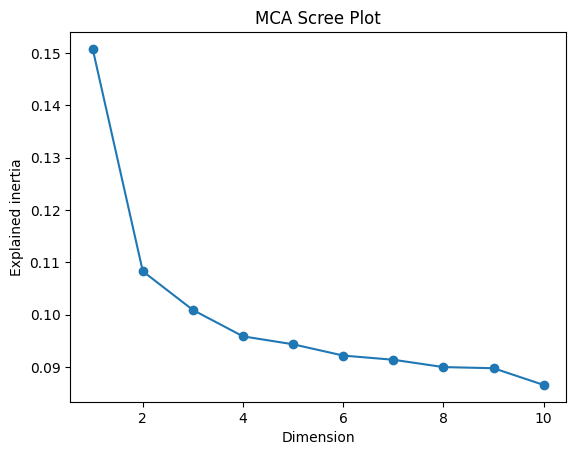

[10.]


In [ ]:
df_all = pd.concat([df.copy() for df in dfs.values()], axis = 1)

df_all.columns = df_all.columns.map(lambda tup: "_".join(map(str, tup)))


for col in df_all.columns:
    df_all[col] = df_all[col].astype('category')

get_mca(df_all, 'all', df_titles, 'test_all')

## Valores Identitários

In [ ]:
df_identities = pd.read_excel(f'{root_dir}/Dados Identidades/Dados de Input Identidades/PAID_01_DadosParticipantes_Identidade.xlsx')

In [ ]:
df_identities['film_id'] = df_identities['ID_OfGrPart'].str.split("-", n=1).str[0].str.strip().astype(int)
df_identities['rater_id'] = df_identities['ID_OfGrPart'].str.split("-", n=1).str[1].str.strip().astype(str)

df_identities = df_identities.set_index('ID_OfGrPart')

In [ ]:
df_identities = df_identities[df_identities['film_id'] > 1069000]

In [ ]:
df_themes_list = []

for theme in column_themes:
    
    df_theme = df_authors_meso_wide.xs(theme, axis = 1, level=-1)

    majority_theme = df_theme.apply(
    lambda r: r.mode(dropna=True).iloc[0] if not r.mode(dropna=True).empty else np.nan,
    axis=1)

    majority_theme.name = theme

    df_themes_list.append(majority_theme)

df_themes = pd.concat(df_themes_list, axis = 1)

In [ ]:
df_themes_list = []

for theme in column_themes:

    df_theme = df_authors_meso_wide.xs(theme, axis = 1, level = -1)

    list_themes = df_theme.apply(lambda row : row.dropna().unique(), axis = 1)

    list_themes.name = theme

    df_themes_list.append(list_themes)

df_themes = pd.concat(df_themes_list, axis = 1)
df_themes

,Tema 0,Tema 2,Tema 3
film_id,,,
1070101,"[violências e preconceitos de gênero, gênero e...","[gênero e sexualidade, violências e preconceit...","[estruturas sociais e econômicas, violências e..."
1070102,"[vida cotidiana, dinâmica urbana, vida afetiva...","[dinâmica urbana, poesia e ensaio, pandemia, s...","[poesia e ensaio, mobilidade, vida afetiva, re..."
1070103,"[poesia e ensaio, arte, sonoridade e paisagem ...","[saúde mental, vida afetiva, poesia e ensaio, ...","[outros, direitos humanos, cultural, vida afet..."
1070105,"[saudade, luto ou perda, memória e patrimônio,...","[poesia e ensaio, memória e patrimônio, famíli...","[outros, vida afetiva, poesia e ensaio, cultur..."
1070106,"[mulher, feminino e feminismo, educação e soci...","[gênero e sexualidade, estruturas sociais e ec...","[trabalho e ofício, educação e socialização, v..."
...,...,...,...
1110226,"[cultural, dinâmica urbana, estruturas sociais...","[dinâmica urbana, linguagem e representação, a...","[poesia e ensaio, estruturas sociais e econômi..."
1110227,"[poesia e ensaio, memória e patrimônio, vida a...","[vida afetiva, estruturas sociais e econômicas...","[dinâmica urbana, outros, poesia e ensaio, rec..."
1110228,"[trabalho e ofício, vida afetiva, saúde mental]","[poesia e ensaio, saúde mental, vida afetiva]","[vida afetiva, poesia e ensaio, recreação, laz..."


In [ ]:
df_identities = df_identities.join(df_themes, how='left', on = 'film_id')

<Axes: >

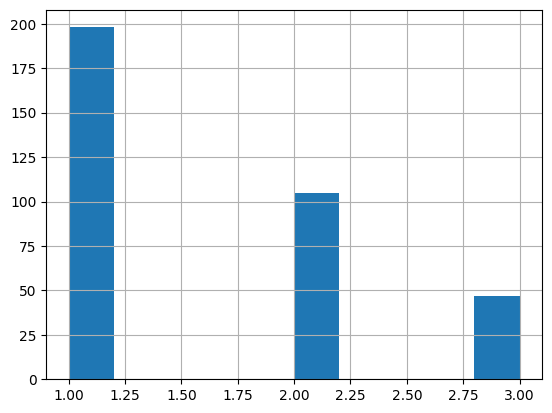

In [ ]:
df_identities['rater_id'].value_counts().hist()

In [ ]:
df_identities = df_identities.dropna(subset='Tema 0')

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df_identities["Tema 0"])
label_names = mlb.classes_

In [ ]:
from sklearn.model_selection import GroupKFold

group_col = "film_id"
rater_col = "rater_id"

feature_cols = [c for c in df_identities.columns if c not in [rater_col, group_col, 'Tema 0', 'Tema 2', 'Tema 3']]
X = df_identities[feature_cols]

import re

def sanitize(col):
    col = col.strip()
    col = re.sub(r"[\[\]<]", "", col)   # remove forbidden chars
    col = re.sub(r"\s+", "_", col)      # spaces → underscores
    return col

X = X.rename(columns={c: sanitize(c) for c in X.columns})

groups = df_identities[rater_col]
cv = GroupKFold(n_splits=5)

In [ ]:
import xgboost as xgb

def make_model(scale_pos_weight):
    return xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=1200,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        min_child_weight=2,
        gamma=0.0,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

Y_true_all = []
Y_pred_all = []
models = []

for train_idx, val_idx in cv.split(X, Y, groups=groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    Y_train, Y_val = Y[train_idx], Y[val_idx]

    Y_pred = np.zeros_like(Y_val, dtype=float)

    for j, label in enumerate(label_names):
        y_tr = Y_train[:, j]
        y_va = Y_val[:, j]

        # skip labels with no positives in training
        if y_tr.sum() == 0:
            continue

        pos = y_tr.sum()
        neg = len(y_tr) - pos
        scale_pos_weight = neg / pos

        model = make_model(scale_pos_weight)
        model.fit(X_train, y_tr)

        models.append(model)

        Y_pred[:, j] = model.predict_proba(X_val)[:, 1]

    Y_true_all.append(Y_val)
    Y_pred_all.append(Y_pred)

Y_true = np.vstack(Y_true_all)
Y_pred = np.vstack(Y_pred_all)


In [ ]:
from sklearn.metrics import precision_recall_curve

thresholds = []

for j in range(Y_true.shape[1]):
    precision, recall, th = precision_recall_curve(
        Y_true[:, j], Y_pred[:, j]
    )
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    thresholds.append(th[np.argmax(f1)])


In [ ]:
Y_pred_bin = (Y_pred >= thresholds).astype(int)


In [ ]:
from sklearn.metrics import f1_score, jaccard_score

print("Micro F1:", f1_score(Y_true, Y_pred_bin, average="micro"))
print("Macro F1:", f1_score(Y_true, Y_pred_bin, average="macro"))
print("Jaccard :", jaccard_score(Y_true, Y_pred_bin, average="samples"))


Micro F1: 0.19355264025314786
Macro F1: 0.1642872501050535
Jaccard : 0.10817139625044513


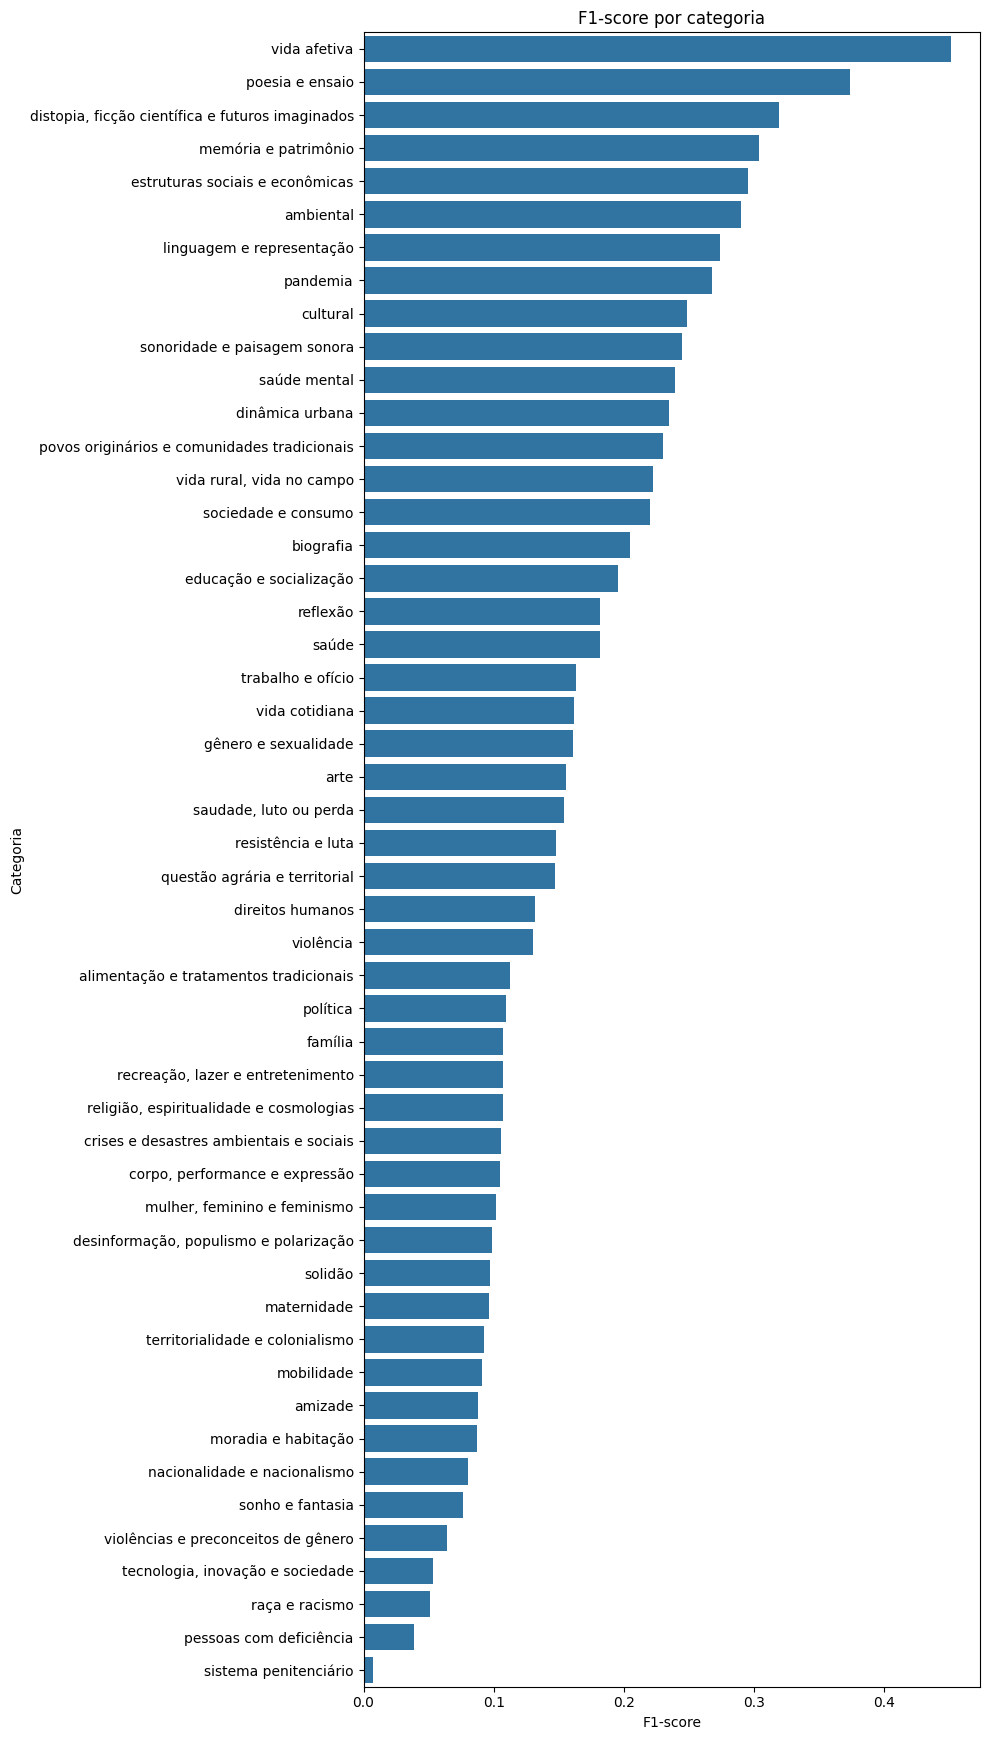

In [ ]:
df_f1 = pd.DataFrame({
    "label": label_names,
    "f1": [f1_score(Y_true[:, j], Y_pred_bin[:, j], zero_division=0)
           for j in range(Y_true.shape[1])],
    "prevalence": [Y_true[:, j].mean() for j in range(Y_true.shape[1])]  # fraction of films with label
}).sort_values("f1", ascending=False)

plt.figure(figsize=(10, max(6, 0.35 * len(df_f1))))
sns.barplot(data=df_f1, x="f1", y="label")
plt.title("F1-score por categoria")
plt.xlabel("F1-score")
plt.ylabel("Categoria")
plt.tight_layout()
plt.savefig(f'{results_dir}/xgboost_f1_score.png', dpi= 300)
plt.show()

In [ ]:
df_f1.to_excel(f'{results_dir}/xgboost_f1_score.xlsx')

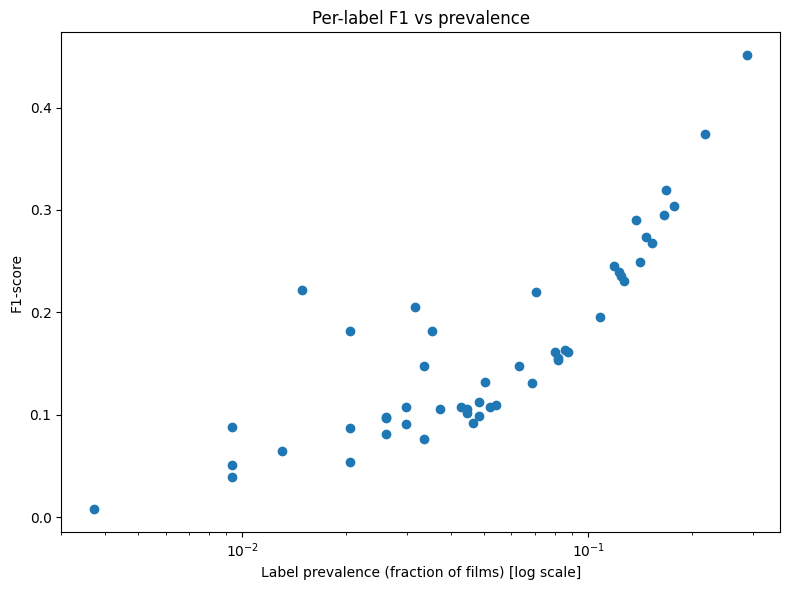

In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(df_f1["prevalence"], df_f1["f1"])
plt.xscale("log")  # labels often long-tail; log makes this readable
plt.xlabel("Label prevalence (fraction of films) [log scale]")
plt.ylabel("F1-score")
plt.title("Per-label F1 vs prevalence")
plt.tight_layout()
plt.show()

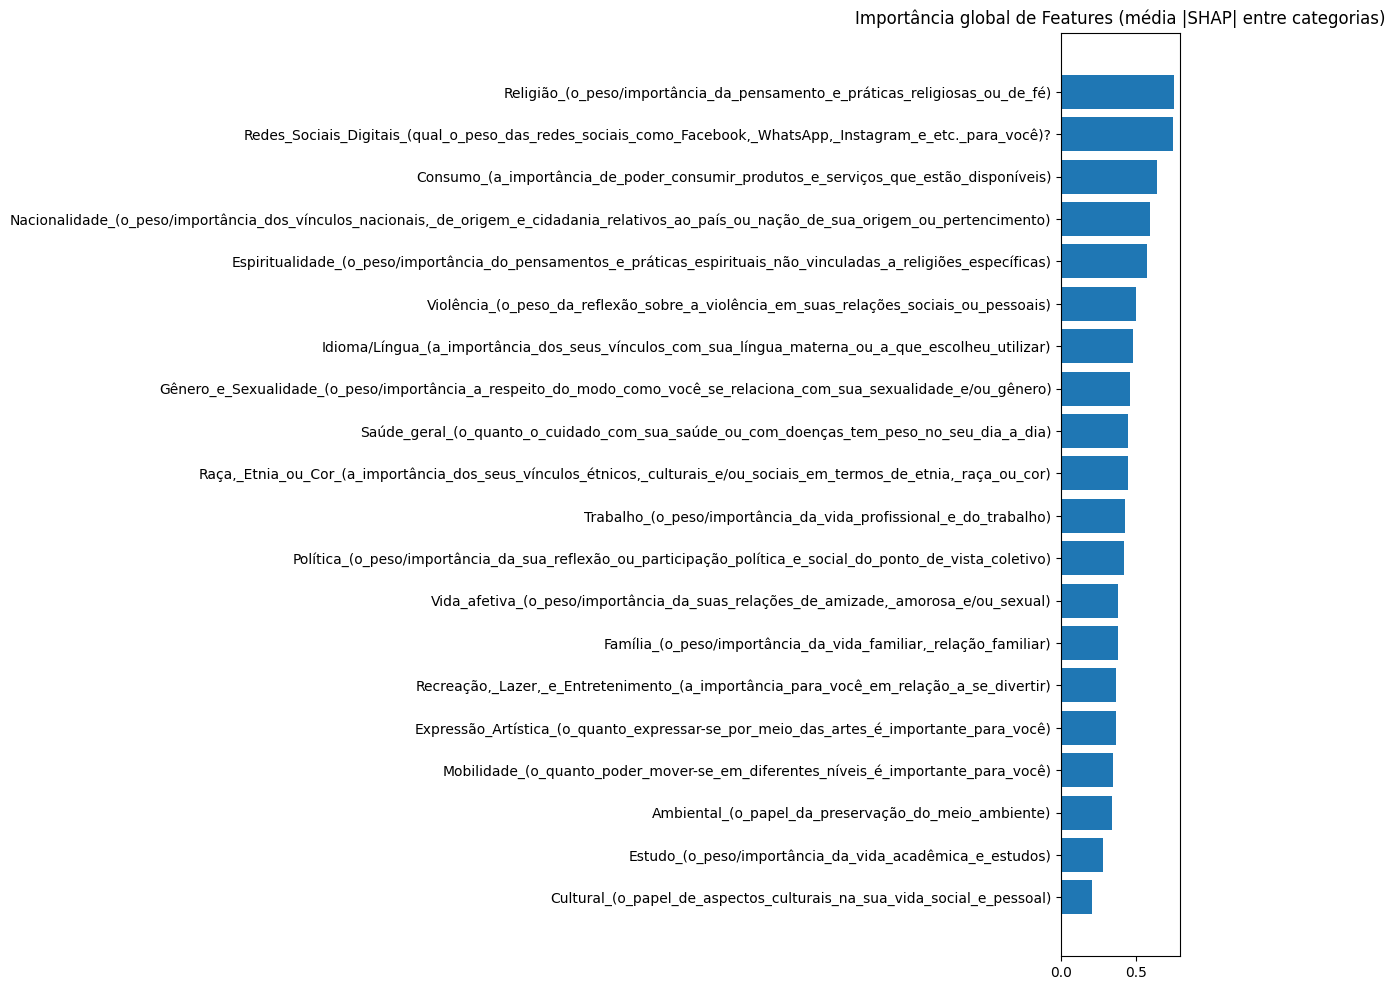

In [ ]:
import shap

mean_abs_per_label = []

for model in models:
    explainer = shap.TreeExplainer(model)
    X_explain = X
    sv = explainer.shap_values(X_explain)  # (n_samples, n_features)
    mean_abs_per_label.append(np.abs(sv).mean(axis=0))

# Average global importance across labels
global_importance = np.mean(mean_abs_per_label, axis=0)

imp = pd.Series(global_importance, index=X_explain.columns).sort_values()
plt.figure(figsize=(12, 10))
plt.barh(imp.index, imp.values)
plt.title("Importância global de Features (média |SHAP| entre categorias)")
plt.tight_layout()
plt.savefig(f'{results_dir}/xgboost_shap.png', dpi = 300)
plt.show()

In [ ]:
imp.to_excel(f'{results_dir}/xgoobst_shap.xlsx')

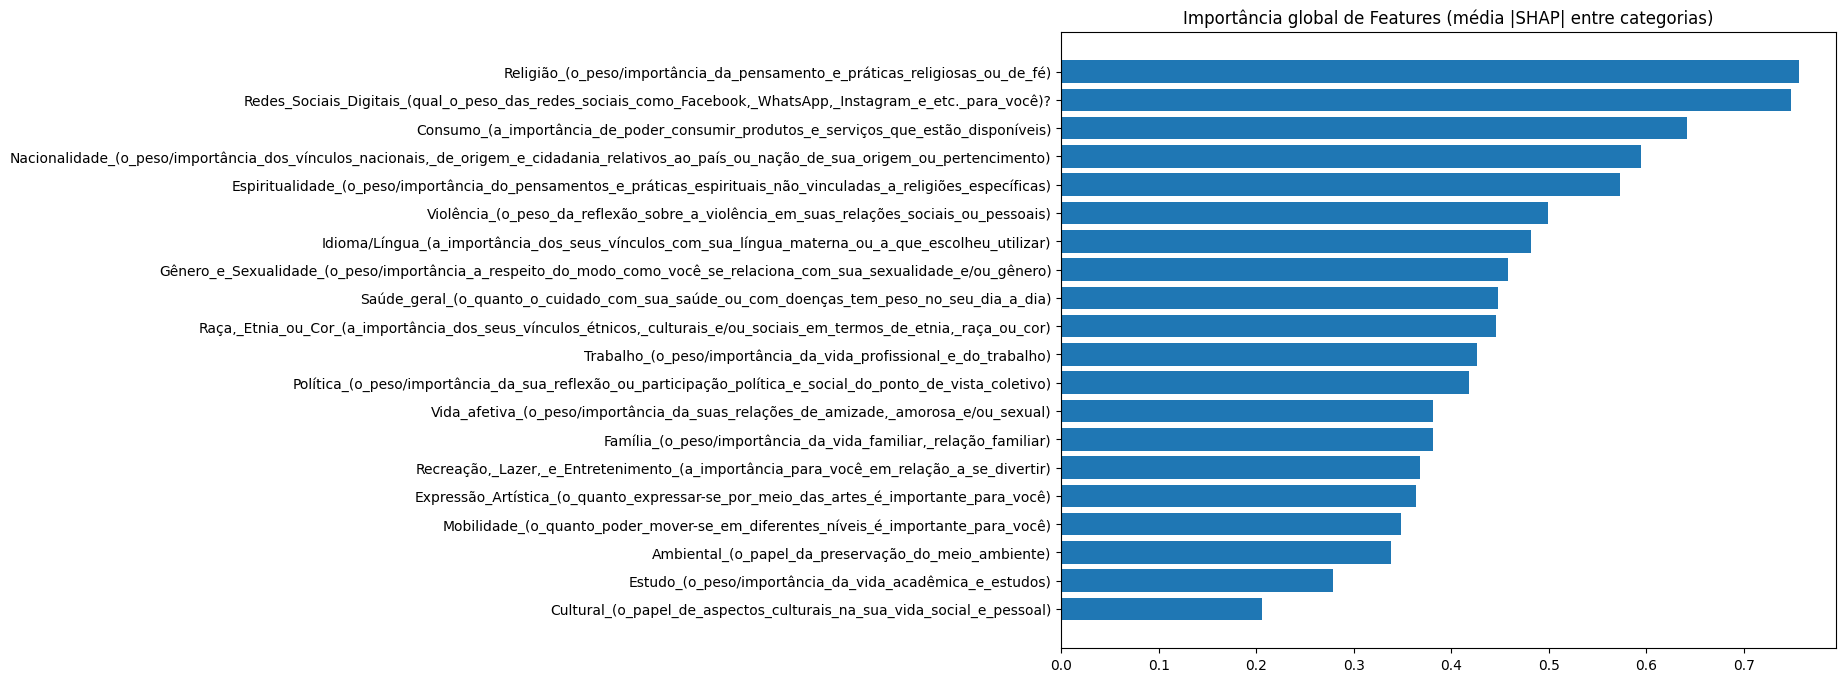

In [ ]:
imp = pd.Series(global_importance, index=X_explain.columns).sort_values()
plt.figure(figsize=(10,8))
plt.barh(imp.index, imp.values)
plt.title("Importância global de Features (média |SHAP| entre categorias)")
#plt.tight_layout()
plt.savefig(f'{results_dir}/xgboost_shap.png', bbox_inches="tight", dpi = 300)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print(classification_report(Y_true, Y_pred_bin))


              precision    recall  f1-score   support

           0       0.06      0.50      0.11        26
           1       0.21      0.47      0.29        74
           2       0.05      0.60      0.09         5
           3       0.10      0.32      0.16        44
           4       0.18      0.24      0.21        17
           5       0.14      0.08      0.11        24
           6       0.06      0.80      0.11        20
           7       0.14      1.00      0.25        76
           8       0.05      0.62      0.10        26
           9       0.13      1.00      0.24        67
          10       0.10      0.19      0.13        27
          11       0.22      0.60      0.32        90
          12       0.11      1.00      0.20        58
          13       0.17      0.96      0.30        89
          14       0.06      0.31      0.11        16
          15       0.09      0.56      0.16        43
          16       0.18      0.54      0.27        79
          17       0.05    

In [ ]:
report = classification_report(
    Y_true,
    Y_pred_bin,
    target_names=label_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_excel(f'{results_dir}/xgboost_report.xlsx')